In [1]:
# ============================================================
# Cell 1: Imports and configuration
# ============================================================

from pathlib import Path
import glob
import warnings

import numpy as np
import pandas as pd

import dask.array as da

import iris
import iris.util
import iris.cube
import iris.analysis
import iris.analysis.cartography

import matplotlib.pyplot as plt

In [2]:

warnings.filterwarnings('ignore') 

In [3]:
# ============================================================
# User settings
# ============================================================

BASE = Path("/badc/cmip6/data/CMIP6")

PROJ_EXPERIMENT = "ssp245" #"ssp585" "ssp370" "ssp245"
PROJ_ACTIVITY = "ScenarioMIP"

PI_EXPERIMENT = "piControl"
PI_ACTIVITY = "CMIP"

ENERGY_TABLE = "Amon"
SEAICE_TABLE = "SImon"

# CMIP6 sign convention:
#   rsds, rlds are positive downward.
#   rsus, rlus, hfss, hfls are positive upward.
#
# Here we convert everything to positive INTO the surface:
#
#   SEB = rsds + rlds - rsus - rlus - hfss - hfls
#
ENERGY_VARS = {
    "rsds": +1.0,
    "rlds": +1.0,
    "rsus": -1.0,
    "rlus": -1.0,
    "hfss": -1.0,
    "hfls": -1.0,
}

SEAICE_VAR = "siconc"

LAT_MIN = 60.0

# If not None, cells with siconc below this threshold are set to zero.
# 15% is common for sea-ice-area / extent-style masking.
SICONC_THRESHOLD = 0.0

# Use one ensemble member per model, or all available members?
MODE = "one_member_per_model"   # "one_member_per_model" or "all_members"

# Preferred member when multiple are available.
PREFERRED_MEMBER = "r1i1p1f1"

# piControl climatology years.
# Leave as None to use the whole available piControl segment.
PI_START_YEAR = None
PI_END_YEAR = None

OUTDIR = Path(f"./{PROJ_EXPERIMENT}_minus_piControl_arctic")
OUTDIR.mkdir(exist_ok=True, parents=True)

In [4]:
# ============================================================
# Cell 2: DRS discovery helpers
# ============================================================

DRS_COLS = [
    "activity",
    "institution",
    "source",
    "experiment",
    "member",
    "table",
    "variable",
    "grid",
    "version",
    "path",
]


def parse_drs_dir(path, base=BASE):
    """
    Parse a CMIP6 DRS dataset directory:

    CMIP6/activity/institution/source/experiment/member/table/variable/grid/version
    """
    path = Path(path)
    rel = path.relative_to(base)
    parts = rel.parts

    if len(parts) < 9:
        raise ValueError(f"Path is too short to be a CMIP6 DRS path: {path}")

    return {
        "activity": parts[0],
        "institution": parts[1],
        "source": parts[2],
        "experiment": parts[3],
        "member": parts[4],
        "table": parts[5],
        "variable": parts[6],
        "grid": parts[7],
        "version": parts[8],
        "path": path,
    }


def version_sort_key(version):
    """
    Sort CMIP6 version labels.

    'latest' is treated as newest.
    """
    version = str(version)

    if version == "latest":
        return 10**20

    if version.startswith("v"):
        try:
            return int(version[1:])
        except ValueError:
            return -1

    return -1


def find_dataset_dirs(activity, experiment, table, variable, base=BASE):
    """
    Find all CMIP6 version directories for a given activity/experiment/table/variable.
    """
    pattern = base / activity / "*" / "*" / experiment / "*" / table / variable / "*" / "*"

    dirs = [
        Path(p)
        for p in glob.glob(str(pattern))
        if Path(p).is_dir()
    ]

    records = []

    for d in sorted(dirs):
        try:
            records.append(parse_drs_dir(d, base=base))
        except Exception:
            pass

    return pd.DataFrame(records)


def keep_latest_versions(df):
    """
    Keep the latest version for each dataset, excluding the version level.
    """
    if df.empty:
        return df

    group_cols = [
        "activity",
        "institution",
        "source",
        "experiment",
        "member",
        "table",
        "variable",
        "grid",
    ]

    df = df.copy()
    df["_version_key"] = df["version"].map(version_sort_key)

    out = (
        df.sort_values("_version_key")
          .groupby(group_cols, as_index=False)
          .tail(1)
          .drop(columns="_version_key")
          .reset_index(drop=True)
    )

    return out

In [5]:
# ============================================================
# Cell 3: Iris loading helpers
# ============================================================

def nc_files_in_dir(d):
    d = Path(d)
    files = sorted(d.glob("*.nc"))

    if not files:
        raise FileNotFoundError(f"No NetCDF files found in {d}")

    return files


def load_single_cube_from_dir(d, var_name):
    """
    Load and concatenate one variable from a CMIP6 dataset directory.
    """
    files = nc_files_in_dir(d)

    constraint = iris.Constraint(
        cube_func=lambda c: c.var_name == var_name or c.name() == var_name
    )

    cubes = iris.load([str(f) for f in files], constraint)

    cubes = iris.cube.CubeList([
        c for c in cubes
        if c.var_name == var_name or c.name() == var_name
    ])

    if len(cubes) == 0:
        raise ValueError(f"No cube with var_name={var_name} found in {d}")

    iris.util.equalise_attributes(cubes)
    iris.util.unify_time_units(cubes)

    try:
        cube = cubes.concatenate_cube()
    except Exception:
        concatenated = cubes.concatenate()

        if len(concatenated) != 1:
            raise ValueError(
                f"Could not concatenate {var_name} cleanly in {d}; "
                f"got {len(concatenated)} cubes"
            )

        cube = concatenated[0]

    return cube


def dask_to_numpy(x):
    if isinstance(x, da.Array):
        return x.compute()

    return np.asarray(x)


def cube_time_index(cube):
    """
    Convert a cube time coordinate to a monthly PeriodIndex.

    This avoids pandas datetime limits for non-standard calendars.
    """
    time_coord = cube.coord("time")
    dates = time_coord.units.num2date(time_coord.points)

    labels = [f"{d.year:04d}-{d.month:02d}" for d in dates]
    return pd.PeriodIndex(labels, freq="M")

In [6]:
# ============================================================
# Cell 4: Coordinate and spatial-weight helpers
# ============================================================

def find_lat_coord(cube):
    for coord in cube.coords():
        if (
            coord.standard_name == "latitude"
            or coord.var_name == "lat"
            or coord.name() == "latitude"
        ):
            return coord

    raise ValueError(f"No latitude coordinate found for cube {cube.name()}")


def find_lon_coord(cube):
    for coord in cube.coords():
        if (
            coord.standard_name == "longitude"
            or coord.var_name == "lon"
            or coord.name() == "longitude"
        ):
            return coord

    raise ValueError(f"No longitude coordinate found for cube {cube.name()}")


def spatial_dims_from_lat_lon(cube):
    lat = find_lat_coord(cube)
    lon = find_lon_coord(cube)

    dims = sorted(set(cube.coord_dims(lat)) | set(cube.coord_dims(lon)))

    if len(dims) != 2:
        raise ValueError(
            f"Expected two horizontal dimensions, got {dims} for cube {cube.name()}"
        )

    return tuple(dims)


def horizontal_shape(cube):
    h_dims = spatial_dims_from_lat_lon(cube)
    return tuple(cube.shape[d] for d in h_dims)


def broadcast_lat_mask_to_horizontal(cube, lat_min=LAT_MIN):
    """
    Return a 2D boolean mask for lat >= lat_min on the cube horizontal grid.
    """
    lat_coord = find_lat_coord(cube)
    lat = np.asarray(lat_coord.points)

    h_dims = spatial_dims_from_lat_lon(cube)
    h_shape = horizontal_shape(cube)

    if lat.ndim == 2:
        if lat.shape != h_shape:
            raise ValueError(
                f"2D latitude shape {lat.shape} does not match horizontal shape {h_shape}"
            )

        return lat >= lat_min

    if lat.ndim == 1:
        lat_dims = cube.coord_dims(lat_coord)

        if len(lat_dims) != 1:
            raise ValueError("1D latitude coordinate does not have exactly one dimension")

        lat_dim = lat_dims[0]

        if lat_dim not in h_dims:
            raise ValueError("Latitude dimension is not one of the horizontal dimensions")

        h_axis = h_dims.index(lat_dim)

        shape = [1, 1]
        shape[h_axis] = lat.size

        return np.broadcast_to((lat >= lat_min).reshape(shape), h_shape)

    raise ValueError(f"Unsupported latitude coordinate dimensions: {lat.ndim}")


def cube_data_to_clean_numpy(cube, huge_threshold=1.0e15):
    """
    Convert cube data to a float numpy array, replacing masked/fill/huge
    values with NaN.
    """
    arr = np.ma.asarray(cube.data).filled(np.nan).astype(float)

    # Remove explicit fill/missing values if present in attributes
    possible_fill_attrs = ["_FillValue", "missing_value", "fill_value"]

    for attr in possible_fill_attrs:
        if attr in cube.attributes:
            try:
                fv = float(cube.attributes[attr])
                arr[np.isclose(arr, fv)] = np.nan
            except Exception:
                pass

    # Defensive removal of classic CMIP-style huge missing values
    arr[np.abs(arr) > huge_threshold] = np.nan

    return arr


def static_cube_to_2d_array(static_cube, target_shape):
    """
    Convert a static field cube to a 2D numpy array matching target_shape.

    This version is robust to masked/fill values such as 1e20.
    """
    arr = cube_data_to_clean_numpy(static_cube).squeeze()

    if arr.shape == tuple(target_shape):
        return arr

    if arr.T.shape == tuple(target_shape):
        warnings.warn(
            f"Static field shape {arr.shape} was transposed to match {target_shape}"
        )
        return arr.T

    raise ValueError(
        f"Static field shape {arr.shape} does not match target shape {target_shape}"
    )


def calculate_area_from_latlon(cube):
    """
    Fallback area calculation for regular lat/lon grids.

    Prefer CMIP6 areacella/areacello/siareacello where possible.
    """
    time_coord = cube.coord("time")
    time_dim = cube.coord_dims(time_coord)[0]

    slicer = [slice(None)] * cube.ndim
    slicer[time_dim] = 0

    spatial_cube = cube[tuple(slicer)]

    lat = find_lat_coord(spatial_cube)
    lon = find_lon_coord(spatial_cube)

    if lat.ndim != 1 or lon.ndim != 1:
        raise ValueError(
            "Cannot calculate fallback area for a curvilinear grid. "
            "Need areacella, areacello, or siareacello."
        )

    if not lat.has_bounds():
        lat.guess_bounds()

    if not lon.has_bounds():
        lon.guess_bounds()

    area = iris.analysis.cartography.area_weights(spatial_cube)
    return np.asarray(area).squeeze()


def broadcast_2d_to_cube(arr_2d, cube):
    """
    Broadcast a 2D horizontal array to the cube dimensions.
    """
    arr_2d = np.asarray(arr_2d)

    h_dims = spatial_dims_from_lat_lon(cube)
    h_shape = horizontal_shape(cube)

    if arr_2d.shape != h_shape:
        raise ValueError(
            f"2D array shape {arr_2d.shape} does not match cube horizontal shape {h_shape}"
        )

    shape = [1] * cube.ndim

    for axis, dim in enumerate(h_dims):
        shape[dim] = arr_2d.shape[axis]

    return da.from_array(arr_2d, chunks=arr_2d.shape).reshape(shape)


def as_dask_filled(data):
    """
    Convert cube data to a dask array and replace masked values with NaN.
    """
    if not isinstance(data, da.Array):
        data = da.from_array(data, chunks="auto")

    try:
        data = da.ma.filled(data, np.nan)
    except Exception:
        pass

    return data


def weighted_spatial_mean_timeseries(cube, weights_2d):
    """
    Area-weighted spatial mean time series.

    weights_2d should already include:
      - cell area
      - ocean fraction / mask
      - Arctic latitude mask
    """
    data = as_dask_filled(cube.core_data())

    h_dims = spatial_dims_from_lat_lon(cube)
    weights = broadcast_2d_to_cube(weights_2d, cube)

    valid = da.isfinite(data)
    weighted_data = da.where(valid, data * weights, 0.0)
    weighted_weights = da.where(valid, weights, 0.0)

    numerator = weighted_data.sum(axis=h_dims)
    denominator = weighted_weights.sum(axis=h_dims)

    return numerator / denominator

In [7]:
# ============================================================
# Cell 5: Static-field discovery
# ============================================================

def find_static_field_dir(
    institution,
    source,
    grid,
    variable,
    tables,
    preferred_member=None,
    base=BASE,
):
    """
    Find a static/fx field for a model/grid.

    Searches across activities, experiments and members because static fields
    are not always stored under the same experiment/member as the data.
    """
    candidates = []

    for table in tables:
        pattern = base / "*" / institution / source / "*" / "*" / table / variable / grid / "*"

        for p in glob.glob(str(pattern)):
            d = Path(p)

            if not d.is_dir():
                continue

            try:
                candidates.append(parse_drs_dir(d, base=base))
            except Exception:
                pass

    if not candidates:
        return None

    df = pd.DataFrame(candidates)
    df["_version_key"] = df["version"].map(version_sort_key)

    group_cols = [
        "activity",
        "institution",
        "source",
        "experiment",
        "member",
        "table",
        "variable",
        "grid",
    ]

    df = (
        df.sort_values("_version_key")
          .groupby(group_cols, as_index=False)
          .tail(1)
          .reset_index(drop=True)
    )

    def score(row):
        s = 0

        if row["activity"] == "CMIP":
            s -= 10

        if row["experiment"] in ["piControl", "historical"]:
            s -= 5

        if preferred_member is not None and row["member"] == preferred_member:
            s -= 3

        return s

    df["_score"] = df.apply(score, axis=1)

    chosen = (
        df.sort_values(["_score", "_version_key"], ascending=[True, False])
          .iloc[0]
    )

    return chosen["path"]


def find_static_field_candidates(
    institution,
    source,
    variable,
    tables,
    preferred_grid=None,
    preferred_member=None,
    base=BASE,
):
    """
    Find candidate static/fx fields for a model.

    This is more flexible than requiring the static field to have the same
    grid label as the monthly Amon data. It will later test whether the
    actual array shape matches the target cube.
    """
    candidates = []

    for table in tables:
        grid_pattern = preferred_grid if preferred_grid is not None else "*"

        pattern = (
            base
            / "*"
            / institution
            / source
            / "*"
            / "*"
            / table
            / variable
            / grid_pattern
            / "*"
        )

        for p in glob.glob(str(pattern)):
            d = Path(p)

            if not d.is_dir():
                continue

            try:
                candidates.append(parse_drs_dir(d, base=base))
            except Exception:
                pass

    if not candidates:
        return pd.DataFrame()

    df = pd.DataFrame(candidates)
    df["_version_key"] = df["version"].map(version_sort_key)

    def score(row):
        s = 0

        # Prefer same grid label, but do not require it.
        if preferred_grid is not None and row["grid"] != preferred_grid:
            s += 20

        # Prefer same member where possible.
        if preferred_member is not None and row["member"] != preferred_member:
            s += 5

        # Prefer CMIP static files.
        if row["activity"] != "CMIP":
            s += 3

        # Prefer piControl/historical static files.
        if row["experiment"] not in ["piControl", "historical"]:
            s += 2

        return s

    df["_score"] = df.apply(score, axis=1)

    # Keep latest version per exact dataset, then sort by preference.
    group_cols = [
        "activity",
        "institution",
        "source",
        "experiment",
        "member",
        "table",
        "variable",
        "grid",
    ]

    df = (
        df.sort_values("_version_key")
          .groupby(group_cols, as_index=False)
          .tail(1)
          .sort_values(["_score", "_version_key"], ascending=[True, False])
          .reset_index(drop=True)
    )

    return df


def load_static_2d_matching_shape(
    institution,
    source,
    variable,
    tables,
    target_shape,
    preferred_grid=None,
    preferred_member=None,
):
    """
    Load the first candidate static field whose actual 2D array shape
    matches target_shape.

    Returns:
        arr, metadata_row
    """
    candidates = find_static_field_candidates(
        institution=institution,
        source=source,
        variable=variable,
        tables=tables,
        preferred_grid=preferred_grid,
        preferred_member=preferred_member,
    )

    if candidates.empty:
        return None, None

    errors = []

    for _, cand in candidates.iterrows():
        try:
            cube = load_single_cube_from_dir(cand["path"], variable)
            arr = cube_data_to_clean_numpy(cube).squeeze()

            if arr.shape == tuple(target_shape):
                return arr, cand

            if arr.T.shape == tuple(target_shape):
                warnings.warn(
                    f"{source}: transposing {variable} from {arr.shape} to {target_shape}"
                )
                return arr.T, cand

            errors.append(
                f"{cand['grid']} {cand['member']} {cand['experiment']}: shape {arr.shape}"
            )

        except Exception as e:
            errors.append(f"{cand['path']}: {repr(e)}")

    warnings.warn(
        f"No {variable} candidate for {source} matched target shape {target_shape}. "
        f"Tried: {errors[:5]}"
    )

    return None, None


def get_atmos_area_and_ocean_weights(run_row, template_cube):
    """
    Construct 2D atmospheric-grid weights:

        area * ocean_fraction * Arctic_mask

    This version first tries static fields on the same grid label, then
    falls back to any archived static field for the model whose array shape
    matches the flux grid.
    """
    institution = run_row["institution"]
    source = run_row["source"]
    member = run_row["member"]
    grid = run_row["grid"]

    h_shape = horizontal_shape(template_cube)

    # ------------------------------------------------------------
    # Land fraction: sftlf
    # ------------------------------------------------------------
    sftlf, sftlf_meta = load_static_2d_matching_shape(
        institution=institution,
        source=source,
        variable="sftlf",
        tables=("fx",),
        target_shape=h_shape,
        preferred_grid=grid,
        preferred_member=member,
    )

    if sftlf is None:
        raise FileNotFoundError(
            f"No usable sftlf found for {source}, member={member}, grid={grid}, "
            f"target_shape={h_shape}. This model will need either a manual land-sea "
            f"mask or should be skipped."
        )

    print(
        f"      Using sftlf from "
        f"{sftlf_meta['activity']}/{sftlf_meta['experiment']}/"
        f"{sftlf_meta['member']}/{sftlf_meta['grid']}"
    )

    if np.nanmax(sftlf) > 2:
        ocean_fraction = 1.0 - (sftlf / 100.0)
    else:
        ocean_fraction = 1.0 - sftlf

    ocean_fraction = np.clip(ocean_fraction, 0.0, 1.0)

    # ------------------------------------------------------------
    # Cell area: areacella
    # ------------------------------------------------------------
    area, area_meta = load_static_2d_matching_shape(
        institution=institution,
        source=source,
        variable="areacella",
        tables=("fx",),
        target_shape=h_shape,
        preferred_grid=grid,
        preferred_member=member,
    )

    if area is not None:
        print(
            f"      Using areacella from "
            f"{area_meta['activity']}/{area_meta['experiment']}/"
            f"{area_meta['member']}/{area_meta['grid']}"
        )
    else:
        warnings.warn(
            f"No usable areacella found for {source}, member={member}, grid={grid}; "
            "falling back to geometric area calculation."
        )
        area = calculate_area_from_latlon(template_cube)

    # ------------------------------------------------------------
    # Arctic latitude mask
    # ------------------------------------------------------------
    lat_mask = broadcast_lat_mask_to_horizontal(template_cube, LAT_MIN)

    weights = area * ocean_fraction * lat_mask
    weights = np.where(np.isfinite(weights), weights, 0.0)

    if np.nansum(weights) <= 0:
        raise ValueError(f"Zero valid Arctic-ocean area for {source}")

    return weights

In [8]:
# ============================================================
# Cell 6: Discover complete energy-variable runs
# ============================================================

def row_for_key(df, key):
    institution, source, member, grid = key

    sub = df[
        (df["institution"] == institution)
        & (df["source"] == source)
        & (df["member"] == member)
        & (df["grid"] == grid)
    ]

    if len(sub) != 1:
        raise ValueError(f"Expected exactly one dataset for {key}, got {len(sub)}")

    return sub.iloc[0]


def build_energy_runs(activity, experiment):
    """
    Find institution/source/member/grid combinations with all six SEB variables.
    """
    catalogues = {}

    for var in ENERGY_VARS:
        df = find_dataset_dirs(
            activity=activity,
            experiment=experiment,
            table=ENERGY_TABLE,
            variable=var,
            base=BASE,
        )

        df = keep_latest_versions(df)
        catalogues[var] = df

        print(f"{activity}/{experiment}/{ENERGY_TABLE}/{var}: {len(df)} datasets")

    common_keys = None

    for var, df in catalogues.items():
        keys = set(
            tuple(row)
            for row in df[["institution", "source", "member", "grid"]].to_numpy()
        )

        if common_keys is None:
            common_keys = keys
        else:
            common_keys = common_keys.intersection(keys)

    records = []

    for key in sorted(common_keys):
        institution, source, member, grid = key

        rec = {
            "activity": activity,
            "experiment": experiment,
            "institution": institution,
            "source": source,
            "member": member,
            "grid": grid,
        }

        for var in ENERGY_VARS:
            rec[f"{var}_path"] = row_for_key(catalogues[var], key)["path"]

        records.append(rec)

    out = pd.DataFrame(records)

    print(f"{activity}/{experiment}: {len(out)} complete SEB runs")
    return out


proj_energy_runs = build_energy_runs(PROJ_ACTIVITY, PROJ_EXPERIMENT)
pi_energy_runs = build_energy_runs(PI_ACTIVITY, PI_EXPERIMENT)

ScenarioMIP/ssp245/Amon/rsds: 158 datasets
ScenarioMIP/ssp245/Amon/rlds: 159 datasets
ScenarioMIP/ssp245/Amon/rsus: 108 datasets
ScenarioMIP/ssp245/Amon/rlus: 62 datasets
ScenarioMIP/ssp245/Amon/hfss: 148 datasets
ScenarioMIP/ssp245/Amon/hfls: 146 datasets
ScenarioMIP/ssp245: 50 complete SEB runs
CMIP/piControl/Amon/rsds: 65 datasets
CMIP/piControl/Amon/rlds: 54 datasets
CMIP/piControl/Amon/rsus: 53 datasets
CMIP/piControl/Amon/rlus: 53 datasets
CMIP/piControl/Amon/hfss: 76 datasets
CMIP/piControl/Amon/hfls: 76 datasets
CMIP/piControl: 51 complete SEB runs


In [9]:
# ============================================================
# Cell 7: Discover siconc datasets
# ============================================================

def build_siconc_catalogue(activity, experiment):
    df = find_dataset_dirs(
        activity=activity,
        experiment=experiment,
        table=SEAICE_TABLE,
        variable=SEAICE_VAR,
        base=BASE,
    )

    df = keep_latest_versions(df)

    print(f"{activity}/{experiment}/{SEAICE_TABLE}/{SEAICE_VAR}: {len(df)} datasets")
    return df


proj_siconc_catalogue = build_siconc_catalogue(PROJ_ACTIVITY, PROJ_EXPERIMENT)
pi_siconc_catalogue = build_siconc_catalogue(PI_ACTIVITY, PI_EXPERIMENT)

ScenarioMIP/ssp245/SImon/siconc: 155 datasets
CMIP/piControl/SImon/siconc: 60 datasets


In [10]:
# ============================================================
# Cell 8: Pair projection and piControl runs
# ============================================================

def choose_pi_energy_for_projection(proj_row, pi_energy_runs):
    """
    Pick a piControl SEB run for a projection SEB run.

    Requires same institution and source.
    Preference:
      1. same member and same grid
      2. same member
      3. preferred piControl member
      4. first available piControl member/grid
    """
    sub = pi_energy_runs[
        (pi_energy_runs["institution"] == proj_row["institution"])
        & (pi_energy_runs["source"] == proj_row["source"])
    ].copy()

    if sub.empty:
        return None

    def score(row):
        s = 0

        if row["member"] != proj_row["member"]:
            s += 20

        if row["grid"] != proj_row["grid"]:
            s += 5

        if row["member"] != PREFERRED_MEMBER:
            s += 1

        return s

    sub["_score"] = sub.apply(score, axis=1)

    return (
        sub.sort_values(["_score", "member", "grid"])
           .drop(columns="_score")
           .iloc[0]
    )



def choose_siconc_for_run(
    run_row,
    siconc_catalogue,
    allow_different_member=False,
):
    """
    Pick siconc for a run.

    For projection data, use allow_different_member=False so SEB and SIA
    come from the same transient member.

    For piControl data, use allow_different_member=True because the
    climatology is averaged over the full control run, so a different
    piControl member is acceptable.
    """
    sub = siconc_catalogue[
        (siconc_catalogue["institution"] == run_row["institution"])
        & (siconc_catalogue["source"] == run_row["source"])
    ].copy()

    if sub.empty:
        return None

    if not allow_different_member:
        sub = sub[sub["member"] == run_row["member"]].copy()

        if sub.empty:
            return None

    def score(row):
        s = 0

        # Prefer the same member, but only require it if allow_different_member=False.
        if row["member"] != run_row["member"]:
            s += 100

        # Prefer the usual first member if the exact member is unavailable.
        if row["member"] != PREFERRED_MEMBER:
            s += 10

        # Prefer native grid where available.
        if row["grid"] != "gn":
            s += 1

        return s

    sub["_score"] = sub.apply(score, axis=1)

    return (
        sub.sort_values(["_score", "member", "grid"])
           .drop(columns="_score")
           .iloc[0]
    )


def add_prefixed_fields(rec, prefix, row):
    for col in row.index:
        rec[f"{prefix}_{col}"] = row[col]



candidate_pairs = []
skipped = []

for _, proj_row in proj_energy_runs.iterrows():
    pi_row = choose_pi_energy_for_projection(proj_row, pi_energy_runs)

    if pi_row is None:
        skipped.append({
            "source": proj_row["source"],
            "member": proj_row["member"],
            "reason": "No piControl SEB run with all variables",
        })
        continue

    # Projection siconc: keep the same member as the projection SEB.
    proj_siconc = choose_siconc_for_run(
        run_row=proj_row,
        siconc_catalogue=proj_siconc_catalogue,
        allow_different_member=False,
    )

    if proj_siconc is None:
        skipped.append({
            "source": proj_row["source"],
            "member": proj_row["member"],
            "reason": "No projection siconc for same member",
        })
        continue

    # piControl siconc: allow a different piControl member.
    pi_siconc = choose_siconc_for_run(
        run_row=pi_row,
        siconc_catalogue=pi_siconc_catalogue,
        allow_different_member=True,
    )

    if pi_siconc is None:
        skipped.append({
            "source": proj_row["source"],
            "member": proj_row["member"],
            "reason": "No piControl siconc for any member",
        })
        continue

    rec = {}
    add_prefixed_fields(rec, "proj", proj_row)
    add_prefixed_fields(rec, "pi", pi_row)
    add_prefixed_fields(rec, "proj_siconc", proj_siconc)
    add_prefixed_fields(rec, "pi_siconc", pi_siconc)

    candidate_pairs.append(rec)

candidate_pairs = pd.DataFrame(candidate_pairs)
skipped_df = pd.DataFrame(skipped)

print(f"Candidate projection/piControl pairs with all variables and siconc: {len(candidate_pairs)}")
print(f"Skipped candidate projection runs: {len(skipped_df)}")

if not skipped_df.empty:
    display(skipped_df.head(30))

Candidate projection/piControl pairs with all variables and siconc: 38
Skipped candidate projection runs: 12


,source,member,reason
0,AWI-CM-1-1-MR,r1i1p1f1,No projection siconc for same member
1,FGOALS-f3-L,r1i1p1f1,No piControl siconc for any member
2,IITM-ESM,r1i1p1f1,No projection siconc for same member
3,CMCC-ESM2,r1i1p1f1,No piControl SEB run with all variables
4,CNRM-CM6-1,r1i1p1f2,No piControl siconc for any member
5,MPI-ESM1-2-HR,r1i1p1f1,No piControl SEB run with all variables
6,EC-Earth3-CC,r1i1p1f1,No piControl SEB run with all variables
7,FIO-ESM-2-0,r1i1p1f1,No piControl SEB run with all variables
8,GISS-E2-1-G,r1i1p1f2,No projection siconc for same member
9,NorESM2-LM,r1i1p1f1,No piControl SEB run with all variables


In [11]:
# ============================================================
# Cell 9: Select one member per model, or all members
# ============================================================

def select_pairs(candidate_pairs):
    if candidate_pairs.empty:
        return candidate_pairs

    if MODE == "all_members":
        return candidate_pairs.reset_index(drop=True)

    if MODE != "one_member_per_model":
        raise ValueError("MODE must be 'one_member_per_model' or 'all_members'")

    df = candidate_pairs.copy()

    def score(row):
        s = 0

        if row["proj_member"] != PREFERRED_MEMBER:
            s += 100

        if row["pi_member"] != row["proj_member"]:
            s += 20

        if row["proj_grid"] != row["pi_grid"]:
            s += 5

        if row["proj_siconc_grid"] != "gn":
            s += 1

        return s

    df["_selection_score"] = df.apply(score, axis=1)

    selected = (
        df.sort_values(
            [
                "proj_institution",
                "proj_source",
                "_selection_score",
                "proj_member",
                "proj_grid",
            ]
        )
        .groupby(["proj_institution", "proj_source"], as_index=False)
        .head(1)
        .drop(columns="_selection_score")
        .reset_index(drop=True)
    )

    return selected


pairs_to_process = select_pairs(candidate_pairs)

#pairs_to_process = pairs_to_process.head(10).reset_index(drop=True)
#######################################
#Using 10 for testing, Remove later
#######################################

print(f"Pairs selected for processing: {len(pairs_to_process)}")

display(
    pairs_to_process[
        [
            "proj_institution",
            "proj_source",
            "proj_member",
            "proj_grid",
            "pi_member",
            "pi_grid",
            "proj_siconc_grid",
            "pi_siconc_grid",
        ]
    ].sort_values(["proj_source"])
)

Pairs selected for processing: 29


,proj_institution,proj_source,proj_member,proj_grid,pi_member,pi_grid,proj_siconc_grid,pi_siconc_grid
10,CSIRO-ARCCSS,ACCESS-CM2,r1i1p1f1,gn,r1i1p1f1,gn,gn,gn
9,CSIRO,ACCESS-ESM1-5,r1i1p1f1,gn,r1i1p1f1,gn,gn,gn
1,BCC,BCC-CSM2-MR,r1i1p1f1,gn,r1i1p1f1,gn,gn,gn
2,CAMS,CAMS-CSM1-0,r1i1p1f1,gn,r1i1p1f1,gn,gn,gn
22,NCAR,CESM2,r4i1p1f1,gn,r1i1p1f1,gn,gn,gn
23,NCAR,CESM2-WACCM,r1i1p1f1,gn,r1i1p1f1,gn,gn,gn
28,THU,CIESM,r1i1p1f1,gr,r1i1p1f1,gr,gn,gn
6,CMCC,CMCC-CM2-SR5,r1i1p1f1,gn,r1i1p1f1,gn,gn,gn
7,CNRM-CERFACS,CNRM-CM6-1-HR,r1i1p1f2,gr,r1i1p1f2,gr,gn,gn
8,CNRM-CERFACS,CNRM-ESM2-1,r1i1p1f2,gr,r1i1p1f2,gr,gn,gn


In [12]:
# ============================================================
# Cell 10: Convert paired rows back to normal rows
# ============================================================

def unprefix_energy_row(pair_row, prefix):
    """
    Convert columns like proj_source/proj_rsds_path back into
    a normal run row expected by the processing functions.
    """
    rec = {
        "activity": pair_row[f"{prefix}_activity"],
        "experiment": pair_row[f"{prefix}_experiment"],
        "institution": pair_row[f"{prefix}_institution"],
        "source": pair_row[f"{prefix}_source"],
        "member": pair_row[f"{prefix}_member"],
        "grid": pair_row[f"{prefix}_grid"],
    }

    for var in ENERGY_VARS:
        rec[f"{var}_path"] = pair_row[f"{prefix}_{var}_path"]

    return pd.Series(rec)


def unprefix_siconc_row(pair_row, prefix):
    """
    Convert columns like proj_siconc_path back into a normal DRS row.
    prefix should be 'proj_siconc' or 'pi_siconc'.
    """
    rec = {}

    for col in DRS_COLS:
        rec[col] = pair_row[f"{prefix}_{col}"]

    return pd.Series(rec)

In [13]:
# ============================================================
# Cell 11: Surface energy budget processing
# ============================================================

def process_surface_energy_budget(run_row):
    """
    Calculate monthly Arctic-ocean mean surface energy budget.

    Output contains:
      - signed individual components, positive into surface
      - seb_Wm2 = sum of components
    """
    source = run_row["source"]
    member = run_row["member"]
    grid = run_row["grid"]
    experiment = run_row["experiment"]

    print(f"    Loading atmosphere template: {source} {experiment} {member} {grid}")

    template_cube = load_single_cube_from_dir(run_row["rsds_path"], "rsds")
    template_cube.convert_units("W m-2")

    weights_2d = get_atmos_area_and_ocean_weights(run_row, template_cube)

    component_series = []
    component_cols = []

    for var, sign in ENERGY_VARS.items():
        print(f"      Processing {var}")

        cube = load_single_cube_from_dir(run_row[f"{var}_path"], var)
        cube.convert_units("W m-2")

        ts = weighted_spatial_mean_timeseries(cube, weights_2d)
        values = dask_to_numpy(ts)

        time_index = cube_time_index(cube)

        col = f"{var}_into_surface_Wm2"
        component_cols.append(col)

        component_series.append(
            pd.Series(
                sign * values,
                index=time_index,
                name=col,
            )
        )

    df = pd.concat(component_series, axis=1).sort_index()

    # Require all six components to be present for SEB.
    df["seb_Wm2"] = df[component_cols].sum(
        axis=1,
        min_count=len(component_cols),
    )

    df = df.reset_index(names="time")
    df["year"] = df["time"].dt.year
    df["month"] = df["time"].dt.month

    df["institution"] = run_row["institution"]
    df["source"] = source
    df["member"] = member
    df["grid"] = grid
    df["experiment"] = experiment

    front = [
        "institution",
        "source",
        "member",
        "grid",
        "experiment",
        "time",
        "year",
        "month",
    ]

    df = df[front + component_cols + ["seb_Wm2"]]

    return df

In [14]:
# ============================================================
# Cell 12: piControl anomaly helpers
# ============================================================

def filter_pi_years(df):
    """
    Optionally restrict piControl years used for climatology.
    """
    out = df.copy()

    if PI_START_YEAR is not None:
        out = out[out["year"] >= PI_START_YEAR]

    if PI_END_YEAR is not None:
        out = out[out["year"] <= PI_END_YEAR]

    return out


def add_monthly_pi_anomalies(proj_df, pi_df, value_cols):
    """
    Add anomalies to projection monthly data using the piControl
    monthly climatology.
    """
    pi_use = filter_pi_years(pi_df)

    clim = (
        pi_use.groupby("month")[value_cols]
              .mean()
              .reset_index()
    )

    clim = clim.rename(
        columns={col: f"pi_clim_{col}" for col in value_cols}
    )

    out = proj_df.merge(clim, on="month", how="left")

    for col in value_cols:
        out[f"{col}_anom"] = out[col] - out[f"pi_clim_{col}"]

    if "seb_Wm2_anom" in out.columns:
        out = out.rename(columns={"seb_Wm2_anom": "seb_anom_Wm2"})

    return out

In [15]:
# ============================================================
# Cell 13: Sea-ice area helpers
# ============================================================

def get_seaice_area_field(run_row, siconc_cube, siconc_grid):
    """
    Get a sea-ice/ocean cell-area field for the siconc grid.

    Preference:
      1. siareacello
      2. areacello
      3. fallback regular lat/lon area calculation
    """
    institution = run_row["institution"]
    source = run_row["source"]
    member = run_row["member"]

    h_shape = horizontal_shape(siconc_cube)

    area_dir = find_static_field_dir(
        institution=institution,
        source=source,
        grid=siconc_grid,
        variable="siareacello",
        tables=("SIfx", "fx"),
        preferred_member=member,
    )

    area_var = "siareacello"

    if area_dir is None:
        area_dir = find_static_field_dir(
            institution=institution,
            source=source,
            grid=siconc_grid,
            variable="areacello",
            tables=("Ofx", "fx"),
            preferred_member=member,
        )
        area_var = "areacello"

    if area_dir is not None:
        area_cube = load_single_cube_from_dir(area_dir, area_var)
        area = static_cube_to_2d_array(area_cube, target_shape=h_shape)
    else:
        warnings.warn(
            f"No siareacello/areacello found for {source}, member={member}, "
            f"grid={siconc_grid}; falling back to geometric area calculation."
        )
        area = calculate_area_from_latlon(siconc_cube)

    return area


def clean_siconc_dask(cube):
    """
    Return siconc as a cleaned dask array, with impossible/fill values
    replaced by NaN.

    Does not convert percent to fraction yet.
    """
    data = as_dask_filled(cube.core_data()).astype("float64")

    # Remove explicit fill/missing values if present
    possible_fill_attrs = ["_FillValue", "missing_value", "fill_value"]

    for attr in possible_fill_attrs:
        if attr in cube.attributes:
            try:
                fv = float(cube.attributes[attr])
                data = da.where(da.isclose(data, fv), np.nan, data)
            except Exception:
                pass

    # Remove huge CMIP fill values that may not be encoded properly
    data = da.where(da.abs(data) > 1.0e10, np.nan, data)

    return data


def siconc_looks_like_percent(cube):
    """
    Decide whether siconc is percent or fraction after removing bad values.
    """
    units = str(cube.units).lower()

    if "%" in units or "percent" in units:
        return True

    data = clean_siconc_dask(cube)

    # Take a small sample from first time slice.
    sample = data[0].compute()
    sample = np.asarray(sample, dtype=float)
    sample = sample[np.isfinite(sample)]

    if sample.size == 0:
        # CMIP6 siconc is normally percent, so default to percent.
        return True

    sample_max = np.nanmax(sample)

    return sample_max > 2.0


def monthly_sea_ice_area_timeseries(run_row, siconc_row):
    """
    Calculate monthly Arctic sea-ice area in million km2.

    Uses:
        SIA = sum(area * siconc_fraction)

    This version explicitly removes impossible/fill values from both
    siconc and area fields.
    """
    source = run_row["source"]
    member = run_row["member"]
    experiment = run_row["experiment"]

    siconc_path = siconc_row["path"]
    siconc_grid = siconc_row["grid"]

    print(f"    Processing siconc: {source} {experiment} {member} {siconc_grid}")

    cube = load_single_cube_from_dir(siconc_path, SEAICE_VAR)

    area = get_seaice_area_field(run_row, cube, siconc_grid).astype(float)

    # Defensive area cleaning.
    # Grid-cell areas should be positive and nowhere near 1e20.
    area = np.where(np.isfinite(area), area, np.nan)
    area = np.where(area > 0, area, np.nan)
    area = np.where(area < 1.0e15, area, np.nan)

    lat_mask = broadcast_lat_mask_to_horizontal(cube, LAT_MIN)

    weights_2d = area * lat_mask
    weights_2d = np.where(np.isfinite(weights_2d), weights_2d, 0.0)

    total_arctic_area_m2 = np.nansum(weights_2d)
    total_arctic_area_mkm2 = total_arctic_area_m2 / 1.0e12

    print(f"      Total Arctic area used: {total_arctic_area_mkm2:.2f} million km2")

    if total_arctic_area_mkm2 <= 0 or total_arctic_area_mkm2 > 100:
        raise ValueError(
            f"Implausible Arctic area for {source}: "
            f"{total_arctic_area_mkm2:.3g} million km2. "
            "This probably indicates a bad area field."
        )

    # Clean siconc before thresholding or unit conversion
    data_raw = clean_siconc_dask(cube)

    is_percent = siconc_looks_like_percent(cube)

    if is_percent:
        # Remove impossible percent values before converting
        data_clean = da.where((data_raw >= 0.0) & (data_raw <= 100.0), data_raw, np.nan)
        conc_frac = data_clean / 100.0
        threshold_clean = SICONC_THRESHOLD
    else:
        # Remove impossible fraction values
        data_clean = da.where((data_raw >= 0.0) & (data_raw <= 1.0), data_raw, np.nan)
        conc_frac = data_clean
        threshold_clean = None if SICONC_THRESHOLD is None else SICONC_THRESHOLD / 100.0

    if SICONC_THRESHOLD is not None:
        conc_frac = da.where(data_clean >= threshold_clean, conc_frac, 0.0)

    conc_frac = da.where(da.isfinite(conc_frac), conc_frac, 0.0)

    h_dims = spatial_dims_from_lat_lon(cube)
    weights = broadcast_2d_to_cube(weights_2d, cube)

    sia_m2 = da.nansum(conc_frac * weights, axis=h_dims)
    sia_mkm2 = sia_m2 / 1.0e12

    values = dask_to_numpy(sia_mkm2)
    time_index = cube_time_index(cube)

    # Final sanity check
    finite_values = values[np.isfinite(values)]

    if finite_values.size > 0:
        max_sia = np.nanmax(finite_values)

        if max_sia > 100:
            raise ValueError(
                f"Implausibly large SIA for {source}: max={max_sia:.3g} million km2. "
                "This probably indicates unmasked fill values in siconc or area."
            )

    df = pd.DataFrame({
        "time": time_index,
        "year": time_index.year,
        "month": time_index.month,
        "sia_Mkm2": values,
    })

    df["institution"] = run_row["institution"]
    df["source"] = source
    df["member"] = member
    df["siconc_grid"] = siconc_grid
    df["experiment"] = experiment

    front = [
        "institution",
        "source",
        "member",
        "siconc_grid",
        "experiment",
        "time",
        "year",
        "month",
    ]

    return df[front + ["sia_Mkm2"]]


def annual_minimum_sia(monthly_sia_df):
    """
    Annual minimum monthly SIA.

    For the Arctic, this should normally correspond to the summer minimum.
    """
    idx = monthly_sia_df.groupby("year")["sia_Mkm2"].idxmin()

    out = monthly_sia_df.loc[idx].copy()

    out = out.rename(
        columns={
            "time": "summer_min_time",
            "month": "summer_min_month",
            "sia_Mkm2": "summer_min_sia_Mkm2",
        }
    )

    keep = [
        "institution",
        "source",
        "member",
        "siconc_grid",
        "experiment",
        "year",
        "summer_min_time",
        "summer_min_month",
        "summer_min_sia_Mkm2",
    ]

    return out[keep].reset_index(drop=True)


def add_monthly_sia_anomaly(proj_sia_df, pi_sia_df):
    """
    Monthly SIA anomaly relative to piControl monthly climatology.
    """
    pi_use = filter_pi_years(pi_sia_df)

    clim = (
        pi_use.groupby("month")["sia_Mkm2"]
              .mean()
              .reset_index()
              .rename(columns={"sia_Mkm2": "pi_clim_sia_Mkm2"})
    )

    out = proj_sia_df.merge(clim, on="month", how="left")
    out["sia_anom_Mkm2"] = out["sia_Mkm2"] - out["pi_clim_sia_Mkm2"]

    return out


def add_summer_min_sia_anomaly(proj_sia_df, pi_sia_df):
    """
    Annual summer-minimum SIA anomaly relative to the piControl
    mean annual minimum.
    """
    proj_min = annual_minimum_sia(proj_sia_df)

    pi_use = filter_pi_years(pi_sia_df)
    pi_min = annual_minimum_sia(pi_use)

    pi_mean = pi_min["summer_min_sia_Mkm2"].mean()
    pi_std = pi_min["summer_min_sia_Mkm2"].std()

    proj_min["piControl_mean_summer_min_sia_Mkm2"] = pi_mean
    proj_min["piControl_std_summer_min_sia_Mkm2"] = pi_std
    proj_min["summer_min_sia_anom_Mkm2"] = (
        proj_min["summer_min_sia_Mkm2"] - pi_mean
    )

    return proj_min

In [16]:
# ============================================================
# CSV cache helpers
# ============================================================

USE_CSV_CACHE = True
OVERWRITE_CSV_CACHE = False


def read_cached_csv(path, time_cols=("time", "summer_min_time")):
    """
    Read a cached CSV and restore monthly Period columns where needed.
    """
    df = pd.read_csv(path)

    for col in time_cols:
        if col in df.columns:
            # monthly columns like "2030-01"
            try:
                df[col] = pd.PeriodIndex(df[col], freq="M")
            except Exception:
                pass

    return df


def csv_is_usable(path):
    """
    Lightweight check that a cached CSV exists and is non-empty.
    """
    path = Path(path)
    return path.exists() and path.stat().st_size > 0

In [17]:
# ============================================================
# Cell 14: Main processing loop with per-model CSV cache
# ============================================================

all_monthly_seb_anom = []
all_annual_seb_anom = []
all_monthly_sia_anom = []
all_summer_min_sia_anom = []
failures = []

for i, pair_row in pairs_to_process.iterrows():
    source = pair_row["proj_source"]
    institution = pair_row["proj_institution"]
    proj_member = pair_row["proj_member"]
    pi_member = pair_row["pi_member"]

    label = (
        f"{source}: {PROJ_EXPERIMENT} {proj_member} "
        f"minus {PI_EXPERIMENT} {pi_member}"
    )

    print("=" * 100)
    print(f"[{i + 1}/{len(pairs_to_process)}] {label}")

    # Existing filename pattern from previous cells
    seb_monthly_out = (
        OUTDIR
        / f"{source}_{proj_member}_{PROJ_EXPERIMENT}_minus_piControl_arctic_seb_monthly.csv"
    )

    seb_annual_out = (
        OUTDIR
        / f"{source}_{proj_member}_{PROJ_EXPERIMENT}_minus_piControl_arctic_seb_annual.csv"
    )

    sia_monthly_out = (
        OUTDIR
        / f"{source}_{proj_member}_{PROJ_EXPERIMENT}_minus_piControl_arctic_sia_monthly.csv"
    )

    sia_min_out = (
        OUTDIR
        / f"{source}_{proj_member}_{PROJ_EXPERIMENT}_minus_piControl_arctic_summer_min_sia_annual.csv"
    )

    try:
        # --------------------------------------------------------
        # Surface energy budget
        # --------------------------------------------------------
        if (
            USE_CSV_CACHE
            and not OVERWRITE_CSV_CACHE
            and csv_is_usable(seb_monthly_out)
            and csv_is_usable(seb_annual_out)
        ):
            print("  Using cached SEB CSVs")

            proj_seb_anom = read_cached_csv(seb_monthly_out)
            annual_seb_anom = read_cached_csv(seb_annual_out)

        else:
            print("  Calculating SEB")

            proj_energy_row = unprefix_energy_row(pair_row, "proj")
            pi_energy_row = unprefix_energy_row(pair_row, "pi")

            print("  Projection SEB")
            proj_seb = process_surface_energy_budget(proj_energy_row)

            print("  piControl SEB")
            pi_seb = process_surface_energy_budget(pi_energy_row)

            seb_value_cols = [
                f"{var}_into_surface_Wm2"
                for var in ENERGY_VARS
            ] + ["seb_Wm2"]

            proj_seb_anom = add_monthly_pi_anomalies(
                proj_df=proj_seb,
                pi_df=pi_seb,
                value_cols=seb_value_cols,
            )

            annual_seb_anom = (
                proj_seb_anom
                .groupby(
                    [
                        "institution",
                        "source",
                        "member",
                        "grid",
                        "experiment",
                        "year",
                    ],
                    as_index=False,
                )
                .agg(
                    seb_Wm2=("seb_Wm2", "mean"),
                    seb_anom_Wm2=("seb_anom_Wm2", "mean"),
                )
            )

            proj_seb_anom.to_csv(seb_monthly_out, index=False)
            annual_seb_anom.to_csv(seb_annual_out, index=False)

            print(f"  Saved monthly SEB anomalies: {seb_monthly_out}")
            print(f"  Saved annual SEB anomalies:  {seb_annual_out}")

        all_monthly_seb_anom.append(proj_seb_anom)
        all_annual_seb_anom.append(annual_seb_anom)

        # --------------------------------------------------------
        # Sea-ice area
        # --------------------------------------------------------
        if (
            USE_CSV_CACHE
            and not OVERWRITE_CSV_CACHE
            and csv_is_usable(sia_monthly_out)
            and csv_is_usable(sia_min_out)
        ):
            print("  Using cached SIA CSVs")

            proj_sia_anom = read_cached_csv(sia_monthly_out)
            summer_min_sia_anom = read_cached_csv(sia_min_out)

        else:
            print("  Calculating SIA")

            proj_energy_row = unprefix_energy_row(pair_row, "proj")
            pi_energy_row = unprefix_energy_row(pair_row, "pi")

            proj_siconc_row = unprefix_siconc_row(pair_row, "proj_siconc")
            pi_siconc_row = unprefix_siconc_row(pair_row, "pi_siconc")

            print("  Projection SIA")
            proj_sia = monthly_sea_ice_area_timeseries(
                run_row=proj_energy_row,
                siconc_row=proj_siconc_row,
            )

            print("  piControl SIA")
            pi_sia = monthly_sea_ice_area_timeseries(
                run_row=pi_energy_row,
                siconc_row=pi_siconc_row,
            )

            proj_sia_anom = add_monthly_sia_anomaly(proj_sia, pi_sia)
            summer_min_sia_anom = add_summer_min_sia_anomaly(proj_sia, pi_sia)

            proj_sia_anom.to_csv(sia_monthly_out, index=False)
            summer_min_sia_anom.to_csv(sia_min_out, index=False)

            print(f"  Saved monthly SIA anomalies:        {sia_monthly_out}")
            print(f"  Saved summer-minimum SIA anomalies: {sia_min_out}")

        all_monthly_sia_anom.append(proj_sia_anom)
        all_summer_min_sia_anom.append(summer_min_sia_anom)

    except Exception as e:
        print(f"  FAILED: {label}")
        print(f"  Reason: {repr(e)}")

        failures.append({
            "institution": institution,
            "source": source,
            "proj_member": proj_member,
            "pi_member": pi_member,
            "error": repr(e),
        })

[1/29] TaiESM1: ssp245 r1i1p1f1 minus piControl r1i1p1f1
  Using cached SEB CSVs
  Using cached SIA CSVs
[2/29] BCC-CSM2-MR: ssp245 r1i1p1f1 minus piControl r1i1p1f1
  Calculating SEB
  Projection SEB
    Loading atmosphere template: BCC-CSM2-MR ssp245 r1i1p1f1 gn
  FAILED: BCC-CSM2-MR: ssp245 r1i1p1f1 minus piControl r1i1p1f1
  Reason: FileNotFoundError('No usable sftlf found for BCC-CSM2-MR, member=r1i1p1f1, grid=gn, target_shape=(160, 320). This model will need either a manual land-sea mask or should be skipped.')
[3/29] CAMS-CSM1-0: ssp245 r1i1p1f1 minus piControl r1i1p1f1
  Calculating SEB
  Projection SEB
    Loading atmosphere template: CAMS-CSM1-0 ssp245 r1i1p1f1 gn
  FAILED: CAMS-CSM1-0: ssp245 r1i1p1f1 minus piControl r1i1p1f1
  Reason: FileNotFoundError('No usable sftlf found for CAMS-CSM1-0, member=r1i1p1f1, grid=gn, target_shape=(160, 320). This model will need either a manual land-sea mask or should be skipped.')
[4/29] FGOALS-g3: ssp245 r1i1p1f1 minus piControl r1i1p1f1


In [18]:
# ============================================================
# Cell 15: Combine and save outputs
# ============================================================

if all_monthly_seb_anom:
    combined_monthly_seb_anom = pd.concat(
        all_monthly_seb_anom,
        ignore_index=True,
    )

    combined_monthly_seb_anom.to_csv(
        OUTDIR / f"{PROJ_EXPERIMENT}_minus_piControl_all_models_arctic_seb_monthly.csv",
        index=False,
    )
else:
    combined_monthly_seb_anom = pd.DataFrame()


if all_annual_seb_anom:
    combined_annual_seb_anom = pd.concat(
        all_annual_seb_anom,
        ignore_index=True,
    )

    combined_annual_seb_anom.to_csv(
        OUTDIR / f"{PROJ_EXPERIMENT}_minus_piControl_all_models_arctic_seb_annual.csv",
        index=False,
    )
else:
    combined_annual_seb_anom = pd.DataFrame()


if all_monthly_sia_anom:
    combined_monthly_sia_anom = pd.concat(
        all_monthly_sia_anom,
        ignore_index=True,
    )

    combined_monthly_sia_anom.to_csv(
        OUTDIR / f"{PROJ_EXPERIMENT}_minus_piControl_all_models_arctic_sia_monthly.csv",
        index=False,
    )
else:
    combined_monthly_sia_anom = pd.DataFrame()


if all_summer_min_sia_anom:
    combined_summer_min_sia_anom = pd.concat(
        all_summer_min_sia_anom,
        ignore_index=True,
    )

    combined_summer_min_sia_anom.to_csv(
        OUTDIR / f"{PROJ_EXPERIMENT}_minus_piControl_all_models_arctic_summer_min_sia_annual.csv",
        index=False,
    )
else:
    combined_summer_min_sia_anom = pd.DataFrame()


if failures:
    failures_df = pd.DataFrame(failures)

    failures_df.to_csv(
        OUTDIR / f"{PROJ_EXPERIMENT}_minus_piControl_failures.csv",
        index=False,
    )
else:
    failures_df = pd.DataFrame()


print("Done.")
print(f"Monthly SEB anomaly rows:        {len(combined_monthly_seb_anom)}")
print(f"Annual SEB anomaly rows:         {len(combined_annual_seb_anom)}")
print(f"Monthly SIA anomaly rows:        {len(combined_monthly_sia_anom)}")
print(f"Annual summer-min SIA rows:      {len(combined_summer_min_sia_anom)}")
print(f"Failures:                        {len(failures_df)}")

if not failures_df.empty:
    display(failures_df)

Done.
Monthly SEB anomaly rows:        25800
Annual SEB anomaly rows:         2150
Monthly SIA anomaly rows:        20640
Annual summer-min SIA rows:      1720
Failures:                        9


,institution,source,proj_member,pi_member,error
0,BCC,BCC-CSM2-MR,r1i1p1f1,r1i1p1f1,FileNotFoundError('No usable sftlf found for B...
1,CAMS,CAMS-CSM1-0,r1i1p1f1,r1i1p1f1,FileNotFoundError('No usable sftlf found for C...
2,CMCC,CMCC-CM2-SR5,r1i1p1f1,r1i1p1f1,"ValueError('Static field shape (292, 362) does..."
3,IPSL,IPSL-CM6A-LR,r1i1p1f1,r1i1p1f1,ValueError('Could not concatenate rsds cleanly...
4,NCAR,CESM2,r4i1p1f1,r1i1p1f1,ValueError('Implausible Arctic area for CESM2:...
5,NCAR,CESM2-WACCM,r1i1p1f1,r1i1p1f1,ValueError('Implausible Arctic area for CESM2-...
6,NCC,NorESM2-MM,r1i1p1f1,r1i1p1f1,"ValueError('Static field shape (385, 360) does..."
7,NUIST,NESM3,r1i1p1f1,r1i1p1f1,ValueError('Cannot calculate fallback area for...
8,THU,CIESM,r1i1p1f1,r1i1p1f1,FileNotFoundError('No usable sftlf found for C...


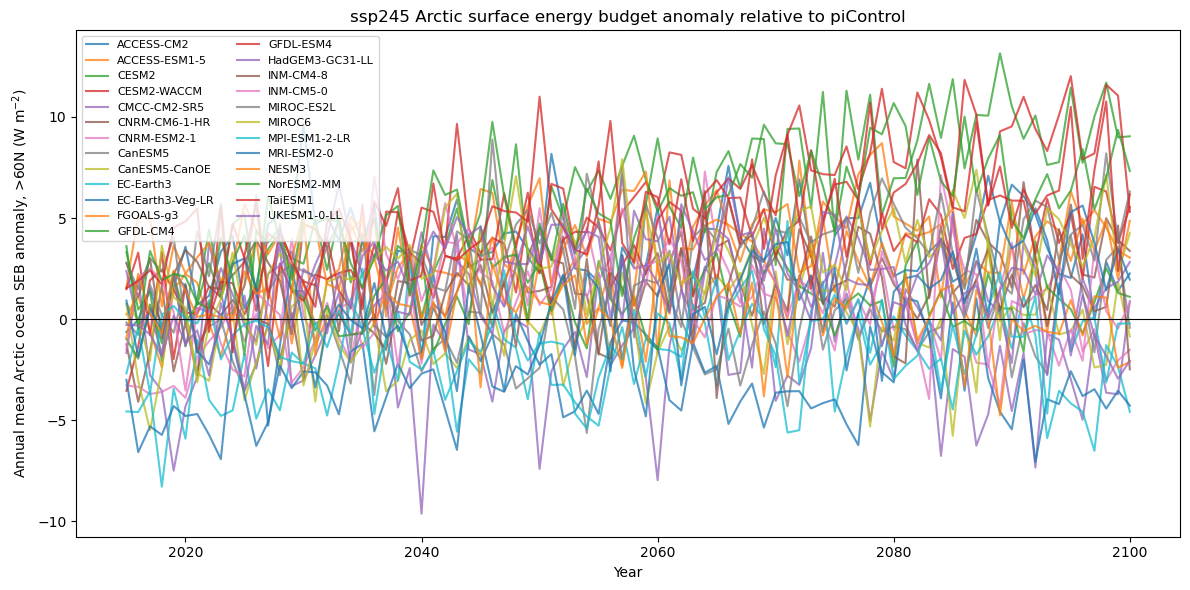

In [19]:
# ============================================================
# Cell 16: Quick SEB anomaly plot
# ============================================================

if not combined_annual_seb_anom.empty:
    plt.figure(figsize=(12, 6))

    for source, sub in combined_annual_seb_anom.groupby("source"):
        plt.plot(
            sub["year"],
            sub["seb_anom_Wm2"],
            label=source,
            alpha=0.75,
        )

    plt.axhline(0, color="black", linewidth=0.8)

    plt.xlabel("Year")
    plt.ylabel("Annual mean Arctic ocean SEB anomaly, >60N (W m$^{-2}$)")
    plt.title(f"{PROJ_EXPERIMENT} Arctic surface energy budget anomaly relative to piControl")
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

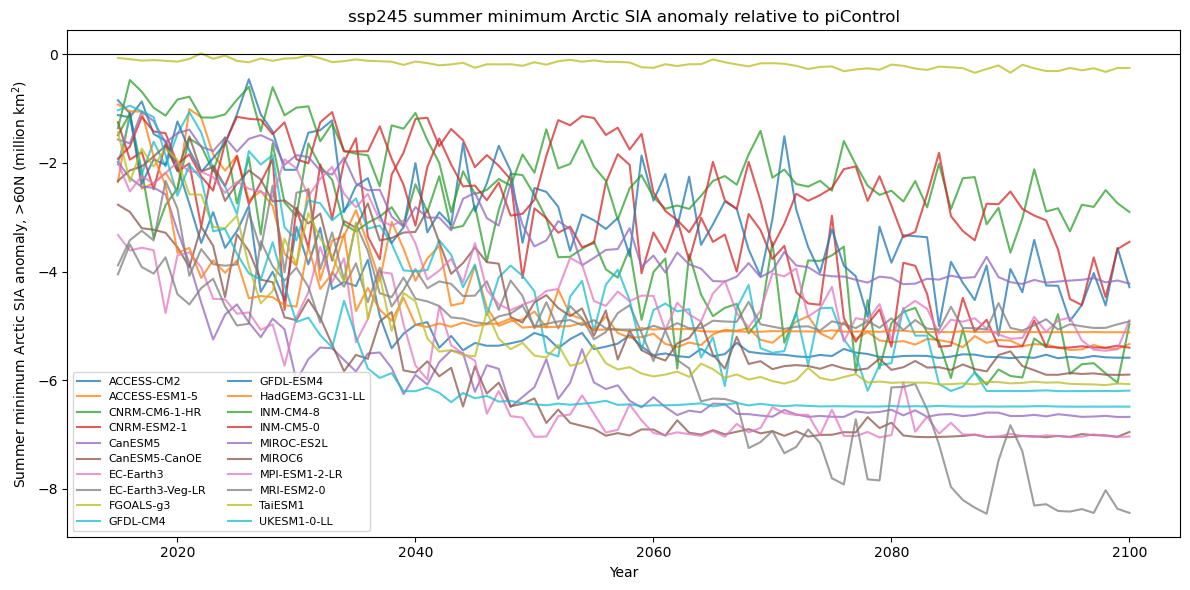

In [20]:
# ============================================================
# Cell 17: Quick summer-minimum SIA anomaly plot
# ============================================================

if not combined_summer_min_sia_anom.empty:
    plt.figure(figsize=(12, 6))

    for source, sub in combined_summer_min_sia_anom.groupby("source"):
        plt.plot(
            sub["year"],
            sub["summer_min_sia_anom_Mkm2"],
            label=source,
            alpha=0.75,
        )

    plt.axhline(0, color="black", linewidth=0.8)

    plt.xlabel("Year")
    plt.ylabel("Summer minimum Arctic SIA anomaly, >60N (million km$^2$)")
    plt.title(f"{PROJ_EXPERIMENT} summer minimum Arctic SIA anomaly relative to piControl")
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

In [21]:
fg = combined_monthly_sia_anom[
    combined_monthly_sia_anom["source"] == "FGOALS-g3"
]

display(fg[["source", "member", "year", "month", "sia_Mkm2", "sia_anom_Mkm2"]].head())

print("SIA range:")
print(fg["sia_Mkm2"].describe())

print("SIA anomaly range:")
print(fg["sia_anom_Mkm2"].describe())

,source,member,year,month,sia_Mkm2,sia_anom_Mkm2
1032,FGOALS-g3,r1i1p1f1,2015,1,1.396686,-0.012689
1033,FGOALS-g3,r1i1p1f1,2015,2,1.433875,0.009610
1034,FGOALS-g3,r1i1p1f1,2015,3,1.413074,-0.001388
1035,FGOALS-g3,r1i1p1f1,2015,4,1.351238,-0.023023
1036,FGOALS-g3,r1i1p1f1,2015,5,1.229612,-0.040572


SIA range:
count    1032.000000
mean        1.002837
std         0.303973
min         0.368241
25%         0.732579
50%         1.045021
75%         1.294287
max         1.440716
Name: sia_Mkm2, dtype: float64
SIA anomaly range:
count    1032.000000
mean       -0.141138
std         0.090031
min        -0.416913
25%        -0.201112
50%        -0.122655
75%        -0.073190
max         0.028683
Name: sia_anom_Mkm2, dtype: float64


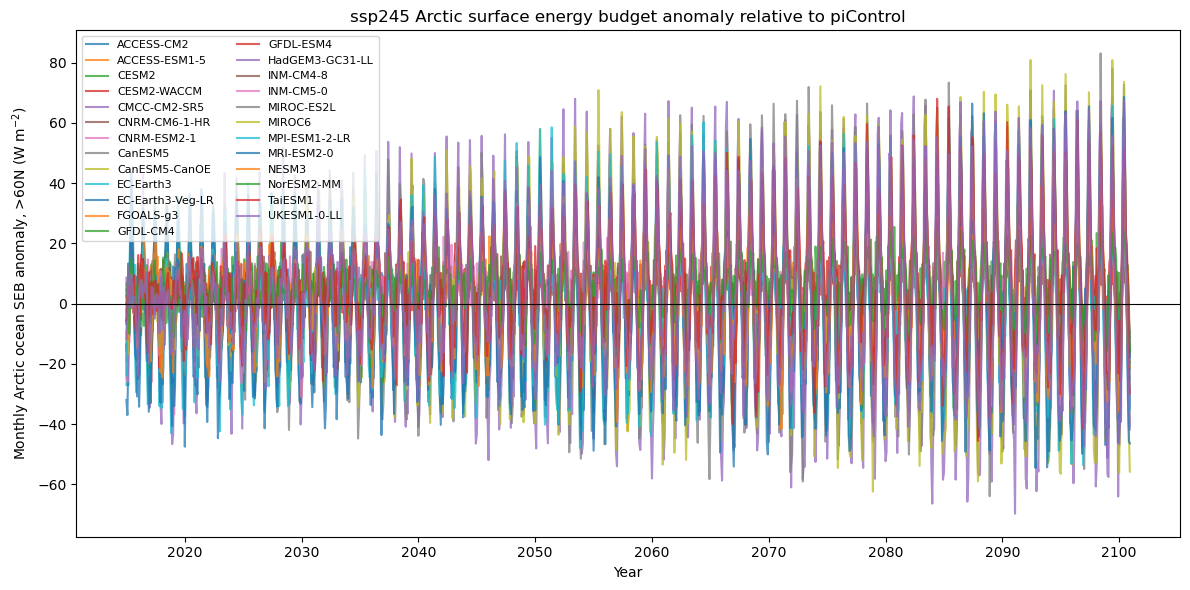

In [22]:
plot_df = combined_monthly_seb_anom.copy()

# Convert pandas Period values like 2030-01 to normal datetimes
plot_df["plot_time"] = plot_df["time"].dt.to_timestamp()

plt.figure(figsize=(12, 6))

for source, sub in plot_df.groupby("source"):
    sub = sub.sort_values("plot_time")

    plt.plot(
        sub["plot_time"],
        sub["seb_anom_Wm2"],
        label=source,
        alpha=0.75,
    )

plt.axhline(0, color="black", linewidth=0.8)

plt.xlabel("Year")
plt.ylabel("Monthly Arctic ocean SEB anomaly, >60N (W m$^{-2}$)")
plt.title(f"{PROJ_EXPERIMENT} Arctic surface energy budget anomaly relative to piControl")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

In [98]:
# ------------------------------------------------------------
# Plot weighted energy vs minSIA anomalies
# ------------------------------------------------------------

START_YEAR = 2030
END_YEAR = 2039   # inclusive


def skewed_gaussian_month_weights(mu, sigma, skew, kurt=2, x=None):
    """
    Circular Gaussian month weights with damped skew.

    sigma controls the overall width.
    Large sigma -> nearly uniform weights, regardless of skew.
    """
    if x is None:
        x = np.arange(1, 13)

    if sigma <= 0:
        return None

    # signed circular month difference in [-6, 6)
    d = (x - mu + 6) % 12 - 6
    
    # Gaussian envelope
    g = np.exp(-0.5 * np.abs(d / sigma) ** kurt)

    # Stronger damping: skew vanishes as sigma becomes large
    skew_damping = 1 / (1 + (sigma / 6) ** 2)
    effective_skew = skew #* skew_damping  #remove the skew damping for now. It is not needed for the level of std dev we are get, and just adds complexity

    theta = 2 * np.pi * d / 12.0
    s = np.exp(effective_skew * np.sin(theta))

    w = g * s

    if np.any(~np.isfinite(w)) or np.isclose(w.sum(), 0):
        return None

    return w / w.sum()

mu=6.866
sigma=2.260
skew=0.036

month_weights = skewed_gaussian_month_weights(mu, sigma, skew)


# month_weights = np.array([
#     1/12,  # Jan
#     1/12,  # Feb
#     1/12,  # Mar
#     1/12,  # Apr
#     1/12,  # May
#     1/12,  # Jun
#     1/12,  # Jul
#     1/12,  # Aug
#     1/12,  # Sep
#     1/12,  # Oct
#     1/12,  # Nov
#     1/12,  # Dec
# ], dtype=float)



# Optional but recommended: check the weights
assert len(month_weights) == 12, "month_weights must have length 12"

print("Sum of weights:", month_weights.sum())

Sum of weights: 0.9999999999999999


In [99]:
# ------------------------------------------------------------
# Select the timeslice
# ------------------------------------------------------------

seb_slice = combined_monthly_seb_anom[
    (combined_monthly_seb_anom["year"] >= START_YEAR)
    & (combined_monthly_seb_anom["year"] <= END_YEAR)
].copy()

sia_slice = combined_summer_min_sia_anom[
    (combined_summer_min_sia_anom["year"] >= START_YEAR)
    & (combined_summer_min_sia_anom["year"] <= END_YEAR)
].copy()

print(f"SEB rows in slice: {len(seb_slice)}")
print(f"SIA rows in slice: {len(sia_slice)}")


SEB rows in slice: 3000
SIA rows in slice: 200


In [100]:

# ------------------------------------------------------------
# Average monthly SEB anomalies over the timeslice
#
# For each model:
#   Q_Jan = mean of all January SEB anomalies from 2030-2040
#   Q_Feb = mean of all February SEB anomalies from 2030-2040
#   ...
# ------------------------------------------------------------

model_cols_seb = [
    "institution",
    "source",
    "member",
    "grid",
    "experiment",
]

monthly_q = (
    seb_slice
    .groupby(model_cols_seb + ["month"], as_index=False)
    .agg(
        mean_monthly_seb_anom_Wm2=("seb_anom_Wm2", "mean"),
    )
)

monthly_q.head()

,institution,source,member,grid,experiment,month,mean_monthly_seb_anom_Wm2
0,AS-RCEC,TaiESM1,r1i1p1f1,gn,ssp245,1,-9.360533
1,AS-RCEC,TaiESM1,r1i1p1f1,gn,ssp245,2,-6.220365
2,AS-RCEC,TaiESM1,r1i1p1f1,gn,ssp245,3,1.510774
3,AS-RCEC,TaiESM1,r1i1p1f1,gn,ssp245,4,2.846017
4,AS-RCEC,TaiESM1,r1i1p1f1,gn,ssp245,5,8.580026


In [101]:
# ------------------------------------------------------------
# Pivot to one row per model, with columns month 1..12
# ------------------------------------------------------------

monthly_q_pivot = (
    monthly_q
    .pivot_table(
        index=model_cols_seb,
        columns="month",
        values="mean_monthly_seb_anom_Wm2",
    )
    .reset_index()
)

# Make sure all months exist as columns, in order 1..12
for m in range(1, 13):
    if m not in monthly_q_pivot.columns:
        monthly_q_pivot[m] = np.nan

monthly_q_pivot = monthly_q_pivot[model_cols_seb + list(range(1, 13))]

monthly_q_pivot.head()

month,institution,source,member,grid,experiment,1,2,3,4,5,6,7,8,9,10,11,12
0,AS-RCEC,TaiESM1,r1i1p1f1,gn,ssp245,-9.360533,-6.220365,1.510774,2.846017,8.580026,17.214705,19.391572,15.964683,8.565480,-1.754650,-10.528049,-3.073342
1,CAS,FGOALS-g3,r1i1p1f1,gn,ssp245,-3.786366,-6.281399,-4.219268,1.964282,5.195087,15.286687,19.351442,14.172053,4.594923,-2.463048,-6.628135,-5.267825
2,CCCma,CanESM5,r1i1p1f1,gn,ssp245,-26.658394,-17.621851,-11.392748,2.375270,18.948915,38.524531,33.847111,17.341826,4.000881,-10.734591,-26.303604,-28.120494
3,CCCma,CanESM5-CanOE,r1i1p2f1,gn,ssp245,-23.636973,-17.041646,-15.988485,1.287123,16.543357,32.423304,31.860078,16.762851,1.194113,-12.307290,-22.261594,-26.773649
4,CMCC,CMCC-CM2-SR5,r1i1p1f1,gn,ssp245,-27.058693,-22.079426,-12.901522,0.819602,19.889726,43.469780,23.558720,9.435143,1.729207,-2.973380,-18.271130,-29.286125


In [102]:
# ------------------------------------------------------------
# Calculate weighted annual energy anomaly:
#
#   Q*_ann = sum_m w_m * Q_m
#
# where Q_m is the mean anomaly for calendar month m
# over the selected timeslice.
# ------------------------------------------------------------

q_values = monthly_q_pivot[list(range(1, 13))].to_numpy(dtype=float)

monthly_q_pivot["Qstar_ann_Wm2"] = np.nansum(
    q_values * month_weights.reshape(1, 12),
    axis=1,
)

# Optional: require all 12 months to be present.
monthly_q_pivot["n_months_available"] = np.isfinite(q_values).sum(axis=1)

qstar_df = monthly_q_pivot[
    monthly_q_pivot["n_months_available"] == 12
].copy()

qstar_df.head()

month,institution,source,member,grid,experiment,1,2,3,4,5,6,7,8,9,10,11,12,Qstar_ann_Wm2,n_months_available
0,AS-RCEC,TaiESM1,r1i1p1f1,gn,ssp245,-9.360533,-6.220365,1.510774,2.846017,8.580026,17.214705,19.391572,15.964683,8.565480,-1.754650,-10.528049,-3.073342,10.458956,12
1,CAS,FGOALS-g3,r1i1p1f1,gn,ssp245,-3.786366,-6.281399,-4.219268,1.964282,5.195087,15.286687,19.351442,14.172053,4.594923,-2.463048,-6.628135,-5.267825,8.759014,12
2,CCCma,CanESM5,r1i1p1f1,gn,ssp245,-26.658394,-17.621851,-11.392748,2.375270,18.948915,38.524531,33.847111,17.341826,4.000881,-10.734591,-26.303604,-28.120494,15.086746,12
3,CCCma,CanESM5-CanOE,r1i1p2f1,gn,ssp245,-23.636973,-17.041646,-15.988485,1.287123,16.543357,32.423304,31.860078,16.762851,1.194113,-12.307290,-22.261594,-26.773649,12.829670,12
4,CMCC,CMCC-CM2-SR5,r1i1p1f1,gn,ssp245,-27.058693,-22.079426,-12.901522,0.819602,19.889726,43.469780,23.558720,9.435143,1.729207,-2.973380,-18.271130,-29.286125,13.191080,12


In [103]:
# ------------------------------------------------------------
# Average summer-minimum SIA anomaly over the same timeslice
# ------------------------------------------------------------

model_cols_sia = [
    "institution",
    "source",
    "member",
    "siconc_grid",
    "experiment",
]

mean_sia = (
    sia_slice
    .groupby(model_cols_sia, as_index=False)
    .agg(
        mean_summer_min_sia_anom_Mkm2=("summer_min_sia_anom_Mkm2", "mean"),
        mean_summer_min_sia_Mkm2=("summer_min_sia_Mkm2", "mean"),
        mean_summer_min_month=("summer_min_month", "mean"),
        n_years=("year", "nunique"),
    )
)

mean_sia.head()

,institution,source,member,siconc_grid,experiment,mean_summer_min_sia_anom_Mkm2,mean_summer_min_sia_Mkm2,mean_summer_min_month,n_years
0,AS-RCEC,TaiESM1,r1i1p1f1,gn,ssp245,-3.963376,2.129946,9.0,10
1,CAS,FGOALS-g3,r1i1p1f1,gn,ssp245,-0.114352,0.597772,9.0,10
2,CCCma,CanESM5,r1i1p1f1,gn,ssp245,-5.692731,0.982988,9.0,10
3,CCCma,CanESM5-CanOE,r1i1p2f1,gn,ssp245,-5.205977,1.842416,9.0,10
4,CNRM-CERFACS,CNRM-CM6-1-HR,r1i1p1f2,gn,ssp245,-2.746827,3.381201,9.0,10


In [104]:
# ------------------------------------------------------------
# Merge weighted energy and SIA anomaly
#
# Merge on institution/source/member/experiment.
# The atmosphere grid and sea-ice grid are usually different,
# so do not merge on grid.
# ------------------------------------------------------------

scatter_df = qstar_df.merge(
    mean_sia,
    on=["institution", "source", "member", "experiment"],
    how="inner",
)

scatter_df = scatter_df.dropna(
    subset=[
        "Qstar_ann_Wm2",
        "mean_summer_min_sia_anom_Mkm2",
    ]
).copy()

print(f"Models in scatter: {len(scatter_df)}")

display(
    scatter_df[
        [
            "source",
            "member",
            "grid",
            "siconc_grid",
            "Qstar_ann_Wm2",
            "mean_summer_min_sia_anom_Mkm2",
            "n_years",
        ]
    ].sort_values("source")
)


Models in scatter: 20


,source,member,grid,siconc_grid,Qstar_ann_Wm2,mean_summer_min_sia_anom_Mkm2,n_years
7,ACCESS-CM2,r1i1p1f1,gn,gn,10.415772,-4.217486,10
6,ACCESS-ESM1-5,r1i1p1f1,gn,gn,7.229070,-3.450236,10
4,CNRM-CM6-1-HR,r1i1p1f2,gr,gn,5.639909,-2.746827,10
5,CNRM-ESM2-1,r1i1p1f2,gr,gn,5.360985,-2.613791,10
2,CanESM5,r1i1p1f1,gn,gn,15.086746,-5.692731,10
3,CanESM5-CanOE,r1i1p2f1,gn,gn,12.829670,-5.205977,10
8,EC-Earth3,r1i1p1f1,gr,gn,9.861402,-4.391185,10
9,EC-Earth3-Veg-LR,r1i1p1f1,gr,gn,10.851331,-4.275878,10
1,FGOALS-g3,r1i1p1f1,gn,gn,8.759014,-0.114352,10
18,GFDL-CM4,r1i1p1f1,gr1,gn,5.564565,-3.128050,10


In [105]:

models_to_use = scatter_df["source"].unique().tolist()

Models available before exclusion: 20
Models excluded: ['FGOALS-g3']
Models retained: 19


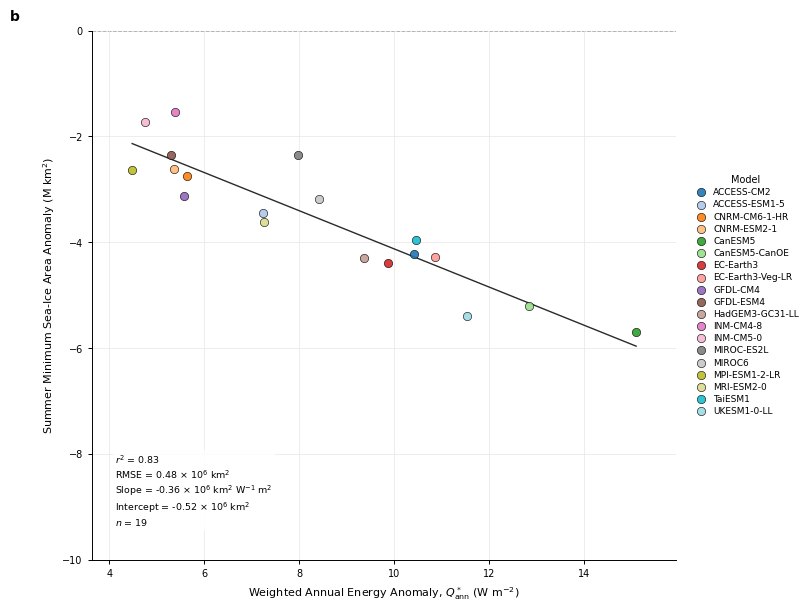

In [106]:

from matplotlib.lines import Line2D

SAVE_FIG = False

# Optional output folder
FIGDIR = Path("Figures")
FIGDIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Models to exclude from plot and fit as outliers
# ------------------------------------------------------------

excluded_models = [
    "FGOALS-g3",
]

# ------------------------------------------------------------
# Figure settings
# ------------------------------------------------------------

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
})

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

# ------------------------------------------------------------
# Data
# ------------------------------------------------------------

x_col = "Qstar_ann_Wm2"
y_col = "mean_summer_min_sia_anom_Mkm2"

plot_df_all = scatter_df.dropna(subset=[x_col, y_col]).copy()

plot_df = plot_df_all[
    ~plot_df_all["source"].isin(excluded_models)
].copy()

excluded_in_plot = sorted(
    set(plot_df_all["source"]).intersection(excluded_models)
)

print(f"Models available before exclusion: {plot_df_all['source'].nunique()}")
print(f"Models excluded: {excluded_in_plot}")
print(f"Models retained: {plot_df['source'].nunique()}")
plot_df = plot_df.sort_values("source")

sources = plot_df["source"].unique()
n_models = len(sources)

# Colourblind-friendly categorical palette.
# tab20 is acceptable for many-model diagnostic / ensemble plots.
cmap = plt.colormaps["tab20"].resampled(max(n_models, 1))
source_colours = {
    source: cmap(i)
    for i, source in enumerate(sources)
}

# ------------------------------------------------------------
# Scatter points
# ------------------------------------------------------------

for source, sub in plot_df.groupby("source", sort=True):
    ax.scatter(
        sub[x_col],
        sub[y_col],
        s=36,
        color=source_colours[source],
        edgecolor="black",
        linewidth=0.45,
        alpha=0.9,
        label=source,
        zorder=3,
    )

# ------------------------------------------------------------
# Linear fit, R², RMSE, slope and intercept
# ------------------------------------------------------------

x = plot_df[x_col].to_numpy(dtype=float)
y = plot_df[y_col].to_numpy(dtype=float)

valid = np.isfinite(x) & np.isfinite(y)
x = x[valid]
y = y[valid]

fit_stats = {}

if len(x) >= 3 and not np.allclose(x, x[0]):
    slope, intercept = np.polyfit(x, y, 1)

    xfit = np.linspace(x.min(), x.max(), 200)
    yfit = slope * xfit + intercept

    y_pred = slope * x + intercept

    residuals = y - y_pred
    rmse = np.sqrt(np.mean(residuals**2))

    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    fit_stats = {
        "slope": slope,
        "intercept": intercept,
        "r2": r2,
        "rmse": rmse,
        "n": len(x),
    }

    ax.plot(
        xfit,
        yfit,
        color="black",
        linewidth=1.0,
        linestyle="-",
        alpha=r2,
        zorder=2,
    )

    # compact stats annotation.
    # Units:
    #   slope: 10^6 km^2 per W m^-2
    #   intercept and RMSE: 10^6 km^2
    stats_text = (
        rf"$r^2$ = {r2:.2f}" "\n"
        rf"RMSE = {rmse:.2f} $\times$ 10$^6$ km$^2$" "\n"
        rf"Slope = {slope:.2f} $\times$ 10$^6$ km$^2$ W$^{{-1}}$ m$^2$" "\n"
        rf"Intercept = {intercept:.2f} $\times$ 10$^6$ km$^2$" "\n"
        rf"$n$ = {len(x)}"
    )

    ax.text(
        0.04,
        0.06,
        stats_text,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=6.8,
        linespacing=1.25,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
        ),
        zorder=5,
    )

# ------------------------------------------------------------
# Reference lines
# ------------------------------------------------------------

ax.axhline(0, color="0.25", linewidth=0.7, linestyle="--", zorder=1)
ax.axvline(0, color="0.25", linewidth=0.7, linestyle="--", zorder=1)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

if np.allclose(month_weights, 1 / 12):
    xlabel = r"Annual Energy Anomaly, $Q_{\mathrm{ann}}$ (W m$^{-2}$)"
    panel_label = 'a'
else:
    xlabel = r"Weighted Annual Energy Anomaly, $Q^*_{\mathrm{ann}}$ (W m$^{-2}$)"
    panel_label = 'b'

ax.set_xlabel(xlabel)
ax.set_ylabel(r"Summer Minimum Sea-Ice Area Anomaly (M km$^2$)")


# ------------------------------------------------------------
# Limits with padding
# ------------------------------------------------------------

xpad = 0.08 * (plot_df[x_col].max() - plot_df[x_col].min())
ypad = 0.08 * (plot_df[y_col].max() - plot_df[y_col].min())

if np.isfinite(xpad) and xpad > 0:
    ax.set_xlim(plot_df[x_col].min() - xpad, plot_df[x_col].max() + xpad)


# ax.set_ylim(plot_df[y_col].min() - ypad, plot_df[y_col].max() + ypad)
ax.set_ylim(-10, 0)

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------

ax.grid(
    True,
    which="major",
    color="0.9",
    linewidth=0.5,
    zorder=0,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Panel label
ax.text(
    -0.14,
    1.04,
    panel_label,
    transform=ax.transAxes,
    fontsize=10,
    fontweight="bold",
    va="top",
    ha="left",
)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

legend = ax.legend(
    title="Model",
    title_fontsize=7,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    handletextpad=0.4,
    borderaxespad=0.0,
    labelspacing=0.35,
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

out_pdf = FIGDIR / f"{PROJ_EXPERIMENT}_{START_YEAR}_{END_YEAR}_Qstar_vs_SIA.pdf"
out_png = FIGDIR / f"{PROJ_EXPERIMENT}_{START_YEAR}_{END_YEAR}_Qstar_vs_SIA.png"

if SAVE_FIG:
    fig.savefig(out_pdf, bbox_inches="tight")
    fig.savefig(out_png, dpi=600, bbox_inches="tight")

plt.show()

if SAVE_FIG:
    print(f"Saved: {out_pdf}")
    print(f"Saved: {out_png}")

Models available before exclusion: 20
Models excluded: ['FGOALS-g3']
Models retained in highlighted scatter: 19


Rolling windows plotted: 31 (2020–2029 to 2050–2059)
Models retained in rolling trajectories: 19


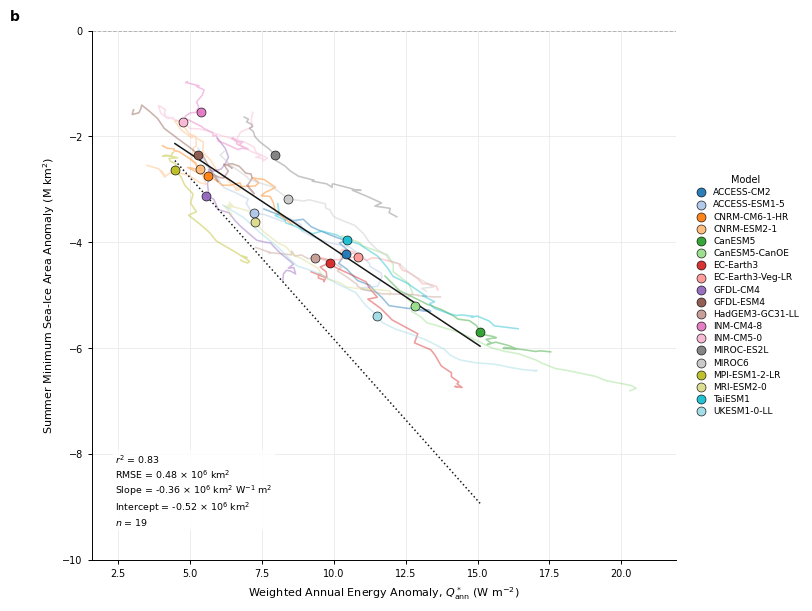

Fit statistics for highlighted scatter points only:
  slope: -0.3611013872784933
  intercept: -0.5166898099286132
  r2: 0.8343302005132699
  rmse: 0.47627505938882486
  n: 19


In [124]:
# ============================================================
# Q* vs summer-minimum SIA anomaly
# Current selected decade as scatter + regression
# Rolling 10-year windows as model trajectories
# ============================================================


# ------------------------------------------------------------
# User settings
# ------------------------------------------------------------

SAVE_FIG = False

FIGDIR = Path("Figures")
FIGDIR.mkdir(exist_ok=True)

# Current highlighted decade.
# These should match the scatter_df you already created.
# Regression is performed only on this highlighted decade.
# START_YEAR = 2030
# END_YEAR = 2040

# Rolling 10-year trajectories:
# 2020-2029, 2021-2030, ..., 2040-2049
ROLLING_START_YEAR = 2020
ROLLING_FINAL_START_YEAR = 2050
WINDOW_LENGTH = 10

excluded_models = [
    "FGOALS-g3",
]

x_col = "Qstar_ann_Wm2"
y_col = "mean_summer_min_sia_anom_Mkm2"

# ------------------------------------------------------------
# Figure settings
# ------------------------------------------------------------

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
})


# ============================================================
# Helper: make Q* vs SIA dataframe for any year window
# ============================================================

def make_qstar_sia_window_df(
    combined_monthly_seb_anom,
    combined_summer_min_sia_anom,
    month_weights,
    start_year,
    end_year,
    require_all_months=True,
    require_all_years=True,
):
    """
    Build one row per model for a given year window.

    Q* is calculated from monthly mean SEB anomalies over the window:
        Q* = sum_m w_m Q_m

    SIA is the mean annual summer-minimum SIA anomaly over the same window.
    """

    seb = combined_monthly_seb_anom[
        (combined_monthly_seb_anom["year"] >= start_year)
        & (combined_monthly_seb_anom["year"] <= end_year)
    ].copy()

    sia = combined_summer_min_sia_anom[
        (combined_summer_min_sia_anom["year"] >= start_year)
        & (combined_summer_min_sia_anom["year"] <= end_year)
    ].copy()

    # Reconstruct total SEB if needed
    if "seb_anom_Wm2" not in seb.columns:
        component_cols = [
            "rsds_into_surface_Wm2_anom",
            "rlds_into_surface_Wm2_anom",
            "rsus_into_surface_Wm2_anom",
            "rlus_into_surface_Wm2_anom",
            "hfss_into_surface_Wm2_anom",
            "hfls_into_surface_Wm2_anom",
        ]

        missing = [c for c in component_cols if c not in seb.columns]

        if missing:
            raise ValueError(
                "Cannot reconstruct total SEB because these columns are missing: "
                + ", ".join(missing)
            )

        seb["seb_anom_Wm2"] = seb[component_cols].sum(axis=1)

    weights = np.asarray(month_weights, dtype=float)

    if weights.size != 12:
        raise ValueError("month_weights must have length 12.")

    # --------------------------------------------------------
    # Q*: monthly climatology over the window, then weighted sum
    # --------------------------------------------------------

    model_cols_seb = [
        c for c in ["institution", "source", "member", "grid", "experiment"]
        if c in seb.columns
    ]

    monthly_q = (
        seb
        .groupby(model_cols_seb + ["month"], as_index=False)
        .agg(mean_monthly_seb_anom_Wm2=("seb_anom_Wm2", "mean"))
    )

    monthly_q_pivot = (
        monthly_q
        .pivot_table(
            index=model_cols_seb,
            columns="month",
            values="mean_monthly_seb_anom_Wm2",
        )
        .reset_index()
    )

    for month in range(1, 13):
        if month not in monthly_q_pivot.columns:
            monthly_q_pivot[month] = np.nan

    monthly_q_pivot = monthly_q_pivot[
        model_cols_seb + list(range(1, 13))
    ]

    q_values = monthly_q_pivot[list(range(1, 13))].to_numpy(dtype=float)

    monthly_q_pivot["n_months_available"] = np.isfinite(q_values).sum(axis=1)

    monthly_q_pivot["Qstar_ann_Wm2"] = np.nansum(
        q_values * weights.reshape(1, 12),
        axis=1,
    )

    qstar_df = monthly_q_pivot.copy()

    if require_all_months:
        qstar_df = qstar_df[qstar_df["n_months_available"] == 12].copy()

    # --------------------------------------------------------
    # SIA: mean annual summer-minimum SIA anomaly over window
    # --------------------------------------------------------

    model_cols_sia = [
        c for c in ["institution", "source", "member", "experiment"]
        if c in sia.columns
    ]

    mean_sia = (
        sia
        .groupby(model_cols_sia, as_index=False)
        .agg(
            mean_summer_min_sia_anom_Mkm2=(
                "summer_min_sia_anom_Mkm2",
                "mean",
            ),
            n_years=("year", "nunique"),
        )
    )

    expected_n_years = end_year - start_year + 1

    if require_all_years:
        mean_sia = mean_sia[
            mean_sia["n_years"] == expected_n_years
        ].copy()

    # --------------------------------------------------------
    # Merge Q* and SIA
    # --------------------------------------------------------

    merge_cols = [
        c for c in ["institution", "source", "member", "experiment"]
        if c in qstar_df.columns and c in mean_sia.columns
    ]

    out = qstar_df.merge(
        mean_sia,
        on=merge_cols,
        how="inner",
    )

    out["window_start"] = start_year
    out["window_end"] = end_year
    out["window_label"] = f"{start_year}–{end_year}"

    return out


# ============================================================
# Data: highlighted scatter points
# ============================================================

# scatter_df should already contain the selected START_YEAR-END_YEAR values.
# Regression is performed only on these points.
plot_df_all = scatter_df.dropna(subset=[x_col, y_col]).copy()

plot_df = plot_df_all[
    ~plot_df_all["source"].isin(excluded_models)
].copy()

excluded_in_plot = sorted(
    set(plot_df_all["source"]).intersection(excluded_models)
)

print(f"Models available before exclusion: {plot_df_all['source'].nunique()}")
print(f"Models excluded: {excluded_in_plot}")
print(f"Models retained in highlighted scatter: {plot_df['source'].nunique()}")

plot_df = plot_df.sort_values("source")

sources = plot_df["source"].unique()
n_models = len(sources)

# Colourblind-friendly categorical palette.
# Use the same colour for a model's trajectory and highlighted scatter point.
cmap = plt.colormaps["tab20"].resampled(max(n_models, 1))

source_colours = {
    source: cmap(i)
    for i, source in enumerate(sources)
}


# ============================================================
# Data: rolling 10-year trajectories
# ============================================================

rolling_records = []

for window_start in range(ROLLING_START_YEAR, ROLLING_FINAL_START_YEAR + 1):
    window_end = window_start + WINDOW_LENGTH - 1

    tmp = make_qstar_sia_window_df(
        combined_monthly_seb_anom=combined_monthly_seb_anom,
        combined_summer_min_sia_anom=combined_summer_min_sia_anom,
        month_weights=month_weights,
        start_year=window_start,
        end_year=window_end,
        require_all_months=True,
        require_all_years=True,
    )

    rolling_records.append(tmp)

rolling_df_all = pd.concat(rolling_records, ignore_index=True)

# Keep only the same retained models as the highlighted scatter.
rolling_df = rolling_df_all[
    (~rolling_df_all["source"].isin(excluded_models))
    & (rolling_df_all["source"].isin(sources))
].copy()

rolling_df = rolling_df.dropna(subset=[x_col, y_col]).copy()

print(
    f"Rolling windows plotted: "
    f"{rolling_df['window_label'].nunique()} "
    f"({ROLLING_START_YEAR}–{ROLLING_START_YEAR + WINDOW_LENGTH - 1} to "
    f"{ROLLING_FINAL_START_YEAR}–{ROLLING_FINAL_START_YEAR + WINDOW_LENGTH - 1})"
)

print(f"Models retained in rolling trajectories: {rolling_df['source'].nunique()}")


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)


# ------------------------------------------------------------
# Rolling decadal trajectories
# ------------------------------------------------------------

for source, sub in rolling_df.groupby("source", sort=True):
    sub = sub.sort_values("window_start")

    ax.plot(
        sub[x_col],
        sub[y_col],
        color=source_colours[source],
        linewidth=1.15,
        alpha=0.45,
        zorder=2,
    )


# ------------------------------------------------------------
# Highlighted current-decade scatter points
# ------------------------------------------------------------

for source, sub in plot_df.groupby("source", sort=True):
    ax.scatter(
        sub[x_col],
        sub[y_col],
        s=42,
        color=source_colours[source],
        edgecolor="black",
        linewidth=0.45,
        alpha=0.95,
        label=source,
        zorder=4,
    )


# ------------------------------------------------------------
# Linear fit, R², RMSE, slope and intercept
# Regression uses only highlighted scatter points
# ------------------------------------------------------------

x = plot_df[x_col].to_numpy(dtype=float)
y = plot_df[y_col].to_numpy(dtype=float)

valid = np.isfinite(x) & np.isfinite(y)
x = x[valid]
y = y[valid]

fit_stats = {}

if len(x) >= 3 and not np.allclose(x, x[0]):
    slope, intercept = np.polyfit(x, y, 1)

    xfit = np.linspace(x.min(), x.max(), 200)
    yfit = slope * xfit + intercept

    y_pred = slope * x + intercept

    residuals = y - y_pred
    rmse = np.sqrt(np.mean(residuals**2))

    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    fit_stats = {
        "slope": slope,
        "intercept": intercept,
        "r2": r2,
        "rmse": rmse,
        "n": len(x),
    }
    if not np.allclose(month_weights, 1 / 12):
        ax.plot(
            xfit,
            yfit,
            color="black",
            linewidth=1.1,
            linestyle="-",
            alpha=0.9,
            zorder=3,
        )

        #plot another line with this slope = -0.611, intercept = 0.282
        ax.plot(
            xfit,
            -0.611 * xfit + 0.282,
            color="black",
            linewidth=1.1,
            linestyle=":",
            alpha=0.9,
            zorder=3,
        )

    stats_text = (
        rf"$r^2$ = {r2:.2f}" "\n"
        rf"RMSE = {rmse:.2f} $\times$ 10$^6$ km$^2$" "\n"
        rf"Slope = {slope:.2f} $\times$ 10$^6$ km$^2$ W$^{{-1}}$ m$^2$" "\n"
        rf"Intercept = {intercept:.2f} $\times$ 10$^6$ km$^2$" "\n"
        rf"$n$ = {len(x)}"
    )

    ax.text(
        0.04,
        0.06,
        stats_text,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=6.8,
        linespacing=1.25,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
        ),
        zorder=6,
    )


# ------------------------------------------------------------
# Reference lines
# ------------------------------------------------------------

ax.axhline(0, color="0.25", linewidth=0.7, linestyle="--", zorder=1)
ax.axvline(0, color="0.25", linewidth=0.7, linestyle="--", zorder=1)


# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

if np.allclose(month_weights, 1 / 12):
    xlabel = r"Annual Energy Anomaly, $Q_{\mathrm{ann}}$ (W m$^{-2}$)"
    panel_label = "a"
else:
    xlabel = r"Weighted Annual Energy Anomaly, $Q^*_{\mathrm{ann}}$ (W m$^{-2}$)"
    panel_label = "b"

ax.set_xlabel(xlabel)
ax.set_ylabel(r"Summer Minimum Sea-Ice Area Anomaly (M km$^2$)")

# ax.set_title(
#     f"Scatter/regression: {START_YEAR}–{END_YEAR}; "
#     f"lines: rolling {WINDOW_LENGTH}-year means"
# )


# ------------------------------------------------------------
# Limits with padding, including rolling trajectories
# ------------------------------------------------------------

limits_df = pd.concat(
    [
        plot_df[[x_col, y_col]],
        rolling_df[[x_col, y_col]],
    ],
    ignore_index=True,
).dropna()

xpad = 0.08 * (limits_df[x_col].max() - limits_df[x_col].min())
ypad = 0.08 * (limits_df[y_col].max() - limits_df[y_col].min())

if np.isfinite(xpad) and xpad > 0:
    ax.set_xlim(
        limits_df[x_col].min() - xpad,
        limits_df[x_col].max() + xpad,
    )

# Keep fixed y-axis 
ax.set_ylim(-10, 0)

# Or use dynamic limits instead:
# if np.isfinite(ypad) and ypad > 0:
#     ax.set_ylim(
#         limits_df[y_col].min() - ypad,
#         limits_df[y_col].max() + ypad,
#     )


# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------

ax.grid(
    True,
    which="major",
    color="0.9",
    linewidth=0.5,
    zorder=0,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Panel label
ax.text(
    -0.14,
    1.04,
    panel_label,
    transform=ax.transAxes,
    fontsize=10,
    fontweight="bold",
    va="top",
    ha="left",
)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

legend = ax.legend(
    title="Model",
    title_fontsize=7,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    handletextpad=0.4,
    borderaxespad=0.0,
    labelspacing=0.35,
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

out_pdf = (
    FIGDIR
    / f"{PROJ_EXPERIMENT}_{START_YEAR}_{END_YEAR}_Qstar_vs_SIA_rolling_decades.pdf"
)

out_png = (
    FIGDIR
    / f"{PROJ_EXPERIMENT}_{START_YEAR}_{END_YEAR}_Qstar_vs_SIA_rolling_decades.png"
)

if SAVE_FIG:
    fig.savefig(out_pdf, bbox_inches="tight")
    fig.savefig(out_png, dpi=600, bbox_inches="tight")

plt.show()

if SAVE_FIG:
    print(f"Saved: {out_pdf}")
    print(f"Saved: {out_png}")

if fit_stats:
    print("Fit statistics for highlighted scatter points only:")
    for k, v in fit_stats.items():
        print(f"  {k}: {v}")

In [108]:
# ============================================================
# Component-month decomposition of weighted SEB predictor
# ============================================================

FIGDIR = Path("Figures")
FIGDIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# User settings
# ------------------------------------------------------------

START_YEAR = 2030
END_YEAR = 2040

EXCLUDED_MODELS = [
    "FGOALS-g3",
]

month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec",
}

component_cols = [
    "rsds_into_surface_Wm2_anom",
    "rlds_into_surface_Wm2_anom",
    "rsus_into_surface_Wm2_anom",
    "rlus_into_surface_Wm2_anom",
    "hfss_into_surface_Wm2_anom",
    "hfls_into_surface_Wm2_anom",
]

component_labels = {
    "rsds_into_surface_Wm2_anom": r"$\Delta S_{\downarrow}$",
    "rlds_into_surface_Wm2_anom": r"$\Delta L_{\downarrow}$",
    "rsus_into_surface_Wm2_anom": r"$-\Delta S_{\uparrow}$",
    "rlus_into_surface_Wm2_anom": r"$-\Delta L_{\uparrow}$",
    "hfss_into_surface_Wm2_anom": r"$-\Delta \theta_{S}$",
    "hfls_into_surface_Wm2_anom": r"$-\Delta \theta_{L}$",
}

# Make sure the weights are a numpy array
month_weights = np.asarray(month_weights, dtype=float)
assert month_weights.size == 12, "month_weights must have length 12"

uniform_weights = np.ones(12) / 12
weight_lookup = {m: month_weights[m - 1] for m in range(1, 13)}
uniform_lookup = {m: uniform_weights[m - 1] for m in range(1, 13)}

In [109]:
# ------------------------------------------------------------
# Select timeslice and exclude outliers
# ------------------------------------------------------------

excluded_models = set(EXCLUDED_MODELS)

seb_slice = combined_monthly_seb_anom[
    (combined_monthly_seb_anom["year"] >= START_YEAR)
    & (combined_monthly_seb_anom["year"] <= END_YEAR)
    & (~combined_monthly_seb_anom["source"].isin(excluded_models))
].copy()

sia_slice = combined_summer_min_sia_anom[
    (combined_summer_min_sia_anom["year"] >= START_YEAR)
    & (combined_summer_min_sia_anom["year"] <= END_YEAR)
    & (~combined_summer_min_sia_anom["source"].isin(excluded_models))
].copy()

model_cols = ["institution", "source", "member", "experiment"]

print(f"SEB models: {seb_slice['source'].nunique()}")
print(f"SIA models: {sia_slice['source'].nunique()}")

SEB models: 24
SIA models: 19


In [110]:
# ------------------------------------------------------------
# Mean monthly component anomalies over the selected timeslice
# ------------------------------------------------------------

monthly_components = (
    seb_slice
    .groupby(model_cols + ["month"], as_index=False)[component_cols]
    .mean()
)

monthly_components["month_name"] = monthly_components["month"].map(month_names)
monthly_components["weight"] = monthly_components["month"].map(weight_lookup)
monthly_components["uniform_weight"] = monthly_components["month"].map(uniform_lookup)

# Long form: one row per model × month × component
comp_long = monthly_components.melt(
    id_vars=model_cols + ["month", "month_name", "weight", "uniform_weight"],
    value_vars=component_cols,
    var_name="component",
    value_name="component_anom_Wm2",
)

comp_long["component_label"] = comp_long["component"].map(component_labels)

# Weighted and unweighted component contributions to annual Q
comp_long["weighted_contribution_Wm2"] = (
    comp_long["weight"] * comp_long["component_anom_Wm2"]
)

comp_long["uniform_contribution_Wm2"] = (
    comp_long["uniform_weight"] * comp_long["component_anom_Wm2"]
)

comp_long["extra_weighting_contribution_Wm2"] = (
    comp_long["weighted_contribution_Wm2"]
    - comp_long["uniform_contribution_Wm2"]
)

comp_long.head()

,institution,source,member,experiment,month,month_name,weight,uniform_weight,component,component_anom_Wm2,component_label,weighted_contribution_Wm2,uniform_contribution_Wm2,extra_weighting_contribution_Wm2
0,AS-RCEC,TaiESM1,r1i1p1f1,ssp245,1,Jan,0.006113,0.083333,rsds_into_surface_Wm2_anom,-0.105819,$\Delta S_{\downarrow}$,-0.000647,-0.008818,0.008171
1,AS-RCEC,TaiESM1,r1i1p1f1,ssp245,2,Feb,0.017173,0.083333,rsds_into_surface_Wm2_anom,-0.540092,$\Delta S_{\downarrow}$,-0.009275,-0.045008,0.035733
2,AS-RCEC,TaiESM1,r1i1p1f1,ssp245,3,Mar,0.039883,0.083333,rsds_into_surface_Wm2_anom,-3.234761,$\Delta S_{\downarrow}$,-0.129011,-0.269563,0.140553
3,AS-RCEC,TaiESM1,r1i1p1f1,ssp245,4,Apr,0.076816,0.083333,rsds_into_surface_Wm2_anom,-10.467199,$\Delta S_{\downarrow}$,-0.804045,-0.872267,0.068221
4,AS-RCEC,TaiESM1,r1i1p1f1,ssp245,5,May,0.122819,0.083333,rsds_into_surface_Wm2_anom,-19.134635,$\Delta S_{\downarrow}$,-2.350101,-1.594553,-0.755548


In [111]:
# ------------------------------------------------------------
# Mean summer minimum SIA anomaly over the selected timeslice
# ------------------------------------------------------------

mean_sia = (
    sia_slice
    .groupby(model_cols, as_index=False)
    .agg(
        mean_summer_min_sia_anom_Mkm2=("summer_min_sia_anom_Mkm2", "mean"),
        mean_summer_min_sia_Mkm2=("summer_min_sia_Mkm2", "mean"),
        n_years=("year", "nunique"),
    )
)

analysis_df = comp_long.merge(
    mean_sia,
    on=model_cols,
    how="inner",
)

print(f"Models in component analysis: {analysis_df['source'].nunique()}")

Models in component analysis: 19


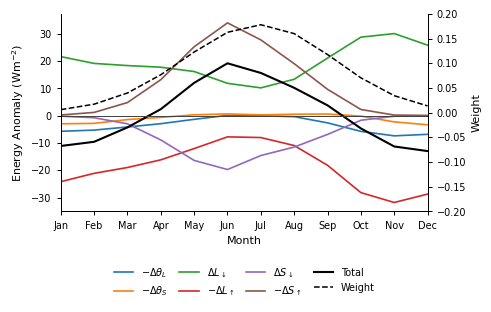

In [112]:
# ============================================================
# Figure 1: Seasonal component anomalies + weights
# ============================================================

seasonal_mean = (
    analysis_df
    .groupby(["month", "month_name", "component", "component_label"], as_index=False)
    .agg(
        mean_component_anom_Wm2=("component_anom_Wm2", "mean"),
        std_component_anom_Wm2=("component_anom_Wm2", "std"),
    )
)

fig, ax = plt.subplots(figsize=(4.8, 3.0), constrained_layout=True)
mmm = np.zeros(12)
for component, sub in seasonal_mean.groupby("component", sort=False):
    sub = sub.sort_values("month")
    label = component_labels[component]

    ax.plot(
        sub["month"],
        sub["mean_component_anom_Wm2"],
        #marker="o",
        markersize=3,
        linewidth=1.2,
        label=label,
    )
    mmm += sub["mean_component_anom_Wm2"].to_numpy(dtype=float)

ax.plot(
    range(1, 13),
    mmm,
    color="black",
    linewidth=1.5,
    label="Total",
)

ax.axhline(0, color="0.25", linewidth=0.7)

ax.set_xticks(range(1, 13))
ax.set_xticklabels([month_names[m] for m in range(1, 13)])
ax.set_ylabel(r"Energy Anomaly (Wm$^{-2}$)")
ax.set_xlabel("Month")

ax.set_xlim(1, 12)

# Overlay weights on second axis
ax2 = ax.twinx()
ax2.plot(
    range(1, 13),
    month_weights,
    color="black",
    linestyle="--",
    linewidth=1.1,
    label="Weight",
)
ax2.set_ylabel("Weight")
ax2.set_ylim(0, max(month_weights) * 1.25)

ax.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

ax2.set_ylim(-0.2,0.2)
# Combined legend
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

handles = handles1 + handles2
labels = labels1 + labels2

ax.legend(
    handles,
    labels,
    frameon=False,
    fontsize=7,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.23),
    columnspacing=1.2,
    handlelength=2.0,
)

fig.savefig(
    FIGDIR / f"{PROJ_EXPERIMENT}_{START_YEAR}_{END_YEAR}_seasonal_components_weights.pdf",
    bbox_inches="tight",
)
fig.savefig(
    FIGDIR / f"{PROJ_EXPERIMENT}_{START_YEAR}_{END_YEAR}_seasonal_components_weights.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

In [38]:
# ============================================================
# Component × month covariance contribution
# ============================================================

def covariance(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 2:
        return np.nan

    return np.mean((x - x.mean()) * (y - y.mean()))


# First calculate model-level total Qstar
qstar_by_model = (
    analysis_df
    .groupby(model_cols, as_index=False)
    .agg(
        Qstar_ann_Wm2=("weighted_contribution_Wm2", "sum"),
        Qann_uniform_Wm2=("uniform_contribution_Wm2", "sum"),
        mean_summer_min_sia_anom_Mkm2=("mean_summer_min_sia_anom_Mkm2", "first"),
    )
)

total_cov = covariance(
    qstar_by_model["Qstar_ann_Wm2"],
    qstar_by_model["mean_summer_min_sia_anom_Mkm2"],
)

print("Total covariance between Q* and SIA anomaly:", total_cov)

cov_records = []

for (component, month), sub in analysis_df.groupby(["component", "month"]):
    # One value per model for this component-month
    feature = sub[model_cols + ["weighted_contribution_Wm2", "mean_summer_min_sia_anom_Mkm2"]].copy()

    cov_cm = covariance(
        feature["weighted_contribution_Wm2"],
        feature["mean_summer_min_sia_anom_Mkm2"],
    )

    if np.isfinite(total_cov) and total_cov != 0:
        contribution_percent = 100 * cov_cm / total_cov
    else:
        contribution_percent = np.nan

    cov_records.append({
        "component": component,
        "component_label": component_labels[component],
        "month": month,
        "month_name": month_names[month],
        "covariance": cov_cm,
        "contribution_percent": contribution_percent,
    })

cov_df = pd.DataFrame(cov_records)

cov_pivot = (
    cov_df
    .pivot(index="component_label", columns="month", values="contribution_percent")
    .loc[[component_labels[c] for c in component_cols]]
)

cov_pivot

Total covariance between Q* and SIA anomaly: -3.262089355321312


month,1,2,3,4,5,6,7,8,9,10,11,12
component_label,,,,,,,,,,,,
$\Delta S_{\downarrow}$,-0.002426,-0.073084,-0.664660,-4.952670,-18.975854,-31.066043,-19.387195,-10.690039,-8.779046,-1.389260,-0.053700,-0.006734
$\Delta L_{\downarrow}$,0.912275,2.750641,4.901879,9.492545,14.457589,8.811609,6.930708,10.240504,23.121633,18.833505,9.559075,3.054931
$-\Delta S_{\uparrow}$,0.005517,0.094183,0.997126,6.727378,25.636212,70.573363,68.679715,34.075043,12.769565,1.747972,0.097269,0.007793
$-\Delta L_{\uparrow}$,-1.290354,-3.423908,-6.370243,-9.570486,-9.784682,-6.852459,-9.269476,-12.430335,-20.088003,-19.032625,-10.780972,-3.759917
$-\Delta \theta_{S}$,-0.436524,-0.644397,-1.426644,-1.811394,-1.156809,1.379654,1.304395,0.661738,-1.645683,-3.698415,-2.282788,-1.048977
$-\Delta \theta_{L}$,-0.310286,-0.618162,-1.357377,-2.016885,-1.494236,0.113411,1.214041,-0.148207,-3.082144,-4.177212,-2.204964,-0.895991


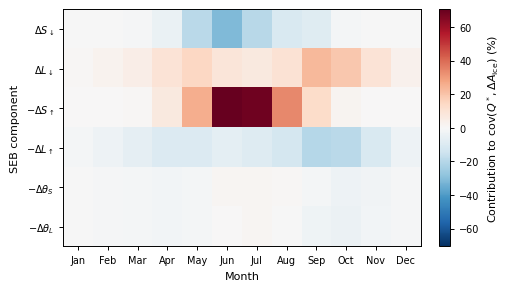

In [39]:
# ------------------------------------------------------------
# Plot heatmap
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(5.0, 2.8), constrained_layout=True)

vmax = np.nanmax(np.abs(cov_pivot.to_numpy()))
im = ax.imshow(
    cov_pivot.to_numpy(),
    aspect="auto",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)

ax.set_xticks(np.arange(12))
ax.set_xticklabels([month_names[m] for m in range(1, 13)])

ax.set_yticks(np.arange(len(cov_pivot.index)))
ax.set_yticklabels(cov_pivot.index)

ax.set_xlabel("Month")
ax.set_ylabel("SEB component")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"Contribution to cov$(Q^*, \Delta A_{\mathrm{ice}})$ (%)")

ax.set_title("")  # keep title out for publication

fig.savefig(
    FIGDIR / f"{PROJ_EXPERIMENT}_{START_YEAR}_{END_YEAR}_component_month_covariance_heatmap.pdf",
    bbox_inches="tight",
)
fig.savefig(
    FIGDIR / f"{PROJ_EXPERIMENT}_{START_YEAR}_{END_YEAR}_component_month_covariance_heatmap.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

In [40]:
#####################
#Repeat above, but looking at how much extra you get from the weighting scheme, rather than just the weighted contribution
#Need to tidy this up to make it a funtion that can be called based on the column used
#####################

cov_records = []

for (component, month), sub in analysis_df.groupby(["component", "month"]):
    # One value per model for this component-month
    feature = sub[model_cols + ["extra_weighting_contribution_Wm2", "mean_summer_min_sia_anom_Mkm2"]].copy()

    cov_cm = covariance(
        feature["extra_weighting_contribution_Wm2"],
        feature["mean_summer_min_sia_anom_Mkm2"],
    )

    if np.isfinite(total_cov) and total_cov != 0:
        contribution_percent = 100 * cov_cm / total_cov
    else:
        contribution_percent = np.nan

    cov_records.append({
        "component": component,
        "component_label": component_labels[component],
        "month": month,
        "month_name": month_names[month],
        "covariance": cov_cm,
        "contribution_percent": contribution_percent,
    })

cov_df = pd.DataFrame(cov_records)

cov_pivot = (
    cov_df
    .pivot(index="component_label", columns="month", values="contribution_percent")
    .loc[[component_labels[c] for c in component_cols]]
)

cov_pivot

month,1,2,3,4,5,6,7,8,9,10,11,12
component_label,,,,,,,,,,,,
$\Delta S_{\downarrow}$,0.030652,0.281555,0.724124,0.420221,-6.100662,-15.159389,-10.314374,-5.125056,-2.562316,0.252552,0.076360,0.034246
$\Delta L_{\downarrow}$,-11.524421,-10.596814,-5.340425,-0.805418,4.648058,4.299827,3.687275,4.909538,6.748448,-3.423715,-13.592941,-15.536331
$-\Delta S_{\uparrow}$,-0.069690,-0.362837,-1.086333,-0.570801,8.241941,34.437893,36.538978,16.336376,3.727018,-0.317761,-0.138316,-0.039631
$-\Delta L_{\uparrow}$,16.300558,13.190571,6.940156,0.812031,-3.145737,-3.343815,-4.931546,-5.959395,-5.863031,3.459913,15.330470,19.121645
$-\Delta \theta_{S}$,5.514446,2.482534,1.554279,0.153692,-0.371909,0.673234,0.693964,0.317253,-0.480321,0.672330,3.246109,5.334736
$-\Delta \theta_{L}$,3.919723,2.381464,1.478815,0.171128,-0.480391,0.055342,0.645894,-0.071054,-0.899577,0.759369,3.135444,4.556702


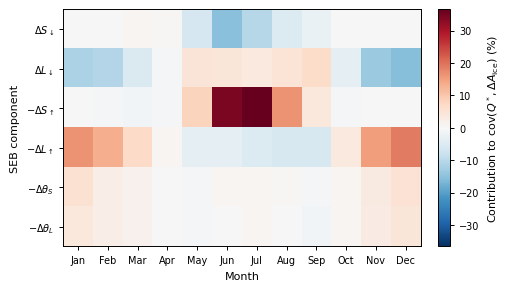

In [41]:
# ------------------------------------------------------------
# Plot heatmap
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(5.0, 2.8), constrained_layout=True)

vmax = np.nanmax(np.abs(cov_pivot.to_numpy()))
im = ax.imshow(
    cov_pivot.to_numpy(),
    aspect="auto",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)

ax.set_xticks(np.arange(12))
ax.set_xticklabels([month_names[m] for m in range(1, 13)])

ax.set_yticks(np.arange(len(cov_pivot.index)))
ax.set_yticklabels(cov_pivot.index)

ax.set_xlabel("Month")
ax.set_ylabel("SEB component")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"Contribution to cov$(Q^*, \Delta A_{\mathrm{ice}})$ (%)")

ax.set_title("")  # keep title out for publication



plt.show()

In [42]:
def fit_metrics(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 3 or np.allclose(x, x[0]):
        return {
            "slope": np.nan,
            "intercept": np.nan,
            "r2": np.nan,
            "rmse": np.nan,
            "n": len(x),
        }

    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept

    residuals = y - y_pred
    rmse = np.sqrt(np.mean(residuals**2))

    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return {
        "slope": slope,
        "intercept": intercept,
        "r2": r2,
        "rmse": rmse,
        "n": len(x),
    }

In [43]:
# ------------------------------------------------------------
# Build baseline model-level predictors
# ------------------------------------------------------------

model_cols = ["institution", "source", "member", "experiment"]

model_base = (
    analysis_df
    .groupby(model_cols, as_index=False)
    .agg(
        Q_uniform_Wm2=("uniform_contribution_Wm2", "sum"),
        Q_weighted_Wm2=("weighted_contribution_Wm2", "sum"),
        mean_summer_min_sia_anom_Mkm2=("mean_summer_min_sia_anom_Mkm2", "first"),
    )
)

y = model_base["mean_summer_min_sia_anom_Mkm2"]

cov_uniform = covariance(model_base["Q_uniform_Wm2"], y)
cov_weighted = covariance(model_base["Q_weighted_Wm2"], y)
cov_improvement_full = cov_weighted - cov_uniform

metrics_uniform = fit_metrics(model_base["Q_uniform_Wm2"], y)
metrics_weighted = fit_metrics(model_base["Q_weighted_Wm2"], y)

print("Uniform covariance: ", cov_uniform)
print("Weighted covariance:", cov_weighted)
print("Full covariance improvement:", cov_improvement_full)

print("\nUniform metrics:")
print(metrics_uniform)

print("\nWeighted metrics:")
print(metrics_weighted)

Uniform covariance:  0.32891182762401017
Weighted covariance: -3.262089355321312
Full covariance improvement: -3.5910011829453223

Uniform metrics:
{'slope': np.float64(0.09391536494204077), 'intercept': np.float64(-3.6245403948948476), 'r2': np.float64(0.021878968083142714), 'rmse': np.float64(1.1751436333144119), 'n': 19}

Weighted metrics:
{'slope': np.float64(-0.3660845100199563), 'intercept': np.float64(-0.4847975202777529), 'r2': np.float64(0.8458393775189561), 'rmse': np.float64(0.4665319388427145), 'n': 19}


In [44]:
# ------------------------------------------------------------
# Component-specific hybrid predictors
#
# For each component:
#     Q_hybrid = Q_uniform + extra weighting contribution from that component
# ------------------------------------------------------------

component_effect_records = []

for component in component_cols:
    component_label = component_labels[component]

    comp_extra = (
        analysis_df[analysis_df["component"] == component]
        .groupby(model_cols, as_index=False)
        .agg(
            component_extra_Wm2=("extra_weighting_contribution_Wm2", "sum"),
            component_uniform_Wm2=("uniform_contribution_Wm2", "sum"),
            component_weighted_Wm2=("weighted_contribution_Wm2", "sum"),
        )
    )

    hybrid = model_base.merge(
        comp_extra,
        on=model_cols,
        how="inner",
    )

    hybrid["Q_hybrid_Wm2"] = (
        hybrid["Q_uniform_Wm2"]
        + hybrid["component_extra_Wm2"]
    )

    y_h = hybrid["mean_summer_min_sia_anom_Mkm2"]

    cov_hybrid = covariance(hybrid["Q_hybrid_Wm2"], y_h)
    metrics_hybrid = fit_metrics(hybrid["Q_hybrid_Wm2"], y_h)

    cov_improvement = cov_hybrid - cov_uniform

    if np.isfinite(cov_improvement_full) and cov_improvement_full != 0:
        frac_cov_improvement = cov_improvement / cov_improvement_full
    else:
        frac_cov_improvement = np.nan

    component_effect_records.append({
        "component": component,
        "component_label": component_label,
        "cov_uniform": cov_uniform,
        "cov_hybrid": cov_hybrid,
        "cov_weighted": cov_weighted,
        "delta_cov_vs_uniform": cov_improvement,
        "fraction_of_full_cov_improvement": frac_cov_improvement,
        "r2_uniform": metrics_uniform["r2"],
        "r2_hybrid": metrics_hybrid["r2"],
        "r2_weighted": metrics_weighted["r2"],
        "delta_r2_vs_uniform": metrics_hybrid["r2"] - metrics_uniform["r2"],
        "rmse_uniform": metrics_uniform["rmse"],
        "rmse_hybrid": metrics_hybrid["rmse"],
        "rmse_weighted": metrics_weighted["rmse"],
        "delta_rmse_vs_uniform": metrics_hybrid["rmse"] - metrics_uniform["rmse"],
        "slope_hybrid": metrics_hybrid["slope"],
        "intercept_hybrid": metrics_hybrid["intercept"],
        "n": metrics_hybrid["n"],
    })

component_effect_df = pd.DataFrame(component_effect_records)

component_effect_df = component_effect_df.sort_values(
    "fraction_of_full_cov_improvement",
    ascending=False,
)

display(component_effect_df)

,component,component_label,cov_uniform,cov_hybrid,cov_weighted,delta_cov_vs_uniform,fraction_of_full_cov_improvement,r2_uniform,r2_hybrid,r2_weighted,delta_r2_vs_uniform,rmse_uniform,rmse_hybrid,rmse_weighted,delta_rmse_vs_uniform,slope_hybrid,intercept_hybrid,n
2,rsus_into_surface_Wm2_anom,$-\Delta S_{\uparrow}$,0.328912,-2.825425,-3.262089,-3.154337,0.878401,0.021879,0.773321,0.845839,0.751442,1.175144,0.565718,0.466532,-0.609425,-0.386425,-0.272416,19
3,rlus_into_surface_Wm2_anom,$-\Delta L_{\uparrow}$,0.328912,-1.364498,-3.262089,-1.693410,0.471570,0.021879,0.258292,0.845839,0.236413,1.175144,1.023319,0.466532,-0.151825,-0.267256,-2.054140,19
4,hfss_into_surface_Wm2_anom,$-\Delta \theta_{S}$,0.328912,-0.316667,-3.262089,-0.645579,0.179777,0.021879,0.039041,0.845839,0.017162,1.175144,1.164789,0.466532,-0.010355,-0.174063,-3.240764,19
5,hfls_into_surface_Wm2_anom,$-\Delta \theta_{L}$,0.328912,-0.181698,-3.262089,-0.510610,0.142192,0.021879,0.009527,0.845839,-0.012352,1.175144,1.182540,0.466532,0.007397,-0.074026,-3.362674,19
1,rlds_into_surface_Wm2_anom,$\Delta L_{\downarrow}$,0.328912,1.520453,-3.262089,1.191541,-0.331813,0.021879,0.253514,0.845839,0.231635,1.175144,1.026610,0.466532,-0.148534,0.235407,-2.983598,19
0,rsds_into_surface_Wm2_anom,$\Delta S_{\downarrow}$,0.328912,1.550306,-3.262089,1.221394,-0.340126,0.021879,0.178894,0.845839,0.157015,1.175144,1.076699,0.466532,-0.098445,0.162918,-2.957266,19


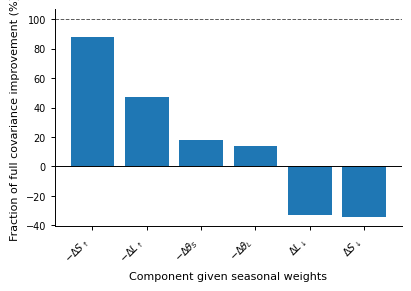

In [45]:
# ============================================================
# Plot: component-specific weighting contribution
# ============================================================

plot_df = component_effect_df.copy()

fig, ax = plt.subplots(figsize=(4.0, 2.8), constrained_layout=True)

ax.bar(
    plot_df["component_label"],
    100 * plot_df["fraction_of_full_cov_improvement"],
)

ax.axhline(0, color="black", linewidth=0.7)
ax.axhline(100, color="0.35", linewidth=0.7, linestyle="--")

ax.set_ylabel("Fraction of full covariance improvement (%)")
ax.set_xlabel("Component given seasonal weights")

plt.xticks(rotation=45, ha="right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.savefig(
    FIGDIR / f"{PROJ_EXPERIMENT}_{START_YEAR}_{END_YEAR}_component_specific_weighting_covariance.pdf",
    bbox_inches="tight",
)
fig.savefig(
    FIGDIR / f"{PROJ_EXPERIMENT}_{START_YEAR}_{END_YEAR}_component_specific_weighting_covariance.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

In [46]:
# ------------------------------------------------------------
# Return one month at a time to uniform weighting
# ------------------------------------------------------------

reverse_month_records = []

for month in range(1, 13):
    month_name = month_names[month]

    month_extra = (
        analysis_df[analysis_df["month"] == month]
        .groupby(model_cols, as_index=False)
        .agg(
            month_extra_Wm2=("extra_weighting_contribution_Wm2", "sum"),
        )
    )

    reverse = model_base.merge(
        month_extra,
        on=model_cols,
        how="inner",
    )

    # Full weighted predictor, except this month is put back to uniform.
    reverse["Q_weighted_except_month_Wm2"] = (
        reverse["Q_weighted_Wm2"]
        - reverse["month_extra_Wm2"]
    )

    y_r = reverse["mean_summer_min_sia_anom_Mkm2"]

    metrics_reverse = fit_metrics(
        reverse["Q_weighted_except_month_Wm2"],
        y_r,
    )

    cov_reverse = covariance(
        reverse["Q_weighted_except_month_Wm2"],
        y_r,
    )

    delta_weight = month_weights[month - 1] - 1/12
    delta_weight_abs = abs(delta_weight)

    reverse_month_records.append({
        "month": month,
        "month_name": month_name,
        "weight": month_weights[month - 1],
        "uniform_weight": 1/12,
        "extra_weight_vs_uniform": delta_weight,
        "delta_weight_abs": delta_weight_abs,

        "r2_uniform": metrics_uniform["r2"],
        "r2_weighted": metrics_weighted["r2"],
        "r2_weighted_except_month": metrics_reverse["r2"],

        # Negative means removing this month's weighting made R2 worse.
        "delta_r2_when_month_returned_to_uniform": (
            metrics_reverse["r2"] - metrics_weighted["r2"]
        ),

        # Positive means this month's weighting helped the full predictor.
        "r2_help_from_month_weighting": (
            metrics_weighted["r2"] - metrics_reverse["r2"]
        ),

        "rmse_weighted": metrics_weighted["rmse"],
        "rmse_weighted_except_month": metrics_reverse["rmse"],
        "delta_rmse_when_month_returned_to_uniform": (
            metrics_reverse["rmse"] - metrics_weighted["rmse"]
        ),

        "cov_uniform": cov_uniform,
        "cov_weighted": cov_weighted,
        "cov_weighted_except_month": cov_reverse,
        "delta_cov_when_month_returned_to_uniform": (
            cov_reverse - cov_weighted
        ),

        "n": metrics_reverse["n"],
    })

reverse_month_df = pd.DataFrame(reverse_month_records)

# Scale the R2 contribution by the size of the weight change
EPS = 1e-10

reverse_month_df["r2_help_per_0p01_weight_change"] = np.where(
    reverse_month_df["delta_weight_abs"] > EPS,
    0.01 * reverse_month_df["r2_help_from_month_weighting"]
    / reverse_month_df["delta_weight_abs"],
    np.nan,
)

display(
    reverse_month_df[
        [
            "month_name",
            "weight",
            "extra_weight_vs_uniform",
            "r2_weighted",
            "r2_weighted_except_month",
            "r2_help_from_month_weighting",
            "r2_help_per_0p01_weight_change",
            "delta_rmse_when_month_returned_to_uniform",
        ]
    ]
)

,month_name,weight,extra_weight_vs_uniform,r2_weighted,r2_weighted_except_month,r2_help_from_month_weighting,r2_help_per_0p01_weight_change,delta_rmse_when_month_returned_to_uniform
0,Jan,0.006113,-0.077221,0.845839,0.829691,0.016148,0.002091,0.023826
1,Feb,0.017173,-0.066160,0.845839,0.815798,0.030042,0.004541,0.043435
2,Mar,0.039883,-0.043451,0.845839,0.835043,0.010796,0.002485,0.016059
3,Apr,0.076816,-0.006518,0.845839,0.845805,0.000034,0.000053,0.000052
4,May,0.122819,0.039486,0.845839,0.846068,-0.000229,-0.000058,-0.000346
5,Jun,0.162752,0.079418,0.845839,0.821324,0.024515,0.003087,0.035727
6,Jul,0.178070,0.094737,0.845839,0.837476,0.008363,0.000883,0.012487
7,Aug,0.160079,0.076746,0.845839,0.842395,0.003444,0.000449,0.005183
8,Sep,0.117680,0.034347,0.845839,0.840575,0.005264,0.001533,0.007898
9,Oct,0.070515,-0.012819,0.845839,0.844479,0.001360,0.001061,0.002053


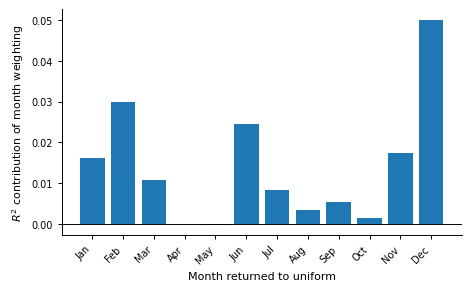

In [47]:
# ============================================================
# Plot: month contribution within the full weighted predictor
# ============================================================

plot_df = reverse_month_df.copy()

fig, ax = plt.subplots(figsize=(4.6, 2.8), constrained_layout=True)

ax.bar(
    plot_df["month_name"],
    plot_df["r2_help_from_month_weighting"],
)

ax.axhline(0, color="black", linewidth=0.7)

ax.set_ylabel(r"$R^2$ contribution of month weighting")
ax.set_xlabel("Month returned to uniform")

plt.xticks(rotation=45, ha="right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# fig.savefig(
#     FIGDIR / f"{PROJ_EXPERIMENT}_{START_YEAR}_{END_YEAR}_reverse_month_weighting_r2_help.pdf",
#     bbox_inches="tight",
# )
# fig.savefig(
#     FIGDIR / f"{PROJ_EXPERIMENT}_{START_YEAR}_{END_YEAR}_reverse_month_weighting_r2_help.png",
#     dpi=600,
#     bbox_inches="tight",
# )

plt.show()

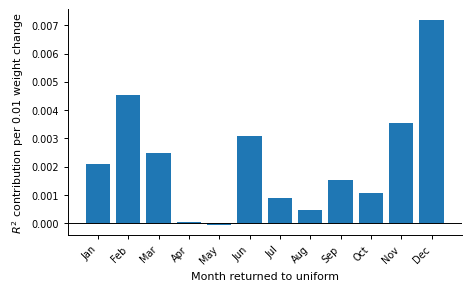

In [48]:
# ============================================================
# Plot: month contribution scaled by size of weight change
# ============================================================

fig, ax = plt.subplots(figsize=(4.6, 2.8), constrained_layout=True)

ax.bar(
    plot_df["month_name"],
    plot_df["r2_help_per_0p01_weight_change"],
)

ax.axhline(0, color="black", linewidth=0.7)

ax.set_ylabel(r"$R^2$ contribution per 0.01 weight change")
ax.set_xlabel("Month returned to uniform")

plt.xticks(rotation=45, ha="right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# fig.savefig(
#     FIGDIR / f"{PROJ_EXPERIMENT}_{START_YEAR}_{END_YEAR}_reverse_month_weighting_r2_help_scaled.pdf",
#     bbox_inches="tight",
# )
# fig.savefig(
#     FIGDIR / f"{PROJ_EXPERIMENT}_{START_YEAR}_{END_YEAR}_reverse_month_weighting_r2_help_scaled.png",
#     dpi=600,
#     bbox_inches="tight",
# )

plt.show()

In [49]:

# One row per model × component × month
term_df = (
    analysis_df
    .groupby(
        model_cols + ["component", "component_label", "month", "month_name"],
        as_index=False
    )
    .agg(
        weighted_term_Wm2=("weighted_contribution_Wm2", "sum"),
        uniform_term_Wm2=("uniform_contribution_Wm2", "sum"),
        component_anom_Wm2=("component_anom_Wm2", "mean"),
    )
)

# Model-level total weighted energy
model_qstar = (
    term_df
    .groupby(model_cols, as_index=False)
    .agg(
        Qstar_ann_Wm2=("weighted_term_Wm2", "sum"),
    )
)

qstar_mean = model_qstar["Qstar_ann_Wm2"].mean()

model_qstar["Qstar_departure_Wm2"] = (
    model_qstar["Qstar_ann_Wm2"] - qstar_mean
)

# Add model-level Qstar back to each term
term_df = term_df.merge(
    model_qstar,
    on=model_cols,
    how="left",
)

# Term departure from ensemble-mean term
term_df["term_mean_Wm2"] = (
    term_df
    .groupby(["component", "month"])["weighted_term_Wm2"]
    .transform("mean")
)

term_df["term_departure_Wm2"] = (
    term_df["weighted_term_Wm2"] - term_df["term_mean_Wm2"]
)

# Sanity check:
# For each model, sum of term departures should equal Qstar departure.
check = (
    term_df
    .groupby(model_cols, as_index=False)
    .agg(
        sum_term_departures_Wm2=("term_departure_Wm2", "sum"),
        Qstar_departure_Wm2=("Qstar_departure_Wm2", "first"),
    )
)

check["difference"] = (
    check["sum_term_departures_Wm2"] - check["Qstar_departure_Wm2"]
)

print("Max decomposition error:")
print(check["difference"].abs().max())

Max decomposition error:
2.6645352591003757e-15


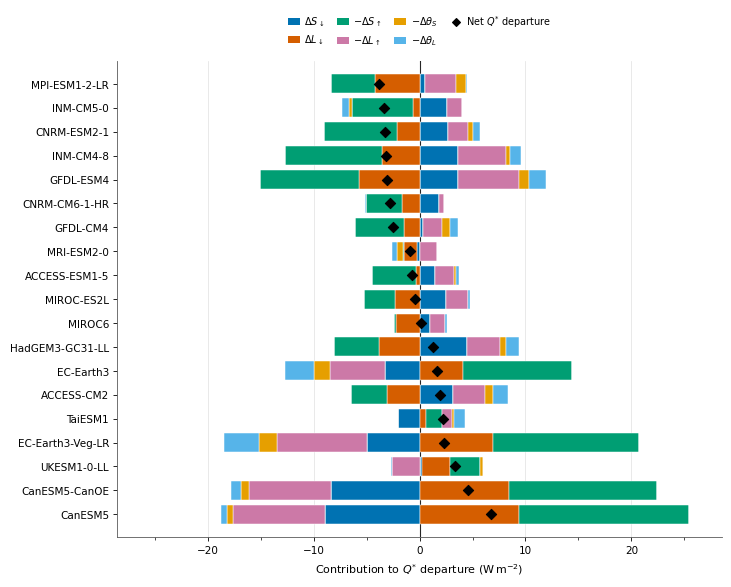

In [117]:
from matplotlib.patches import Patch
from matplotlib.ticker import AutoMinorLocator, MaxNLocator


# ============================================================
# Prepare component departures
# ============================================================

component_departures = (
    term_df
    .groupby(
        model_cols + ["component", "component_label"],
        as_index=False,
        observed=True,
    )
    .agg(
        component_departure_Wm2=("term_departure_Wm2", "sum"),
        Qstar_departure_Wm2=("Qstar_departure_Wm2", "first"),
        Qstar_ann_Wm2=("Qstar_ann_Wm2", "first"),
    )
)

component_departures["model_label"] = (
    component_departures["source"].astype(str)
)


# ============================================================
# Model and component ordering
# ============================================================

# Arrange models from the most negative to the most positive
# total Q* departure.
model_order = (
    component_departures
    .drop_duplicates("model_label")
    .sort_values("Qstar_departure_Wm2")
    ["model_label"]
    .tolist()
)

# Preserve the physically defined order in component_cols.
component_order = [
    component_labels[component]
    for component in component_cols
]


# ============================================================
# Pivot to one row per model and one column per component
# ============================================================

pivot = (
    component_departures
    .pivot_table(
        index="model_label",
        columns="component_label",
        values="component_departure_Wm2",
        aggfunc="sum",
    )
    .reindex(
        index=model_order,
        columns=component_order,
    )
    .fillna(0.0)
)

qstar_departure = (
    component_departures
    .drop_duplicates("model_label")
    .set_index("model_label")
    .reindex(model_order)
    ["Qstar_departure_Wm2"]
    .astype(float)
)


# ============================================================
# Sanity check
# ============================================================

# The component sum should normally equal the total Q* departure.
component_sum = pivot.sum(axis=1)
component_total_difference = qstar_departure - component_sum

if not np.allclose(
    component_total_difference,
    0.0,
    atol=1e-6,
    rtol=1e-5,
    equal_nan=True,
):
    largest_difference = np.nanmax(
        np.abs(component_total_difference.to_numpy())
    )

    print(
        "Warning: component contributions do not exactly sum to "
        f"Q* departure. Largest mismatch = "
        f"{largest_difference:.4f} W m-2"
    )


# ============================================================
# Publication colour palette
# ============================================================

# High-contrast, colour-blind-friendly colours.
publication_palette = [
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#009E73",  # green
    "#CC79A7",  # purple
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#8C564B",  # brown
    "#7F7F7F",  # grey
]

component_colours = {
    component: publication_palette[i % len(publication_palette)]
    for i, component in enumerate(component_order)
}


# ============================================================
# Plot
# ============================================================

n_models = len(pivot)

# Scale figure height with the number of models.
figure_height = max(3.5, 0.24 * n_models + 1.2)

publication_rcparams = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 7,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.5,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 1.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}

with plt.rc_context(publication_rcparams):

    fig, ax = plt.subplots(
        figsize=(7.2, figure_height),
        constrained_layout=True,
    )

    y_spacing = 0.78    # Control vertical spacing between bars
    y = np.arange(n_models) * y_spacing
    bar_height = 0.62  # Height of each bar

    # Separate cumulative positions are required for positive
    # and negative contributions.
    left_positive = np.zeros(n_models, dtype=float)
    left_negative = np.zeros(n_models, dtype=float)

    for component in component_order:

        values = pivot[component].to_numpy(dtype=float)

        positive = np.where(values > 0.0, values, 0.0)
        negative = np.where(values < 0.0, values, 0.0)

        colour = component_colours[component]

        ax.barh(
            y,
            positive,
            left=left_positive,
            height=bar_height,
            color=colour,
            edgecolor="white",
            linewidth=0.35,
            zorder=3,
        )

        ax.barh(
            y,
            negative,
            left=left_negative,
            height=bar_height,
            color=colour,
            edgecolor="white",
            linewidth=0.35,
            zorder=3,
        )

        left_positive += positive
        left_negative += negative

    # Net Q* departure.
    ax.scatter(
        qstar_departure.to_numpy(),
        y,
        marker="D",
        s=27,
        facecolor="black",
        edgecolor="black",
        linewidth=0.8,
        zorder=6,
        label=r"Net $Q^{*}$ departure",
    )

    # Reference line and subtle grid.
    ax.axvline(
        0.0,
        color="0.15",
        linewidth=0.8,
        zorder=2,
    )

    ax.set_axisbelow(True)

    ax.grid(
        axis="x",
        color="0.88",
        linewidth=0.5,
        zorder=0,
    )

    # Model labels.
    ax.set_yticks(y)
    ax.set_yticklabels(pivot.index)

    # Put the most negative departure at the top and the most
    # positive at the bottom.
    ax.invert_yaxis()

    ax.set_xlabel(
        r"Contribution to $Q^{*}$ departure "
        r"($\mathrm{W\,m^{-2}}$)"
    )

    ax.set_ylabel("")

    # Symmetric limits around zero make the signs directly comparable.
    plotted_extents = np.concatenate(
        [
            left_positive,
            left_negative,
            qstar_departure.to_numpy(dtype=float),
        ]
    )

    finite_extents = plotted_extents[np.isfinite(plotted_extents)]

    if finite_extents.size:
        limit = np.max(np.abs(finite_extents))
    else:
        limit = 1.0

    if limit == 0:
        limit = 1.0

    ax.set_xlim(-1.12 * limit, 1.12 * limit)

    ax.xaxis.set_major_locator(
        MaxNLocator(
            nbins=7,
            symmetric=True,
        )
    )

    ax.xaxis.set_minor_locator(
        AutoMinorLocator(2)
    )

    # Minimal framing.
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("0.35")
    ax.spines["bottom"].set_color("0.35")

    ax.tick_params(
        axis="both",
        which="both",
        direction="out",
        pad=3,
    )

    ax.margins(y=0.03)


    # ========================================================
    # Legend
    # ========================================================

    component_handles = [
        Patch(
            facecolor=component_colours[component],
            edgecolor="none",
            label=component,
        )
        for component in component_order
    ]

    total_handle = Line2D(
        [0],
        [0],
        marker="D",
        linestyle="none",
        markerfacecolor="black",
        markeredgecolor="black",
        markeredgewidth=0.8,
        markersize=4.5,
        label=r"Net $Q^{*}$ departure",
    )

    legend_handles = component_handles + [total_handle]

    ax.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=min(4, len(legend_handles)),
        frameon=False,
        handlelength=1.25,
        handletextpad=0.45,
        columnspacing=1.25,
        borderaxespad=0.0,
    )


    # ========================================================
    # Save
    # ========================================================

    # fig.savefig(
    #     FIGDIR
    #     / (
    #         f"{PROJ_EXPERIMENT}_{START_YEAR}_{END_YEAR}"
    #         "_Qstar_model_departure_by_component.pdf"
    #     ),
    #     bbox_inches="tight",
    #     facecolor="white",
    # )

    # fig.savefig(
    #     FIGDIR
    #     / (
    #         f"{PROJ_EXPERIMENT}_{START_YEAR}_{END_YEAR}"
    #         "_Qstar_model_departure_by_component.png"
    #     ),
    #     dpi=600,
    #     bbox_inches="tight",
    #     facecolor="white",
    # )

    plt.show()

In [123]:
# For component_departures, order models by total of all positive component_departure_Wm2
# and then by total of all negative component_departure_Wm2, so that the models with the largest departures are at the top and the smallest at the bottom

component_order = (
    component_departures
    .assign(
        positive_departure=lambda df:
            df["component_departure_Wm2"].clip(lower=0)
    )
    .groupby("model_label")["positive_departure"]
    .sum()
    .sort_values(ascending=False)
    .index
    .to_list()
)

for model in component_order:
    print(model)



CanESM5
CanESM5-CanOE
EC-Earth3-Veg-LR
EC-Earth3
GFDL-ESM4
INM-CM4-8
HadGEM3-GC31-LL
ACCESS-CM2
UKESM1-0-LL
CNRM-ESM2-1
MIROC-ES2L
MPI-ESM1-2-LR
TaiESM1
INM-CM5-0
ACCESS-ESM1-5
GFDL-CM4
MIROC6
CNRM-CM6-1-HR
MRI-ESM2-0


In [ ]:
summary_df = component_departures.copy()

summary_df["abs_component_departure_Wm2"] = (
    summary_df["component_departure_Wm2"].abs()
)

summary_df["component_departure_squared"] = (
    summary_df["component_departure_Wm2"] ** 2
)

# Total absolute stacked magnitude across all models and components
total_abs_component_departure = summary_df["abs_component_departure_Wm2"].sum()

# Variance of total Q* departures across models
model_qstar_dep = (
    summary_df
    .drop_duplicates("model_label")
    .set_index("model_label")["Qstar_departure_Wm2"]
)

var_qstar_dep = covariance(model_qstar_dep, model_qstar_dep)

records = []

for comp_label, sub in summary_df.groupby("component_label"):
    x = sub["component_departure_Wm2"].to_numpy(dtype=float)
    q = sub["Qstar_departure_Wm2"].to_numpy(dtype=float)

    cov_with_total = covariance(x, q)

    if np.isfinite(var_qstar_dep) and var_qstar_dep != 0:
        variance_share_percent = 100 * cov_with_total / var_qstar_dep
    else:
        variance_share_percent = np.nan

    if total_abs_component_departure != 0:
        abs_share_percent = (
            100 * sub["abs_component_departure_Wm2"].sum()
            / total_abs_component_departure
        )
    else:
        abs_share_percent = np.nan

    corr_with_total = np.corrcoef(x, q)[0, 1] if len(x) >= 2 else np.nan

    records.append({
        "component": comp_label,
        "mean_abs_departure_Wm2": np.nanmean(np.abs(x)),
        "median_abs_departure_Wm2": np.nanmedian(np.abs(x)),
        "max_abs_departure_Wm2": np.nanmax(np.abs(x)),
        "rms_departure_Wm2": np.sqrt(np.nanmean(x**2)),
        "mean_signed_departure_Wm2": np.nanmean(x),
        "std_signed_departure_Wm2": np.nanstd(x),
        "positive_fraction": np.nanmean(x > 0),
        "negative_fraction": np.nanmean(x < 0),
        "abs_share_percent": abs_share_percent,
        "cov_with_total_Qstar": cov_with_total,
        "variance_share_percent": variance_share_percent,
        "corr_with_total_Qstar": corr_with_total,
        "n_models": len(sub),
    })

component_summary = pd.DataFrame(records)

component_summary = component_summary.sort_values(
    "mean_abs_departure_Wm2",
    ascending=False,
)

display(component_summary)

In [52]:
print("Component contribution summary:")
print()

for _, row in component_summary.iterrows():
    print(
        f"{row['component']:>12s} | "
        f"mean |departure| = {row['mean_abs_departure_Wm2']:6.2f} W m-2 | "
        f"abs share = {row['abs_share_percent']:5.1f}% | "
        f"variance share = {row['variance_share_percent']:6.1f}% | "
        f"corr with total Q* = {row['corr_with_total_Qstar']:5.2f}"
    )

Component contribution summary:

$-\Delta S_{\uparrow}$ | mean |departure| =   6.15 W m-2 | abs share =  35.3% | variance share =  215.2% | corr with total Q* =  0.84
$-\Delta L_{\uparrow}$ | mean |departure| =   3.45 W m-2 | abs share =  19.8% | variance share = -108.2% | corr with total Q* = -0.76
$\Delta L_{\downarrow}$ | mean |departure| =   3.39 W m-2 | abs share =  19.5% | variance share =  111.8% | corr with total Q* =  0.79
$\Delta S_{\downarrow}$ | mean |departure| =   2.94 W m-2 | abs share =  16.9% | variance share =  -93.3% | corr with total Q* = -0.74
$-\Delta \theta_{L}$ | mean |departure| =   0.90 W m-2 | abs share =   5.2% | variance share =  -13.5% | corr with total Q* = -0.32
$-\Delta \theta_{S}$ | mean |departure| =   0.58 W m-2 | abs share =   3.4% | variance share =  -12.0% | corr with total Q* = -0.49


In [53]:
# ============================================================
# Figure: component × month attribution of inter-model Q* spread
# ============================================================



qstar = (
    term_df
    .drop_duplicates(model_cols)
    .set_index(model_cols)["Qstar_ann_Wm2"]
)

var_qstar = covariance(qstar, qstar)

spread_records = []

for (component, component_label, month, month_name), sub in term_df.groupby(
    ["component", "component_label", "month", "month_name"]
):
    tmp = (
        sub
        .set_index(model_cols)
        .join(qstar.rename("Qstar_ann_Wm2_total"))
        .reset_index()
    )

    cov_term_qstar = covariance(
        tmp["weighted_term_Wm2"],
        tmp["Qstar_ann_Wm2_total"],
    )

    percent_variance = 100 * cov_term_qstar / var_qstar if var_qstar != 0 else np.nan

    spread_records.append({
        "component": component,
        "component_label": component_label,
        "month": month,
        "month_name": month_name,
        "cov_term_qstar": cov_term_qstar,
        "percent_qstar_variance": percent_variance,
    })

spread_df = pd.DataFrame(spread_records)

spread_pivot = (
    spread_df
    .pivot(
        index="component_label",
        columns="month",
        values="percent_qstar_variance",
    )
    .reindex(index=component_order)
)

display(spread_pivot)

month,1,2,3,4,5,6,7,8,9,10,11,12
component_label,,,,,,,,,,,,
$\Delta S_{\downarrow}$,-0.000654,-0.060534,-0.700339,-4.952718,-19.845700,-27.800570,-18.674328,-11.213884,-8.520414,-1.428336,-0.063745,-0.005479
$\Delta L_{\downarrow}$,0.794252,2.539935,4.869946,9.099244,14.616173,8.215371,6.915513,11.283028,23.051634,18.739642,8.901016,2.775209
$-\Delta S_{\uparrow}$,0.002666,0.072854,0.965950,6.684759,26.742688,65.623407,67.269026,33.412911,12.481971,1.807746,0.107080,0.006364
$-\Delta L_{\uparrow}$,-1.173123,-3.198660,-6.189136,-9.013320,-9.430299,-5.732480,-8.313084,-12.306685,-20.222620,-18.979087,-10.153469,-3.456280
$-\Delta \theta_{S}$,-0.436527,-0.501339,-1.290405,-2.016814,-1.640774,1.042175,1.253351,0.433890,-2.157701,-3.682524,-2.132561,-0.898349
$-\Delta \theta_{L}$,-0.301328,-0.516862,-1.212589,-1.920321,-1.546695,0.441577,1.349048,-0.112724,-3.232154,-3.831063,-1.883264,-0.749485


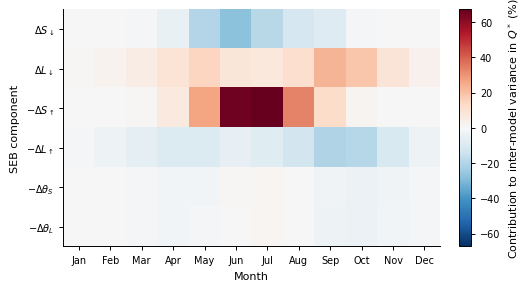

In [54]:
# ------------------------------------------------------------
# Plot heatmap
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(5.2, 2.8), constrained_layout=True)

data = spread_pivot.to_numpy(dtype=float)
vmax = np.nanmax(np.abs(data))

im = ax.imshow(
    data,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)

ax.set_xticks(np.arange(12))
ax.set_xticklabels([month_names[m] for m in range(1, 13)])

ax.set_yticks(np.arange(len(spread_pivot.index)))
ax.set_yticklabels(spread_pivot.index)

ax.set_xlabel("Month")
ax.set_ylabel("SEB component")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"Contribution to inter-model variance in $Q^*$ (%)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# fig.savefig(
#     FIGDIR / f"{PROJ_EXPERIMENT}_{START_YEAR}_{END_YEAR}_Qstar_variance_attribution_heatmap.pdf",
#     bbox_inches="tight",
# )
# fig.savefig(
#     FIGDIR / f"{PROJ_EXPERIMENT}_{START_YEAR}_{END_YEAR}_Qstar_variance_attribution_heatmap.png",
#     dpi=600,
#     bbox_inches="tight",
# )

plt.show()

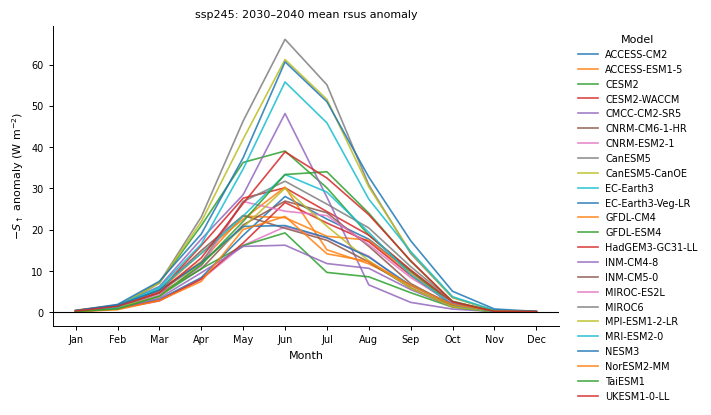

In [55]:

rsus_col = "rsus_into_surface_Wm2_anom"

rsus_df = combined_monthly_seb_anom[
    (combined_monthly_seb_anom["year"] >= START_YEAR)
    & (combined_monthly_seb_anom["year"] <= END_YEAR)
    & (~combined_monthly_seb_anom["source"].isin(EXCLUDED_MODELS))
].copy()

rsus_clim = (
    rsus_df
    .groupby(["source", "month"], as_index=False)
    .agg(rsus_anom_Wm2=(rsus_col, "mean"))
)

fig, ax = plt.subplots(figsize=(7.0, 4.0), constrained_layout=True)

for source, sub in rsus_clim.groupby("source", sort=True):
    sub = sub.sort_values("month")

    ax.plot(
        sub["month"],
        sub["rsus_anom_Wm2"],
        #marker="o",
        markersize=3,
        linewidth=1.2,
        alpha=0.85,
        label=source,
    )

ax.axhline(0, color="black", linewidth=0.8)

ax.set_xticks(range(1, 13))
ax.set_xticklabels([month_names[m] for m in range(1, 13)])

ax.set_xlabel("Month")
ax.set_ylabel(r"$-S_{\uparrow}$ anomaly (W m$^{-2}$)")
ax.set_title(f"{PROJ_EXPERIMENT}: {START_YEAR}–{END_YEAR} mean rsus anomaly")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Model",
    fontsize=7,
    title_fontsize=8,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.show()

In [56]:
# ============================================================
# rsus timing-vs-magnitude decomposition
# ============================================================
RSUS_COMPONENT = "rsus_into_surface_Wm2_anom"

rsus_df = analysis_df[
    analysis_df["component"] == RSUS_COMPONENT
].copy()

# Model-level rsus decomposition
rsus_decomp = (
    rsus_df
    .groupby(model_cols, as_index=False)
    .agg(
        rsus_uniform_Wm2=("uniform_contribution_Wm2", "sum"),
        rsus_timing_Wm2=("extra_weighting_contribution_Wm2", "sum"),
        rsus_weighted_Wm2=("weighted_contribution_Wm2", "sum"),
    )
)

# Sanity check:
# weighted = uniform + timing
rsus_decomp["check_error_Wm2"] = (
    rsus_decomp["rsus_weighted_Wm2"]
    - rsus_decomp["rsus_uniform_Wm2"]
    - rsus_decomp["rsus_timing_Wm2"]
)

print("Max rsus decomposition error:")
print(rsus_decomp["check_error_Wm2"].abs().max())

Max rsus decomposition error:
3.552713678800501e-15


In [57]:
# ============================================================
# Total weighted energy predictor
# ============================================================

qstar_total = (
    analysis_df
    .groupby(model_cols, as_index=False)
    .agg(
        Qstar_ann_Wm2=("weighted_contribution_Wm2", "sum"),
        Qann_uniform_Wm2=("uniform_contribution_Wm2", "sum"),
        mean_summer_min_sia_anom_Mkm2=("mean_summer_min_sia_anom_Mkm2", "first"),
    )
)

rsus_decomp = rsus_decomp.merge(
    qstar_total,
    on=model_cols,
    how="inner",
)

rsus_decomp["model_label"] = rsus_decomp["source"]

# Counterfactual: remove inter-model differences in rsus timing
# Equivalent to giving every model the ensemble-mean rsus timing term.
rsus_timing_mean = rsus_decomp["rsus_timing_Wm2"].mean()

rsus_decomp["Qstar_common_rsus_timing_Wm2"] = (
    rsus_decomp["Qstar_ann_Wm2"]
    - rsus_decomp["rsus_timing_Wm2"]
    + rsus_timing_mean
)

In [58]:
# ============================================================
# Summary statistics: rsus magnitude vs timing
# ============================================================

# def covariance(x, y):
#     x = np.asarray(x, dtype=float)
#     y = np.asarray(y, dtype=float)

#     valid = np.isfinite(x) & np.isfinite(y)
#     x = x[valid]
#     y = y[valid]

#     if len(x) < 2:
#         return np.nan

#     return np.mean((x - x.mean()) * (y - y.mean()))


def corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 2 or np.allclose(x, x[0]) or np.allclose(y, y[0]):
        return np.nan

    return np.corrcoef(x, y)[0, 1]


Q = rsus_decomp["Qstar_ann_Wm2"]
Q_common_timing = rsus_decomp["Qstar_common_rsus_timing_Wm2"]

M = rsus_decomp["rsus_uniform_Wm2"]
T = rsus_decomp["rsus_timing_Wm2"]
W = rsus_decomp["rsus_weighted_Wm2"]

var_Q = covariance(Q, Q)
var_W = covariance(W, W)

summary = {
    "n_models": len(rsus_decomp),

    "std_total_Qstar_Wm2": np.std(Q, ddof=0),
    "std_Qstar_common_rsus_timing_Wm2": np.std(Q_common_timing, ddof=0),
    "change_in_Qstar_std_if_rsus_timing_removed_Wm2": (
        np.std(Q_common_timing, ddof=0) - np.std(Q, ddof=0)
    ),

    "var_total_Qstar": var_Q,
    "var_Qstar_common_rsus_timing": covariance(Q_common_timing, Q_common_timing),
    "change_in_Qstar_variance_if_rsus_timing_removed": (
        covariance(Q_common_timing, Q_common_timing) - var_Q
    ),

    "cov_rsus_magnitude_with_Qstar": covariance(M, Q),
    "cov_rsus_timing_with_Qstar": covariance(T, Q),
    "cov_rsus_weighted_with_Qstar": covariance(W, Q),

    "rsus_magnitude_share_of_Qstar_variance_percent": (
        100 * covariance(M, Q) / var_Q if var_Q != 0 else np.nan
    ),
    "rsus_timing_share_of_Qstar_variance_percent": (
        100 * covariance(T, Q) / var_Q if var_Q != 0 else np.nan
    ),
    "rsus_weighted_share_of_Qstar_variance_percent": (
        100 * covariance(W, Q) / var_Q if var_Q != 0 else np.nan
    ),

    "std_rsus_magnitude_Wm2": np.std(M, ddof=0),
    "std_rsus_timing_Wm2": np.std(T, ddof=0),
    "std_rsus_weighted_Wm2": np.std(W, ddof=0),

    "corr_rsus_magnitude_with_Qstar": corr(M, Q),
    "corr_rsus_timing_with_Qstar": corr(T, Q),
    "corr_rsus_timing_with_rsus_magnitude": corr(T, M),
}

summary_df = pd.DataFrame([summary]).T
summary_df.columns = ["value"]

display(summary_df)

,value
n_models,19.000000
std_total_Qstar_Wm2,2.985089
std_Qstar_common_rsus_timing_Wm2,1.750240
change_in_Qstar_std_if_rsus_timing_removed_Wm2,-1.234849
var_total_Qstar,8.910755
var_Qstar_common_rsus_timing,3.063340
change_in_Qstar_variance_if_rsus_timing_removed,-5.847415
cov_rsus_magnitude_with_Qstar,10.831378
cov_rsus_timing_with_Qstar,8.342555
cov_rsus_weighted_with_Qstar,19.173933


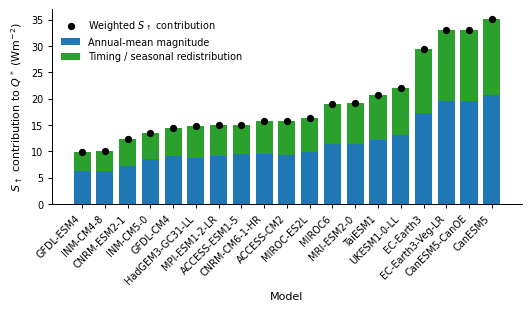

In [59]:
# ============================================================
# Plot: rsus magnitude vs timing contribution by model
# ============================================================

plot_df = rsus_decomp.copy()

plot_df = plot_df.sort_values("rsus_weighted_Wm2")

x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(5.2, 3.0), constrained_layout=True)

vals_mag = plot_df["rsus_uniform_Wm2"].to_numpy(dtype=float)
vals_timing = plot_df["rsus_timing_Wm2"].to_numpy(dtype=float)

bottom_pos = np.zeros(len(plot_df))
bottom_neg = np.zeros(len(plot_df))

for vals, label in [
    (vals_mag, "Annual-mean magnitude"),
    (vals_timing, "Timing / seasonal redistribution"),
]:
    pos = np.where(vals > 0, vals, 0)
    neg = np.where(vals < 0, vals, 0)

    ax.bar(
        x,
        pos,
        bottom=bottom_pos,
        width=0.75,
        label=label,
    )

    ax.bar(
        x,
        neg,
        bottom=bottom_neg,
        width=0.75,
    )

    bottom_pos += pos
    bottom_neg += neg

ax.scatter(
    x,
    plot_df["rsus_weighted_Wm2"],
    color="black",
    s=18,
    zorder=5,
    label=r"Weighted $S_\uparrow$ contribution",
)

ax.axhline(0, color="black", linewidth=0.7)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["model_label"], rotation=45, ha="right")

ax.set_ylabel(r"$S_\uparrow$ contribution to $Q^*$ (Wm$^{-2}$)")
ax.set_xlabel("Model")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    fontsize=7,
    loc="best",
)

plt.show()

In [60]:
# ============================================================
# rsus realistic-shape timing decomposition - doing it vs multi model mean SHAPE, rather than vs a flat uniform shape across the year
# ============================================================

rsus_df = analysis_df[
    analysis_df["component"] == RSUS_COMPONENT
].copy()

# One value per model × month
rsus_monthly = (
    rsus_df
    .groupby(model_cols + ["month", "month_name"], as_index=False)
    .agg(
        rsus_anom_Wm2=("component_anom_Wm2", "mean"),
    )
)

# Model × month matrix
rsus_matrix = (
    rsus_monthly
    .pivot_table(
        index=model_cols,
        columns="month",
        values="rsus_anom_Wm2",
    )
    .reindex(columns=range(1, 13))
)

# Drop models with incomplete monthly data
rsus_matrix = rsus_matrix.dropna()

print(f"Models in rsus timing decomposition: {len(rsus_matrix)}")

Models in rsus timing decomposition: 19


In [61]:
# ------------------------------------------------------------
# Multi-model mean seasonal shape
# ------------------------------------------------------------

g = rsus_matrix.mean(axis=0).to_numpy(dtype=float)  # realistic reference shape
w = np.asarray(month_weights, dtype=float)

assert len(g) == 12
assert len(w) == 12

g_norm2 = np.sum(g**2)

if np.isclose(g_norm2, 0):
    raise ValueError("The multi-model mean rsus seasonal shape has near-zero norm.")

# ------------------------------------------------------------
# Project each model onto the multi-model mean seasonal shape
#
# q_i = alpha_i * g + residual_i
#
# alpha_i is chosen by least squares.
# This preserves the best-fit realistic seasonal shape, not a flat annual mean.
# ------------------------------------------------------------

q = rsus_matrix.to_numpy(dtype=float)

alpha = (q @ g) / g_norm2

q_common_shape = alpha[:, None] * g[None, :]
q_residual_shape = q - q_common_shape

# Weighted rsus contributions
rsus_weighted = q @ w
rsus_common_shape_weighted = q_common_shape @ w
rsus_residual_shape_weighted = q_residual_shape @ w

# Sanity check
decomp_error = (
    rsus_weighted
    - rsus_common_shape_weighted
    - rsus_residual_shape_weighted
)

print("Max rsus weighted decomposition error:")
print(np.max(np.abs(decomp_error)))

Max rsus weighted decomposition error:
5.662137425588298e-15


In [62]:
# ============================================================
# Decomposition dataframe
# ============================================================

rsus_shape_decomp = rsus_matrix.reset_index()[model_cols].copy()

rsus_shape_decomp["source"] = rsus_shape_decomp["source"].astype(str)
rsus_shape_decomp["model_label"] = rsus_shape_decomp["source"]

rsus_shape_decomp["rsus_weighted_Wm2"] = rsus_weighted
rsus_shape_decomp["rsus_common_shape_weighted_Wm2"] = rsus_common_shape_weighted
rsus_shape_decomp["rsus_residual_shape_weighted_Wm2"] = rsus_residual_shape_weighted
rsus_shape_decomp["rsus_shape_alpha"] = alpha

# Add total Q*
qstar_total = (
    analysis_df
    .groupby(model_cols, as_index=False)
    .agg(
        Qstar_ann_Wm2=("weighted_contribution_Wm2", "sum"),
        mean_summer_min_sia_anom_Mkm2=("mean_summer_min_sia_anom_Mkm2", "first"),
    )
)

rsus_shape_decomp = rsus_shape_decomp.merge(
    qstar_total,
    on=model_cols,
    how="inner",
)

# Counterfactual total Q* if all models had the common rsus seasonal shape,
# but retained their best-fit rsus amplitude alpha_i.
rsus_shape_decomp["Qstar_common_rsus_shape_Wm2"] = (
    rsus_shape_decomp["Qstar_ann_Wm2"]
    - rsus_shape_decomp["rsus_weighted_Wm2"]
    + rsus_shape_decomp["rsus_common_shape_weighted_Wm2"]
)

display(rsus_shape_decomp)

,institution,source,member,experiment,model_label,rsus_weighted_Wm2,rsus_common_shape_weighted_Wm2,rsus_residual_shape_weighted_Wm2,rsus_shape_alpha,Qstar_ann_Wm2,mean_summer_min_sia_anom_Mkm2,Qstar_common_rsus_shape_Wm2
0,AS-RCEC,TaiESM1,r1i1p1f1,ssp245,TaiESM1,20.733003,20.139974,0.593029,1.049339,10.574243,-4.016677,9.981214
1,CCCma,CanESM5,r1i1p1f1,ssp245,CanESM5,35.226471,35.785614,-0.559142,1.864513,15.134306,-5.711618,15.693448
2,CCCma,CanESM5-CanOE,r1i1p2f1,ssp245,CanESM5-CanOE,33.133958,33.427797,-0.293839,1.741666,12.987528,-5.265364,13.281367
3,CNRM-CERFACS,CNRM-CM6-1-HR,r1i1p1f2,ssp245,CNRM-CM6-1-HR,15.777321,15.786437,-0.009116,0.822510,5.538598,-2.714818,5.547713
4,CNRM-CERFACS,CNRM-ESM2-1,r1i1p1f2,ssp245,CNRM-ESM2-1,12.265134,12.180246,0.084888,0.634619,5.085177,-2.484600,5.000289
5,CSIRO,ACCESS-ESM1-5,r1i1p1f1,ssp245,ACCESS-ESM1-5,15.107028,14.841533,0.265495,0.773278,7.616753,-3.515747,7.351258
6,CSIRO-ARCCSS,ACCESS-CM2,r1i1p1f1,ssp245,ACCESS-CM2,15.801687,15.540859,0.260828,0.809715,10.333852,-4.286864,10.073024
7,EC-Earth-Consortium,EC-Earth3,r1i1p1f1,ssp245,EC-Earth3,29.453070,29.528058,-0.074988,1.538480,10.052732,-4.512769,10.127719
8,EC-Earth-Consortium,EC-Earth3-Veg-LR,r1i1p1f1,ssp245,EC-Earth3-Veg-LR,33.010350,32.775270,0.235080,1.707668,10.644688,-4.246740,10.409608
9,INM,INM-CM4-8,r1i1p1f1,ssp245,INM-CM4-8,10.046324,10.016812,0.029512,0.521899,5.187023,-1.500575,5.157510


In [63]:
# ============================================================
# Summary statistics
# ============================================================


def corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 2 or np.allclose(x, x[0]) or np.allclose(y, y[0]):
        return np.nan

    return np.corrcoef(x, y)[0, 1]


Q = rsus_shape_decomp["Qstar_ann_Wm2"]
Q_common = rsus_shape_decomp["Qstar_common_rsus_shape_Wm2"]

R_total = rsus_shape_decomp["rsus_weighted_Wm2"]
R_common = rsus_shape_decomp["rsus_common_shape_weighted_Wm2"]
R_shape = rsus_shape_decomp["rsus_residual_shape_weighted_Wm2"]

var_Q = covariance(Q, Q)
var_R_total = covariance(R_total, R_total)

summary = {
    "n_models": len(rsus_shape_decomp),

    # Spread in the rsus weighted term itself
    "std_rsus_weighted_Wm2": np.std(R_total, ddof=0),
    "std_rsus_common_shape_Wm2": np.std(R_common, ddof=0),
    "std_rsus_residual_shape_Wm2": np.std(R_shape, ddof=0),

    # Additive variance attribution within rsus weighted contribution
    "rsus_common_shape_share_of_rsus_variance_percent": (
        100 * covariance(R_common, R_total) / var_R_total
        if var_R_total != 0 else np.nan
    ),
    "rsus_residual_shape_share_of_rsus_variance_percent": (
        100 * covariance(R_shape, R_total) / var_R_total
        if var_R_total != 0 else np.nan
    ),

    # Contribution to total Q* variance
    "rsus_common_shape_share_of_total_Qstar_variance_percent": (
        100 * covariance(R_common, Q) / var_Q
        if var_Q != 0 else np.nan
    ),
    "rsus_residual_shape_share_of_total_Qstar_variance_percent": (
        100 * covariance(R_shape, Q) / var_Q
        if var_Q != 0 else np.nan
    ),

    # Counterfactual effect on total Q* spread
    "std_total_Qstar_Wm2": np.std(Q, ddof=0),
    "std_Qstar_with_common_rsus_shape_Wm2": np.std(Q_common, ddof=0),
    "change_in_Qstar_std_if_rsus_shape_differences_removed_Wm2": (
        np.std(Q_common, ddof=0) - np.std(Q, ddof=0)
    ),

    "var_total_Qstar": var_Q,
    "var_Qstar_with_common_rsus_shape": covariance(Q_common, Q_common),
    "change_in_Qstar_variance_if_rsus_shape_differences_removed": (
        covariance(Q_common, Q_common) - var_Q
    ),

    # Correlations
    "corr_rsus_common_shape_with_Qstar": corr(R_common, Q),
    "corr_rsus_residual_shape_with_Qstar": corr(R_shape, Q),
    "corr_rsus_common_shape_with_residual_shape": corr(R_common, R_shape),
}

summary_df = pd.DataFrame([summary]).T
summary_df.columns = ["value"]

display(summary_df)

,value
n_models,19.000000
std_rsus_weighted_Wm2,7.666578
std_rsus_common_shape_Wm2,7.710722
std_rsus_residual_shape_Wm2,0.293882
rsus_common_shape_share_of_rsus_variance_percent,100.503987
rsus_residual_shape_share_of_rsus_variance_percent,-0.503987
rsus_common_shape_share_of_total_Qstar_variance_percent,214.100131
rsus_residual_shape_share_of_total_Qstar_variance_percent,1.077290
std_total_Qstar_Wm2,2.985089
std_Qstar_with_common_rsus_shape_Wm2,2.967344


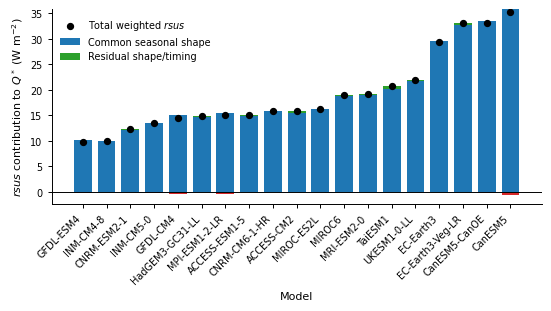

In [64]:
# ============================================================
# Plot: rsus weighted contribution split into common-shape and residual-shape terms
# ============================================================

plot_df = rsus_shape_decomp.copy()
plot_df = plot_df.sort_values("rsus_weighted_Wm2")

x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(5.4, 3.0), constrained_layout=True)

terms = [
    ("rsus_common_shape_weighted_Wm2", "Common seasonal shape"),
    ("rsus_residual_shape_weighted_Wm2", "Residual shape/timing"),
]

bottom_pos = np.zeros(len(plot_df))
bottom_neg = np.zeros(len(plot_df))

for col, label in terms:
    vals = plot_df[col].to_numpy(dtype=float)

    pos = np.where(vals > 0, vals, 0)
    neg = np.where(vals < 0, vals, 0)

    ax.bar(
        x,
        pos,
        bottom=bottom_pos,
        width=0.75,
        label=label,
    )

    ax.bar(
        x,
        neg,
        bottom=bottom_neg,
        width=0.75,
    )

    bottom_pos += pos
    bottom_neg += neg

ax.scatter(
    x,
    plot_df["rsus_weighted_Wm2"],
    color="black",
    s=18,
    zorder=5,
    label=r"Total weighted $rsus$",
)

ax.axhline(0, color="black", linewidth=0.7)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["model_label"], rotation=45, ha="right")

ax.set_ylabel(r"$rsus$ contribution to $Q^*$ (W m$^{-2}$)")
ax.set_xlabel("Model")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    fontsize=7,
    loc="best",
)

plt.show()

In [65]:
# ============================================================
# Function: monthly climatology for any SEB component or total SEB
# ============================================================

def get_model_clim(
    df,
    component,
    model="MMM",
    start_year=None,
    end_year=None,
    experiment=None,
    member=None,
    require_all_months=True,
    return_series=False,
):
    """
    Return Jan-Dec climatology of a SEB component anomaly for one model or the MMM.

    Parameters
    ----------
    df : pandas.DataFrame
        Usually combined_monthly_seb_anom.

    component : str
        One of:
            "rsds", "rlds", "rsus", "rlus", "hfss", "hfls",
            "total", "seb"

        Or the exact dataframe column name, e.g.
            "rsus_into_surface_Wm2_anom"

        Sign convention follows the dataframe:
            positive = into the surface.

    model : str, default "MMM"
        Model source name, e.g. "ACCESS-ESM1-5", or "MMM" / "multimodel mean".

    start_year, end_year : int or None
        Optional inclusive year range.

    experiment : str or None
        Optional experiment filter, e.g. "ssp370".

    member : str or None
        Optional member filter, e.g. "r1i1p1f1".

    require_all_months : bool
        If True, raise an error if the output does not contain all 12 months.

    return_series : bool
        If False, return a numpy array of length 12.
        If True, return a pandas Series indexed by month.

    Returns
    -------
    numpy.ndarray or pandas.Series
        Monthly climatology, Jan-Dec.
    """

    component_aliases = {
        "rsds": "rsds_into_surface_Wm2_anom",
        "rlds": "rlds_into_surface_Wm2_anom",
        "rsus": "rsus_into_surface_Wm2_anom",
        "rlus": "rlus_into_surface_Wm2_anom",
        "hfss": "hfss_into_surface_Wm2_anom",
        "hfls": "hfls_into_surface_Wm2_anom",
        "seb": "seb_anom_Wm2",
        "total": "seb_anom_Wm2",
        "total_seb": "seb_anom_Wm2",
    }

    component_key = component.lower()

    if component_key in component_aliases:
        col = component_aliases[component_key]
    else:
        col = component

    data = df.copy()

    if start_year is not None:
        data = data[data["year"] >= start_year]

    if end_year is not None:
        data = data[data["year"] <= end_year]

    if experiment is not None:
        data = data[data["experiment"] == experiment]

    if member is not None:
        data = data[data["member"] == member]

    # If total SEB column is missing, reconstruct it from the component columns.
    if col == "seb_anom_Wm2" and col not in data.columns:
        component_cols = [
            "rsds_into_surface_Wm2_anom",
            "rlds_into_surface_Wm2_anom",
            "rsus_into_surface_Wm2_anom",
            "rlus_into_surface_Wm2_anom",
            "hfss_into_surface_Wm2_anom",
            "hfls_into_surface_Wm2_anom",
        ]

        missing = [c for c in component_cols if c not in data.columns]

        if missing:
            raise ValueError(
                "Cannot reconstruct total SEB because these columns are missing: "
                + ", ".join(missing)
            )

        data = data.copy()
        data["seb_anom_Wm2"] = data[component_cols].sum(axis=1)

    if col not in data.columns:
        raise ValueError(
            f"Column {col!r} not found. Available anomaly columns include:\n"
            + "\n".join([c for c in data.columns if c.endswith("_anom") or c.endswith("_anom_Wm2")])
        )

    mmm_names = {"mmm", "multi-model mean", "multimodel mean", "multi_model_mean"}

    if str(model).lower() in mmm_names:
        # First calculate one climatology per model, then average models.
        # This avoids giving extra weight to models with more rows.
        possible_model_cols = ["institution", "source", "member", "grid", "experiment"]
        model_cols = [c for c in possible_model_cols if c in data.columns]

        model_monthly = (
            data
            .groupby(model_cols + ["month"], as_index=False)
            .agg(value=(col, "mean"))
        )

        clim = (
            model_monthly
            .groupby("month")["value"]
            .mean()
            .reindex(range(1, 13))
        )

    else:
        if "source" not in data.columns:
            raise ValueError("Cannot select a model because column 'source' is missing.")

        data = data[data["source"] == model]

        if data.empty:
            available = sorted(df["source"].dropna().unique())
            raise ValueError(
                f"No rows found for model {model!r}. Available models include:\n"
                + "\n".join(available)
            )

        clim = (
            data
            .groupby("month")[col]
            .mean()
            .reindex(range(1, 13))
        )

    if require_all_months and clim.isna().any():
        missing_months = list(clim[clim.isna()].index)
        raise ValueError(
            f"Missing climatology values for months: {missing_months}"
        )

    if return_series:
        return clim

    return clim.to_numpy(dtype=float)

Model TaiESM1: energy-weighted mean month = 6.84, September SIA anomaly = -4.028 Mkm²
Model FGOALS-g3 is excluded from analysis.
Model CanESM5: energy-weighted mean month = 6.50, September SIA anomaly = -5.962 Mkm²
Model CanESM5-CanOE: energy-weighted mean month = 6.49, September SIA anomaly = -5.514 Mkm²
Model CNRM-CM6-1-HR: energy-weighted mean month = 6.35, September SIA anomaly = -2.715 Mkm²
Model CNRM-ESM2-1: energy-weighted mean month = 6.45, September SIA anomaly = -2.485 Mkm²
Model ACCESS-ESM1-5: energy-weighted mean month = 6.60, September SIA anomaly = -3.518 Mkm²
Model ACCESS-CM2: energy-weighted mean month = 6.75, September SIA anomaly = -4.475 Mkm²
Model EC-Earth3: energy-weighted mean month = 6.36, September SIA anomaly = -5.258 Mkm²
Model EC-Earth3-Veg-LR: energy-weighted mean month = 6.41, September SIA anomaly = -4.947 Mkm²
Model INM-CM4-8: energy-weighted mean month = 6.35, September SIA anomaly = -1.561 Mkm²
Model INM-CM5-0: energy-weighted mean month = 6.12, Septemb

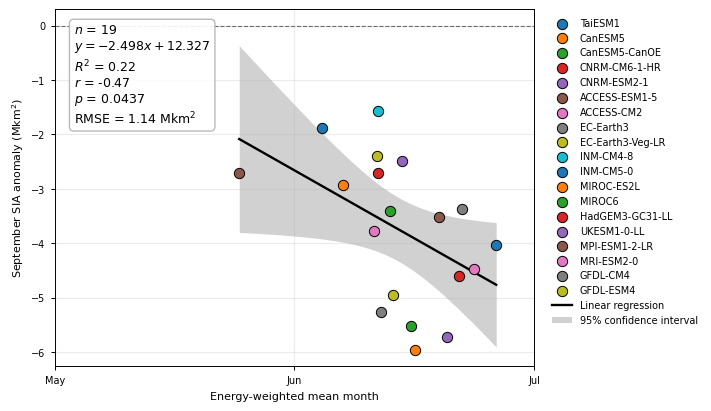

In [66]:
def weighted_mean_month(monthly_values, positive_only=True):
    """
    Return circular weighted mean month on 1-12 scale.
    
    Example:
    Jun=5, Aug=5 -> 7
    Dec=5, Feb=5 -> 1
    """
    values = np.asarray(monthly_values, dtype=float)

    if positive_only:
        weights = np.clip(values, 0, None)
    else:
        weights = values.copy()

    if np.all(weights == 0) or np.isclose(np.sum(weights), 0):
        return np.nan

    months = np.arange(1, 13)

    # Convert month numbers to angles: Jan=0, Feb=30deg, ..., Dec=330deg
    angles = 2 * np.pi * (months - 1) / 12

    x = np.sum(weights * np.cos(angles))
    y = np.sum(weights * np.sin(angles))

    mean_angle = np.arctan2(y, x)

    # Convert back to month number in range 1-12
    mean_month = (mean_angle / (2 * np.pi) * 12) + 1

    # Wrap into 1-12
    mean_month = ((mean_month - 1) % 12) + 1

    return mean_month

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

mean_month_list = []
min_sia_list = []
model_list = []

for model in models_to_use:
    if model in EXCLUDED_MODELS:
        print(f"Model {model} is excluded from analysis.")
        continue

    try:
        clim = get_model_clim(
            combined_monthly_seb_anom,
            component="total",
            model=model,
            start_year=START_YEAR,
            end_year=END_YEAR,
            require_all_months=True,
        )

        sia_clim = get_model_clim(
            combined_monthly_sia_anom,
            component="sia_anom_Mkm2",
            model=model,
            start_year=START_YEAR,
            end_year=END_YEAR,
        )

        min_sia = sia_clim[8]  # September, if Jan=0
        mean_month = weighted_mean_month(clim)

        mean_month_list.append(mean_month)
        min_sia_list.append(min_sia)
        model_list.append(model)

        print(
            f"Model {model}: energy-weighted mean month = {mean_month:.2f}, "
            f"September SIA anomaly = {min_sia:.3f} Mkm²"
        )

    except ValueError as e:
        print(f"Model {model}: Error - {e}")
        continue


# ------------------------------------------------------------
# Convert to arrays and remove NaNs
# ------------------------------------------------------------
x = np.asarray(mean_month_list, dtype=float)
y = np.asarray(min_sia_list, dtype=float)
model_arr = np.asarray(model_list)

valid = np.isfinite(x) & np.isfinite(y)

x = x[valid]
y = y[valid]
model_arr = model_arr[valid]

# ------------------------------------------------------------
# Linear regression
# ------------------------------------------------------------
reg = stats.linregress(x, y)

slope = reg.slope
intercept = reg.intercept
r = reg.rvalue
r2 = r**2
p = reg.pvalue
stderr = reg.stderr

y_pred = intercept + slope * x
rmse = np.sqrt(np.mean((y - y_pred)**2))

# Line for plotting
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = intercept + slope * x_fit

# Optional 95% confidence interval around regression line
n = len(x)
x_mean = np.mean(x)
s_err = np.sqrt(np.sum((y - y_pred)**2) / (n - 2))

t_val = stats.t.ppf(0.975, df=n - 2)
conf = t_val * s_err * np.sqrt(
    1 / n + (x_fit - x_mean)**2 / np.sum((x - x_mean)**2)
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
x = np.asarray(mean_month_list, dtype=float)
y = np.asarray(min_sia_list, dtype=float)
model_arr = np.asarray(model_list)

valid = np.isfinite(x) & np.isfinite(y)

x = x[valid]
y = y[valid]
model_arr = model_arr[valid]

# ------------------------------------------------------------
# Linear regression
# ------------------------------------------------------------
reg = stats.linregress(x, y)

slope = reg.slope
intercept = reg.intercept
r = reg.rvalue
r2 = r**2
p = reg.pvalue
stderr = reg.stderr

y_pred = intercept + slope * x
rmse = np.sqrt(np.mean((y - y_pred) ** 2))

# Regression line
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = intercept + slope * x_fit

# 95% confidence interval
n = len(x)
x_mean = np.mean(x)

s_err = np.sqrt(np.sum((y - y_pred) ** 2) / (n - 2))
t_val = stats.t.ppf(0.975, df=n - 2)

conf = t_val * s_err * np.sqrt(
    1 / n + (x_fit - x_mean) ** 2 / np.sum((x - x_mean) ** 2)
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.0), constrained_layout=True)

# Plot each model separately so it appears in the legend
for xi, yi, model in zip(x, y, model_arr):
    ax.scatter(
        xi,
        yi,
        s=55,
        edgecolor="black",
        linewidth=0.7,
        label=model,
        zorder=3,
    )

ax.plot(
    x_fit,
    y_fit,
    linewidth=1.7,
    color="black",
    label="Linear regression",
    zorder=2,
)

ax.fill_between(
    x_fit,
    y_fit - conf,
    y_fit + conf,
    alpha=0.18,
    color="black",
    linewidth=0,
    label="95% confidence interval",
    zorder=1,
)

ax.axhline(
    0,
    color="0.35",
    linewidth=0.8,
    linestyle="--",
    zorder=0,
)

# ------------------------------------------------------------
# Stats box
# ------------------------------------------------------------
stats_text = (
    f"$n$ = {n}\n"
    f"$y = {slope:.3f}x {intercept:+.3f}$\n"
    f"$R^2$ = {r2:.2f}\n"
    f"$r$ = {r:.2f}\n"
    f"$p$ = {p:.3g}\n"
    f"RMSE = {rmse:.2f} Mkm$^2$"
)

ax.text(
    0.04,
    0.96,
    stats_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="0.7",
        alpha=0.9,
    ),
)

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------
month_labels = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec",
}

# Zoom x-axis around data rather than showing whole year
x_pad = 0
x_min = max(1, np.floor(x.min()) - x_pad)
x_max = min(12, np.ceil(x.max()) + x_pad)

ax.set_xlim(x_min, x_max)

xticks = np.arange(np.floor(x_min), np.ceil(x_max) + 1).astype(int)
xticks = xticks[(xticks >= 1) & (xticks <= 12)]

ax.set_xticks(xticks)
ax.set_xticklabels([month_labels[m] for m in xticks])

ax.set_xlabel("Energy-weighted mean month")
ax.set_ylabel("September SIA anomaly (Mkm$^2$)")

ax.grid(alpha=0.25)

# Legend outside plot
ax.legend(
    fontsize=7,
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.show()


In [67]:
from scipy.interpolate import CubicSpline


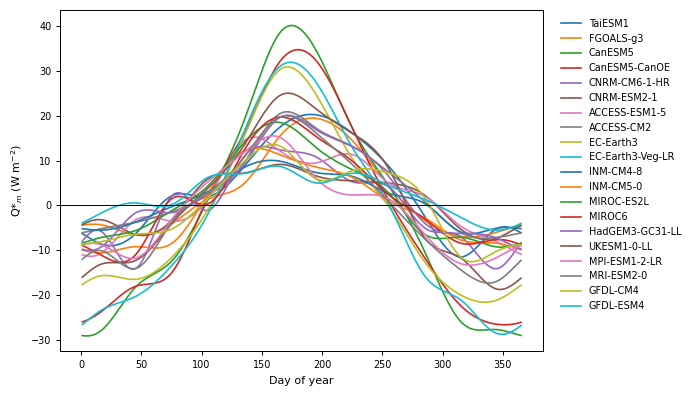

In [68]:

# Month lengths for a non-leap climatological year
month_lengths = np.ones(12)*30  #np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
month_starts = np.concatenate([[1], 1 + np.cumsum(month_lengths[:-1])])

# Midpoint day of each month
month_midpoints = month_starts + (month_lengths - 1) / 2

day_numbers = np.arange(1, 366)

plt.figure(figsize=(7, 4))

peak_dict = {}

for model in models_to_use:
    model_clim = get_model_clim(
        combined_monthly_seb_anom,
        component="total",
        model=model,
        start_year=START_YEAR,
        end_year=END_YEAR,
    )

    model_sia_clim = get_model_clim(
        combined_monthly_sia_anom,
        component="sia_anom_Mkm2",
        model=model,
        start_year=START_YEAR,
        end_year=END_YEAR,
    )

    # Periodic spline: duplicate January one year later
    x = np.concatenate([month_midpoints, [month_midpoints[0] + 365]])
    y = np.concatenate([model_clim, [model_clim[0]]])

    cs = CubicSpline(
        x,
        y,
        bc_type="periodic",
        extrapolate="periodic",
    )

    model_clim_days = cs(day_numbers)

    # plt.plot(
    #     range(1,13),#month_midpoints,
    #     model_clim, #model_clim_days,
    #     label=model,
    #     linewidth=1.2,
    # )
    plt.plot(
        day_numbers,
        model_clim_days,
        label=model,
        linewidth=1.2,
    )

    #for the same model, extract sia_anom_Mkm2 from combined_monthly_seb_anom and plot it on the same graph with a secondary y-axis
    min_sia_anom = model_sia_clim[8] #np.min(model_sia_clim)

    peak_idx = np.argmax(model_clim_days)
    peak_day = day_numbers[peak_idx]
    peak_value = model_clim_days[peak_idx]
    average_value = np.mean(model_clim)

    #print(f"Model: {model}, Peak Q*: {peak_value:.2f} W/m^2 on day {peak_day}, Min SIA: {min_sia_anom:.2f} Mkm^2")
    peak_dict[model] = {
        "peak_day": peak_day,
        "peak_value": peak_value,
        "average_value": average_value,
        "min_sia_anom": min_sia_anom,
    }
plt.axhline(0, color="black", linewidth=0.7)

plt.xlabel("Day of year")
plt.ylabel(r"Q*$_m$ (W m$^{-2}$)")

plt.legend(
    fontsize=7,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.tight_layout()
plt.show()


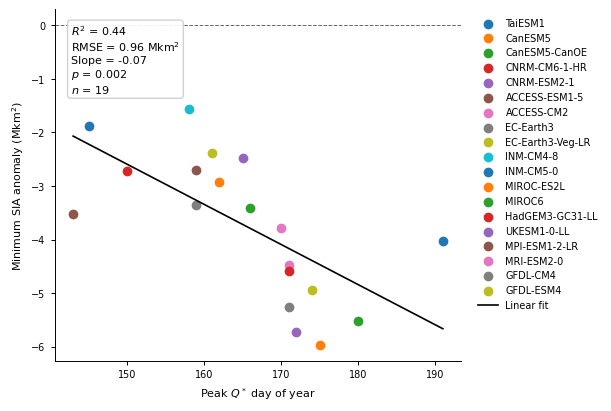

In [69]:

from scipy.stats import linregress

#####Look at creating a weighted average day of year of Q*
#####so  sum of (Q* * day_of_year) / sum of Q*  for each model, then plot that against min SIA anomaly


x_key = "peak_day"
x_label = r"Peak $Q^*$ day of year"

y_key = "min_sia_anom"
y_label = r"Minimum SIA anomaly (Mkm$^2$)"



records = []

for model, peak_info in peak_dict.items():
    if model in excluded_models:
        continue

    records.append({
        "model": model,
        "x": peak_info[x_key],
        "y": peak_info[y_key],
    })

plot_df = pd.DataFrame(records).dropna(subset=["x", "y"])


x = plot_df["x"].to_numpy(dtype=float)
y = plot_df["y"].to_numpy(dtype=float)

fit = linregress(x, y)

slope = fit.slope
intercept = fit.intercept
r_value = fit.rvalue
p_value = fit.pvalue
r2 = r_value**2

y_pred = slope * x + intercept
rmse = np.sqrt(np.mean((y - y_pred) ** 2))

# Line for plotting
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = slope * x_fit + intercept

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

for _, row in plot_df.iterrows():
    ax.scatter(
        row["x"],
        row["y"],
        label=row["model"],
    )

ax.plot(
    x_fit,
    y_fit,
    color="black",
    linewidth=1.2,
    linestyle="-",
    label="Linear fit",
)

stats_text = (
    rf"$R^2$ = {r2:.2f}" "\n"
    rf"RMSE = {rmse:.2f} Mkm$^2$" "\n"
    rf"Slope = {slope:.2f}" "\n"
    rf"$p$ = {p_value:.3f}" "\n"
    rf"$n$ = {len(plot_df)}"
)

ax.text(
    0.04,
    0.96,
    stats_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=8,
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="0.8",
        alpha=0.9,
    ),
)

ax.axhline(0, color="0.4", linewidth=0.7, linestyle="--")

ax.set_xlabel(x_label)
ax.set_ylabel(y_label)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    fontsize=7,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.show()

In [70]:
peak_dict

{'TaiESM1': {'peak_day': np.int64(191),
  'peak_value': np.float64(20.333208390299365),
  'average_value': np.float64(3.463629988274276),
  'min_sia_anom': np.float64(-4.027754918828398)},
 'FGOALS-g3': {'peak_day': np.int64(192),
  'peak_value': np.float64(19.51586717165912),
  'average_value': np.float64(2.4156831387463518),
  'min_sia_anom': np.float64(-0.17622788016051436)},
 'CanESM5': {'peak_day': np.int64(175),
  'peak_value': np.float64(40.20898004650116),
  'average_value': np.float64(-0.6732723374383166),
  'min_sia_anom': np.float64(-5.962127194795832)},
 'CanESM5-CanOE': {'peak_day': np.int64(180),
  'peak_value': np.float64(34.81513474196605),
  'average_value': np.float64(-1.409074018209738),
  'min_sia_anom': np.float64(-5.5144599889750685)},
 'CNRM-CM6-1-HR': {'peak_day': np.int64(150),
  'peak_value': np.float64(13.158251616211759),
  'average_value': np.float64(-0.11455554592947292),
  'min_sia_anom': np.float64(-2.714817677625112)},
 'CNRM-ESM2-1': {'peak_day': np.in

In [71]:
# ============================================================
# Total SEB: annual-mean magnitude vs seasonal timing/alignment
# ============================================================

model_cols = ["institution", "source", "member", "experiment"]

qstar_decomp = (
    analysis_df
    .groupby(model_cols, as_index=False)
    .agg(
        Q_uniform_Wm2=("uniform_contribution_Wm2", "sum"),
        Q_timing_Wm2=("extra_weighting_contribution_Wm2", "sum"),
        Qstar_Wm2=("weighted_contribution_Wm2", "sum"),
        mean_summer_min_sia_anom_Mkm2=("mean_summer_min_sia_anom_Mkm2", "first"),
    )
)

qstar_decomp["check_error_Wm2"] = (
    qstar_decomp["Qstar_Wm2"]
    - qstar_decomp["Q_uniform_Wm2"]
    - qstar_decomp["Q_timing_Wm2"]
)

print("Max decomposition error:")
print(qstar_decomp["check_error_Wm2"].abs().max())

qstar_decomp["model_label"] = qstar_decomp["source"]

display(
    qstar_decomp[
        [
            "model_label",
            "Q_uniform_Wm2",
            "Q_timing_Wm2",
            "Qstar_Wm2",
            "mean_summer_min_sia_anom_Mkm2",
        ]
    ].sort_values("Qstar_Wm2")
)

Max decomposition error:
1.7763568394002505e-15


,model_label,Q_uniform_Wm2,Q_timing_Wm2,Qstar_Wm2,mean_summer_min_sia_anom_Mkm2
15,MPI-ESM1-2-LR,-1.041052,5.540477,4.499425,-2.709396
10,INM-CM5-0,-0.456489,5.479784,5.023295,-1.859531
4,CNRM-ESM2-1,1.338487,3.746689,5.085177,-2.484600
9,INM-CM4-8,1.484981,3.702042,5.187023,-1.500575
18,GFDL-ESM4,2.555370,2.708015,5.263386,-2.312036
3,CNRM-CM6-1-HR,-0.114556,5.653153,5.538598,-2.714818
17,GFDL-CM4,0.473453,5.371916,5.845369,-3.206946
16,MRI-ESM2-0,-0.615021,8.072647,7.457626,-3.697362
5,ACCESS-ESM1-5,2.189028,5.427725,7.616753,-3.515747
11,MIROC-ES2L,1.964279,5.969558,7.933838,-2.398429


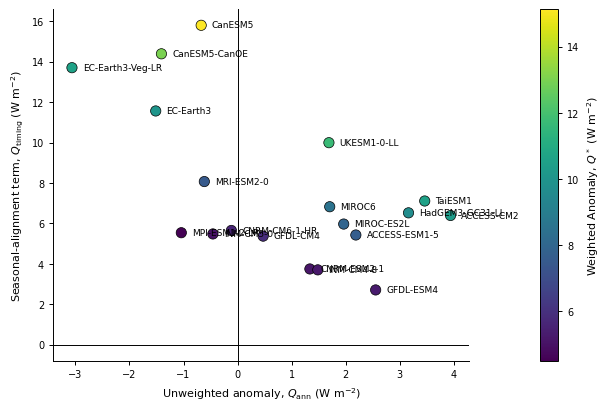

In [72]:
# ============================================================
# Plot: magnitude vs timing contribution
# ============================================================

plot_df = qstar_decomp.copy()

fig, ax = plt.subplots(figsize=(6.0, 4.0), constrained_layout=True)

sc = ax.scatter(
    plot_df["Q_uniform_Wm2"],
    plot_df["Q_timing_Wm2"],
    c=plot_df["Qstar_Wm2"],
    s=55,
    edgecolor="black",
    linewidth=0.5,
    zorder=3,
)

for _, row in plot_df.iterrows():
    ax.text(
        row["Q_uniform_Wm2"] + 0.2,
        row["Q_timing_Wm2"],
        row["model_label"],
        fontsize=6.5,
        va="center",
    )

ax.axhline(0, color="black", linewidth=0.7)
ax.axvline(0, color="black", linewidth=0.7)

ax.set_xlabel(r"Unweighted anomaly, $Q_{\mathrm{ann}}$ (W m$^{-2}$)")
ax.set_ylabel(r"Seasonal-alignment term, $Q_{\mathrm{timing}}$ (W m$^{-2}$)")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"Weighted Anomaly, $Q^*$ (W m$^{-2}$)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

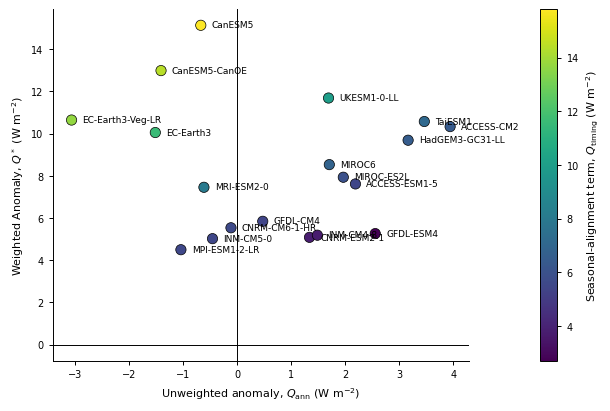

In [73]:
# ============================================================
# Plot: weighted vs unweighted anomaly, colored by timing contribution
# ============================================================

plot_df = qstar_decomp.copy()

fig, ax = plt.subplots(figsize=(6.0, 4.0), constrained_layout=True)

sc = ax.scatter(
    plot_df["Q_uniform_Wm2"],
    plot_df["Qstar_Wm2"],
    c=plot_df["Q_timing_Wm2"],
    s=55,
    edgecolor="black",
    linewidth=0.5,
    zorder=3,
)

for _, row in plot_df.iterrows():
    ax.text(
        row["Q_uniform_Wm2"] + 0.2,
        row["Qstar_Wm2"],
        row["model_label"],
        fontsize=6.5,
        va="center",
    )

ax.axhline(0, color="black", linewidth=0.7)
ax.axvline(0, color="black", linewidth=0.7)

ax.set_xlabel(r"Unweighted anomaly, $Q_{\mathrm{ann}}$ (W m$^{-2}$)")
ax.set_ylabel(r"Weighted Anomaly, $Q^*$ (W m$^{-2}$)")

cbar = fig.colorbar(sc, ax=ax)

cbar.set_label(r"Seasonal-alignment term, $Q_{\mathrm{timing}}$ (W m$^{-2}$)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

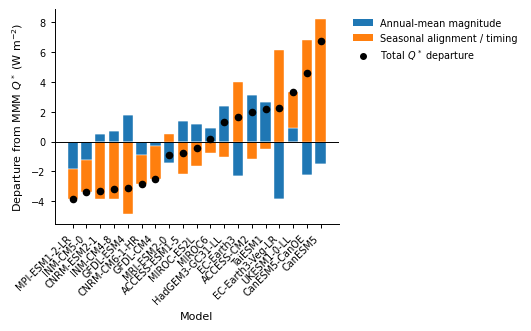

In [74]:
# ============================================================
# Plot: model Q* departure split into magnitude and timing departures
# ============================================================


plot_df = qstar_decomp.copy()

# Departures from multi-model mean
for col in ["Q_uniform_Wm2", "Q_timing_Wm2", "Qstar_Wm2"]:
    plot_df[col + "_departure"] = plot_df[col] - plot_df[col].mean()

plot_df = plot_df.sort_values("Qstar_Wm2_departure")

x = np.arange(len(plot_df))

terms = [
    ("Q_uniform_Wm2_departure", "Annual-mean magnitude"),
    ("Q_timing_Wm2_departure", "Seasonal alignment / timing"),
]

# Explicit colours: same colour whether contribution is positive or negative
term_colours = {
    "Annual-mean magnitude": plt.rcParams["axes.prop_cycle"].by_key()["color"][0],
    "Seasonal alignment / timing": plt.rcParams["axes.prop_cycle"].by_key()["color"][1],
}

fig, ax = plt.subplots(figsize=(5.2, 3.2), constrained_layout=True)

bottom_pos = np.zeros(len(plot_df))
bottom_neg = np.zeros(len(plot_df))

for col, label in terms:
    vals = plot_df[col].to_numpy(dtype=float)

    pos = np.where(vals > 0, vals, 0)
    neg = np.where(vals < 0, vals, 0)

    colour = term_colours[label]

    ax.bar(
        x,
        pos,
        bottom=bottom_pos,
        width=0.75,
        color=colour,
        edgecolor="white",
        linewidth=0.3,
    )

    ax.bar(
        x,
        neg,
        bottom=bottom_neg,
        width=0.75,
        color=colour,
        edgecolor="white",
        linewidth=0.3,
    )

    bottom_pos += pos
    bottom_neg += neg

# Overlay total Q* departure as black points
ax.scatter(
    x,
    plot_df["Qstar_Wm2_departure"],
    color="black",
    s=20,
    zorder=5,
)

ax.axhline(0, color="black", linewidth=0.7)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["model_label"], rotation=45, ha="right")

ax.set_ylabel(r"Departure from MMM $Q^*$ (W m$^{-2}$)")
ax.set_xlabel("Model")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Explicit legend
handles = [
    Patch(
        facecolor=term_colours[label],
        edgecolor="none",
        label=label,
    )
    for _, label in terms
]

handles.append(
    Line2D(
        [0],
        [0],
        marker="o",
        color="black",
        linestyle="none",
        markersize=4,
        label=r"Total $Q^*$ departure",
    )
)

ax.legend(
    handles=handles,
    frameon=False,
    fontsize=7,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
)

plt.show()

In [75]:
# ============================================================
# Magnitude vs timing decomposition
# Works for total SEB or any individual SEB component
# ============================================================



def make_magnitude_timing_decomp(
    analysis_df,
    component="total",
    excluded_models=None,
    model_cols=None,
):
    """
    Decompose weighted SEB into:
        Q* = Q_uniform + Q_timing

    where:
        Q_uniform = sum_m (1/12) Q_m
        Q_timing  = sum_m (w_m - 1/12) Q_m

    Parameters
    ----------
    analysis_df : pandas.DataFrame
        Long dataframe with rows for model × month × component.

    component : str
        "total", "seb", "all" for total SEB, or one of:
        "rsds", "rlds", "rsus", "rlus", "hfss", "hfls",
        or an exact value in analysis_df["component"].

    excluded_models : list-like or None
        Model names in the "source" column to exclude.

    model_cols : list or None
        Columns identifying a model/run.

    Returns
    -------
    decomp_df : pandas.DataFrame
        One row per model with Q_uniform, Q_timing and Qstar.

    component_label : str
        Human-readable label for plotting.
    """

    if model_cols is None:
        model_cols = ["institution", "source", "member", "experiment"]

    if excluded_models is None:
        excluded_models = []

    component_aliases = {
        "rsds": "rsds_into_surface_Wm2_anom",
        "rlds": "rlds_into_surface_Wm2_anom",
        "rsus": "rsus_into_surface_Wm2_anom",
        "rlus": "rlus_into_surface_Wm2_anom",
        "hfss": "hfss_into_surface_Wm2_anom",
        "hfls": "hfls_into_surface_Wm2_anom",
    }

    component_label_aliases = {
        "rsds": r"$S_{\downarrow}$",
        "rlds": r"$L_{\downarrow}$",
        "rsus": r"$-S_{\uparrow}$",
        "rlus": r"$-L_{\uparrow}$",
        "hfss": r"$-\mathrm{SH}$",
        "hfls": r"$-\mathrm{LH}$",
        "total": "Total SEB",
        "seb": "Total SEB",
        "all": "Total SEB",
    }

    df = analysis_df.copy()

    if excluded_models:
        df = df[~df["source"].isin(excluded_models)].copy()

    component_key = str(component).lower()

    if component_key in ["total", "seb", "all"]:
        component_label = "Total SEB"
        selected = df.copy()

    else:
        component_name = component_aliases.get(component_key, component)

        selected = df[df["component"] == component_name].copy()

        if selected.empty:
            available = sorted(df["component"].dropna().unique())
            raise ValueError(
                f"No rows found for component={component!r}.\n"
                f"Resolved component name was: {component_name!r}\n\n"
                "Available components are:\n"
                + "\n".join(available)
            )

        if "component_label" in selected.columns:
            component_label = selected["component_label"].iloc[0]
        else:
            component_label = component_label_aliases.get(component_key, component_name)

    decomp_df = (
        selected
        .groupby(model_cols, as_index=False)
        .agg(
            Q_uniform_Wm2=("uniform_contribution_Wm2", "sum"),
            Q_timing_Wm2=("extra_weighting_contribution_Wm2", "sum"),
            Qstar_Wm2=("weighted_contribution_Wm2", "sum"),
        )
    )

    if "mean_summer_min_sia_anom_Mkm2" in selected.columns:
        sia_df = (
            selected
            .groupby(model_cols, as_index=False)
            .agg(
                mean_summer_min_sia_anom_Mkm2=(
                    "mean_summer_min_sia_anom_Mkm2",
                    "first",
                )
            )
        )

        decomp_df = decomp_df.merge(
            sia_df,
            on=model_cols,
            how="left",
        )

    decomp_df["check_error_Wm2"] = (
        decomp_df["Qstar_Wm2"]
        - decomp_df["Q_uniform_Wm2"]
        - decomp_df["Q_timing_Wm2"]
    )

    decomp_df["model_label"] = decomp_df["source"]

    return decomp_df, component_label

In [76]:
# Total SEB
# decomp_df, component_label = make_magnitude_timing_decomp(
#     analysis_df,
#     component="total",
#     excluded_models=EXCLUDED_MODELS,
# )

# Individual components
# 
# 
#decomp_df, component_label = make_magnitude_timing_decomp(analysis_df, component="rsus", excluded_models=EXCLUDED_MODELS)
decomp_df, component_label = make_magnitude_timing_decomp(analysis_df, component="rsds", excluded_models=EXCLUDED_MODELS)
# decomp_df, component_label = make_magnitude_timing_decomp(analysis_df, component="hfss", excluded_models=EXCLUDED_MODELS)

print("Component:", component_label)
print("Max decomposition error:", decomp_df["check_error_Wm2"].abs().max())

display(
    decomp_df[
        [
            "model_label",
            "Q_uniform_Wm2",
            "Q_timing_Wm2",
            "Qstar_Wm2",
            "check_error_Wm2",
        ]
    ].sort_values("Qstar_Wm2")
)

Component: $\Delta S_{\downarrow}$
Max decomposition error: 1.7763568394002505e-15


,model_label,Q_uniform_Wm2,Q_timing_Wm2,Qstar_Wm2,check_error_Wm2
1,CanESM5,-12.615145,-7.751714,-20.366859,0.000000e+00
2,CanESM5-CanOE,-12.160221,-7.587001,-19.747221,1.776357e-15
8,EC-Earth3-Veg-LR,-9.714127,-6.689367,-16.403494,0.000000e+00
7,EC-Earth3,-8.620792,-6.067606,-14.688398,-8.881784e-16
0,TaiESM1,-8.178298,-5.299667,-13.477965,-1.776357e-15
16,MRI-ESM2-0,-7.140198,-4.540694,-11.680893,-8.881784e-16
14,UKESM1-0-LL,-7.010895,-4.214663,-11.225557,0.000000e+00
17,GFDL-CM4,-6.862706,-4.257358,-11.120063,-8.881784e-16
15,MPI-ESM1-2-LR,-6.513152,-4.361326,-10.874478,0.000000e+00
12,MIROC6,-6.416502,-4.054844,-10.471346,0.000000e+00


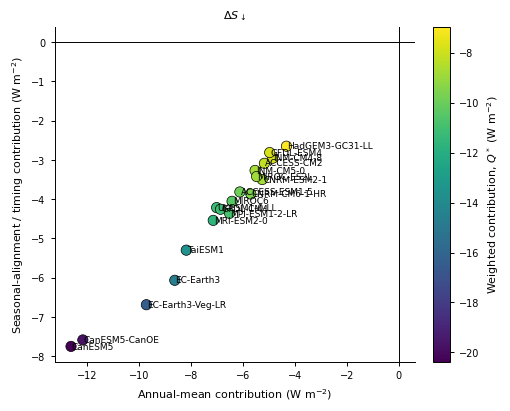

In [77]:
# ============================================================
# Plot: annual-mean magnitude vs seasonal timing
# ============================================================

plot_df = decomp_df.copy()

fig, ax = plt.subplots(figsize=(5.0, 4.0), constrained_layout=True)

sc = ax.scatter(
    plot_df["Q_uniform_Wm2"],
    plot_df["Q_timing_Wm2"],
    c=plot_df["Qstar_Wm2"],
    s=55,
    edgecolor="black",
    linewidth=0.5,
    zorder=3,
)

for _, row in plot_df.iterrows():
    ax.text(
        row["Q_uniform_Wm2"] + 0.03,
        row["Q_timing_Wm2"],
        row["model_label"],
        fontsize=6.5,
        va="center",
    )

ax.axhline(0, color="black", linewidth=0.7)
ax.axvline(0, color="black", linewidth=0.7)

ax.set_xlabel(r"Annual-mean contribution (W m$^{-2}$)")
ax.set_ylabel(r"Seasonal-alignment / timing contribution (W m$^{-2}$)")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"Weighted contribution, $Q^*$ (W m$^{-2}$)")

ax.set_title(component_label)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

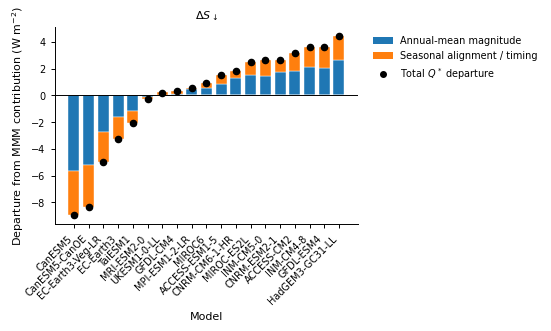

In [78]:
# ============================================================
# Plot: model Q* departure split into magnitude and timing
# Works for total SEB or selected component
# ============================================================

plot_df = decomp_df.copy()

# Departures from multi-model mean
for col in ["Q_uniform_Wm2", "Q_timing_Wm2", "Qstar_Wm2"]:
    plot_df[col + "_departure"] = plot_df[col] - plot_df[col].mean()

plot_df = plot_df.sort_values("Qstar_Wm2_departure")

x = np.arange(len(plot_df))

terms = [
    ("Q_uniform_Wm2_departure", "Annual-mean magnitude"),
    ("Q_timing_Wm2_departure", "Seasonal alignment / timing"),
]

palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]

term_colours = {
    "Annual-mean magnitude": palette[0],
    "Seasonal alignment / timing": palette[1],
}

fig, ax = plt.subplots(figsize=(5.4, 3.2), constrained_layout=True)

bottom_pos = np.zeros(len(plot_df))
bottom_neg = np.zeros(len(plot_df))

for col, label in terms:
    vals = plot_df[col].to_numpy(dtype=float)

    pos = np.where(vals > 0, vals, 0)
    neg = np.where(vals < 0, vals, 0)

    colour = term_colours[label]

    ax.bar(
        x,
        pos,
        bottom=bottom_pos,
        width=0.75,
        color=colour,
        edgecolor="white",
        linewidth=0.3,
    )

    ax.bar(
        x,
        neg,
        bottom=bottom_neg,
        width=0.75,
        color=colour,
        edgecolor="white",
        linewidth=0.3,
    )

    bottom_pos += pos
    bottom_neg += neg

# Overlay total departure as black points
ax.scatter(
    x,
    plot_df["Qstar_Wm2_departure"],
    color="black",
    s=20,
    zorder=5,
)

ax.axhline(0, color="black", linewidth=0.7)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["model_label"], rotation=45, ha="right")

ax.set_ylabel(r"Departure from MMM contribution (W m$^{-2}$)")
ax.set_xlabel("Model")
ax.set_title(component_label)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

handles = [
    Patch(
        facecolor=term_colours[label],
        edgecolor="none",
        label=label,
    )
    for _, label in terms
]

handles.append(
    Line2D(
        [0],
        [0],
        marker="o",
        color="black",
        linestyle="none",
        markersize=4,
        label=r"Total $Q^*$ departure",
    )
)

ax.legend(
    handles=handles,
    frameon=False,
    fontsize=7,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
)

plt.show()


Other ways to split up timing vs magnitude

First take Q* and cubic spline, then find when the peak day of the year is (186, 192, 174 per model etc etc). Do a covariance between those numbers and the SIA. Then do the same thing for the magnitude of that peak. Can repeat for rsus etc. 

Do a weighted version where you keep the magnitude of the peak the same and see if that still has a good fit (if so, then timing is more important). 


We have currently plotted (vs SIA)
Annual average Q
Annual weighted average Q*

Add in:
Unweighted peak
Weighted peak
Annual average weighted but scaled by the peak (so about timing not total) 

In [79]:
# ============================================================
# Component-vs-component scatter plot
# Each axis can use total/component and weighted/unweighted/timing
# ============================================================


def get_component_metric_by_model(
    analysis_df,
    component="total",
    metric="weighted",
    excluded_models=None,
    model_cols=None,
):
    """
    Return one value per model for a chosen SEB component and metric.

    component:
        "total", "seb", "all"
        or "rsds", "rlds", "rsus", "rlus", "hfss", "hfls"

    metric:
        "weighted"   -> sum_m w_m Q_m
        "unweighted" -> sum_m 1/12 Q_m
        "timing"     -> sum_m (w_m - 1/12) Q_m
    """

    if model_cols is None:
        model_cols = ["institution", "source", "member", "experiment"]

    if excluded_models is None:
        excluded_models = []

    component_aliases = {
        "rsds": "rsds_into_surface_Wm2_anom",
        "rlds": "rlds_into_surface_Wm2_anom",
        "rsus": "rsus_into_surface_Wm2_anom",
        "rlus": "rlus_into_surface_Wm2_anom",
        "hfss": "hfss_into_surface_Wm2_anom",
        "hfls": "hfls_into_surface_Wm2_anom",
    }

    component_label_aliases = {
        "rsds": r"$S_{\downarrow}$",
        "rlds": r"$L_{\downarrow}$",
        "rsus": r"$-S_{\uparrow}$",
        "rlus": r"$-L_{\uparrow}$",
        "hfss": r"$-\mathrm{SH}$",
        "hfls": r"$-\mathrm{LH}$",
        "total": "Total SEB",
        "seb": "Total SEB",
        "all": "Total SEB",
    }

    metric_cols = {
        "weighted": "weighted_contribution_Wm2",
        "unweighted": "uniform_contribution_Wm2",
        "uniform": "uniform_contribution_Wm2",
        "timing": "extra_weighting_contribution_Wm2",
        "alignment": "extra_weighting_contribution_Wm2",
    }

    metric_label_aliases = {
        "weighted": r"weighted",
        "unweighted": r"unweighted",
        "uniform": r"unweighted",
        "timing": r"timing",
        "alignment": r"timing",
    }

    df = analysis_df.copy()

    if excluded_models:
        df = df[~df["source"].isin(excluded_models)].copy()

    component_key = str(component).lower()
    metric_key = str(metric).lower()

    if metric_key not in metric_cols:
        raise ValueError(
            f"metric must be one of {list(metric_cols.keys())}; got {metric!r}"
        )

    value_col = metric_cols[metric_key]

    if component_key in ["total", "seb", "all"]:
        selected = df.copy()
        component_label = "Total SEB"
    else:
        component_name = component_aliases.get(component_key, component)
        selected = df[df["component"] == component_name].copy()

        if selected.empty:
            available = sorted(df["component"].dropna().unique())
            raise ValueError(
                f"No rows found for component={component!r}.\n"
                f"Resolved component name was {component_name!r}.\n\n"
                "Available components are:\n"
                + "\n".join(available)
            )

        if "component_label" in selected.columns:
            component_label = selected["component_label"].iloc[0]
        else:
            component_label = component_label_aliases.get(component_key, component_name)

    out = (
        selected
        .groupby(model_cols, as_index=False)
        .agg(value_Wm2=(value_col, "sum"))
    )

    out["model_label"] = out["source"]
    out["component"] = component
    out["metric"] = metric
    out["component_label"] = component_label
    out["metric_label"] = metric_label_aliases[metric_key]

    return out

In [80]:
def plot_component_metric_scatter(
    analysis_df,
    x_component="total",
    x_metric="weighted",
    y_component="rsus",
    y_metric="weighted",
    excluded_models=None,
    model_cols=None,
    annotate=True,
    regression=True,
    figsize=(5.2, 4.0),
):
    """
    Scatter plot of one component/metric against another.

    Example:
        x = weighted total SEB
        y = unweighted rsus

    Or:
        x = timing rsus
        y = weighted total SEB
    """

    if model_cols is None:
        model_cols = ["institution", "source", "member", "experiment"]

    if excluded_models is None:
        excluded_models = []

    x_df = get_component_metric_by_model(
        analysis_df,
        component=x_component,
        metric=x_metric,
        excluded_models=excluded_models,
        model_cols=model_cols,
    )

    y_df = get_component_metric_by_model(
        analysis_df,
        component=y_component,
        metric=y_metric,
        excluded_models=excluded_models,
        model_cols=model_cols,
    )

    x_label_component = x_df["component_label"].iloc[0]
    y_label_component = y_df["component_label"].iloc[0]

    x_label_metric = x_df["metric_label"].iloc[0]
    y_label_metric = y_df["metric_label"].iloc[0]

    plot_df = x_df[model_cols + ["model_label", "value_Wm2"]].rename(
        columns={"value_Wm2": "x"}
    ).merge(
        y_df[model_cols + ["value_Wm2"]].rename(columns={"value_Wm2": "y"}),
        on=model_cols,
        how="inner",
    )

    plot_df = plot_df.dropna(subset=["x", "y"]).copy()

    x = plot_df["x"].to_numpy(dtype=float)
    y = plot_df["y"].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    ax.scatter(
        x,
        y,
        s=55,
        edgecolor="black",
        linewidth=0.5,
        alpha=0.85,
        zorder=3,
    )
    #add 1:1 line
    ax.plot(
        [np.nanmin(x), np.nanmax(x)],
        [np.nanmin(x), np.nanmax(x)],
        color="black",
        linewidth=0.8,
        linestyle="--",
        zorder=2,
    )
    if annotate:
        x_pad = 0.015 * (np.nanmax(x) - np.nanmin(x)) if len(x) > 1 else 0.05

        for _, row in plot_df.iterrows():
            ax.text(
                row["x"] + x_pad,
                row["y"],
                row["model_label"],
                fontsize=6.5,
                va="center",
            )

    if regression and len(plot_df) >= 3 and not np.allclose(x, x[0]):
        fit = linregress(x, y)

        slope = fit.slope
        intercept = fit.intercept
        r2 = fit.rvalue**2
        p_value = fit.pvalue

        y_pred = slope * x + intercept
        rmse = np.sqrt(np.mean((y - y_pred) ** 2))

        x_fit = np.linspace(np.nanmin(x), np.nanmax(x), 200)
        y_fit = slope * x_fit + intercept

        ax.plot(
            x_fit,
            y_fit,
            color="black",
            linewidth=1.2,
            zorder=2,
        )

        stats_text = (
            rf"$R^2$ = {r2:.2f}" "\n"
            rf"RMSE = {rmse:.2f} W m$^{{-2}}$" "\n"
            rf"Slope = {slope:.2f}" "\n"
            rf"$p$ = {p_value:.3f}" "\n"
            rf"$n$ = {len(plot_df)}"
        )

        ax.text(
            0.04,
            0.96,
            stats_text,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8,
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                edgecolor="0.8",
                alpha=0.9,
            ),
        )

    ax.axhline(0, color="0.4", linewidth=0.7, linestyle="--", zorder=1)
    ax.axvline(0, color="0.4", linewidth=0.7, linestyle="--", zorder=1)

    ax.set_xlabel(
        rf"{x_label_metric.capitalize()} {x_label_component} contribution "
        r"(W m$^{-2}$)"
    )

    ax.set_ylabel(
        rf"{y_label_metric.capitalize()} {y_label_component} contribution "
        r"(W m$^{-2}$)"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    #plt.show()

    return plot_df, r2, rmse, slope, intercept, p_value

Component: rsds, r^2: 0.560
Component: rlds, r^2: 0.688
Component: rsus, r^2: 0.685
Component: rlus, r^2: 0.683
Component: hfss, r^2: 0.375
Component: hfls, r^2: 0.237


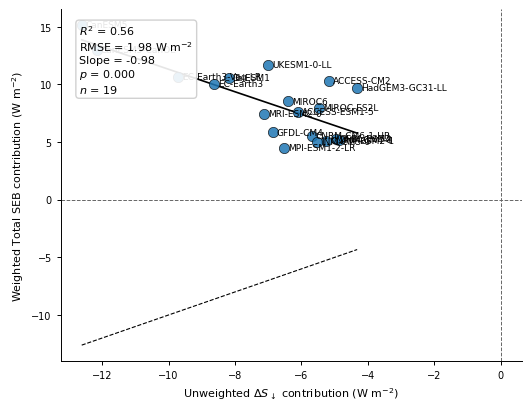

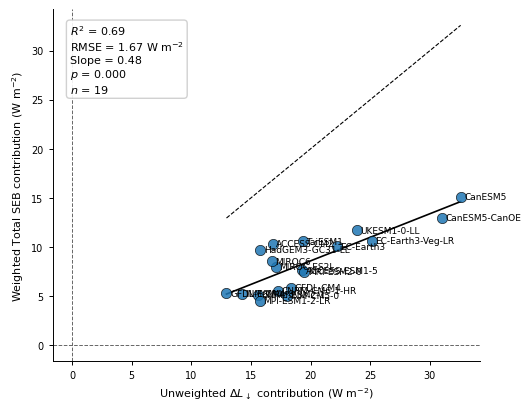

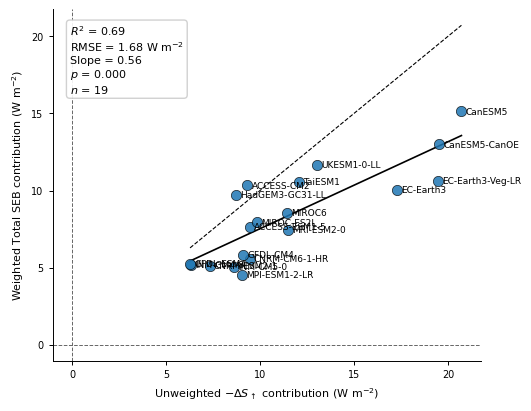

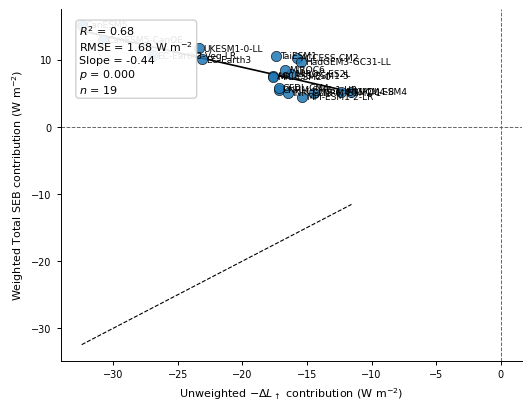

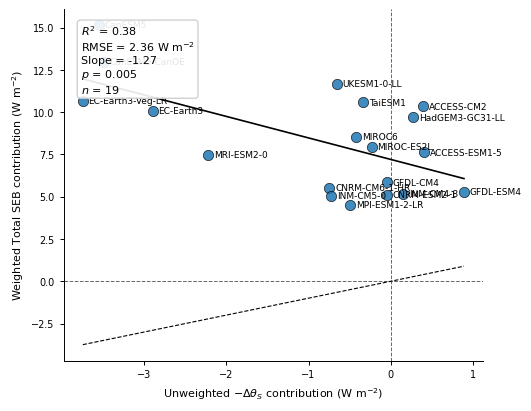

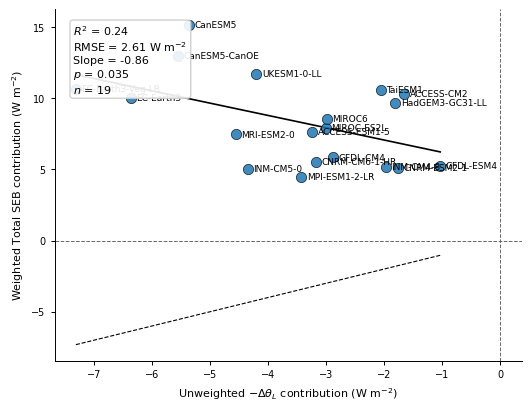

In [81]:
# Weighted total SEB vs weighted rsus
for component in ["rsds", "rlds", "rsus", "rlus", "hfss", "hfls"]:
    plot_df, r2, rmse, slope, intercept, p_value = plot_component_metric_scatter(
        analysis_df,
        x_component=component,
        x_metric="unweighted",
        y_component="total",
        y_metric="weighted",
        excluded_models=EXCLUDED_MODELS,
    )
    print(f"Component: {component}, r^2: {r2:.3f}")